In [1]:
%load_ext autoreload
%autoreload 2
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd

from sklearn.datasets import load_digits

In [ ]:
# load the digits dataset
digits = load_digits()

labels = digits['target']
# the data is in the same order as embedding (that was the training data)

# Create a DiscreteLatentSpace object with loading /gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav and /gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv

# Load the UMAP embedding to numpy
embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv', header=None)
embedding = embedding.values

# Load the UMAP model
with open('/gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav', 'rb') as f:
    umap_model = pickle.load(f)
    
# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=10)

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348
delete_heatmap: No heatmap with the name test_heatmap exists


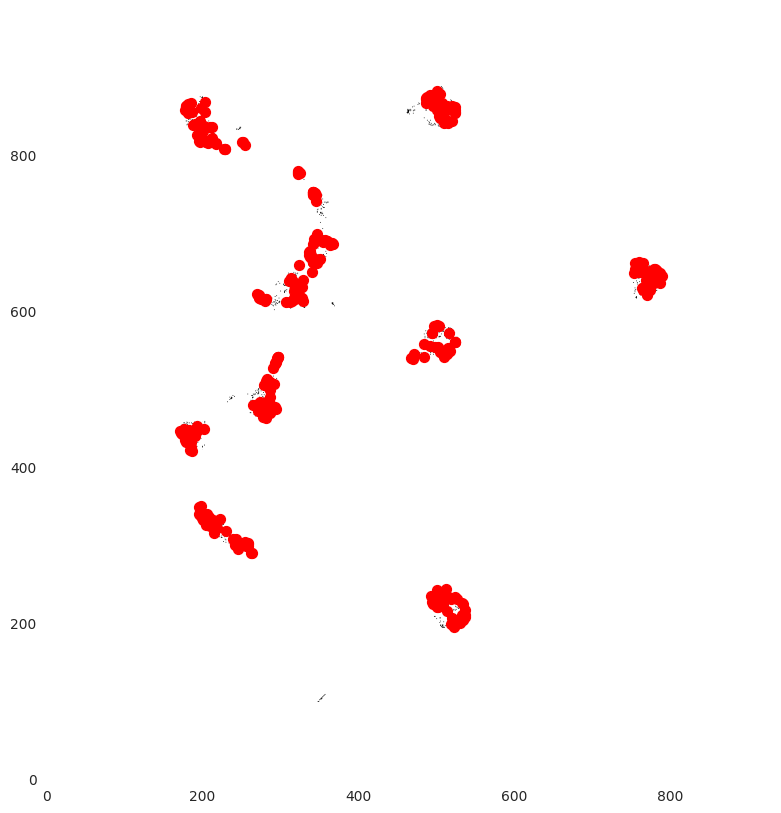

Smoothing the discrete space with a sigma of 21.233045007200477
Shape of the smoothed space: (359, 930, 987)
Sigma tuple: (0, 21.233045007200477, 21.233045007200477)
Shape of the smoothed n+1 dim discrete space: (359, 930, 987)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


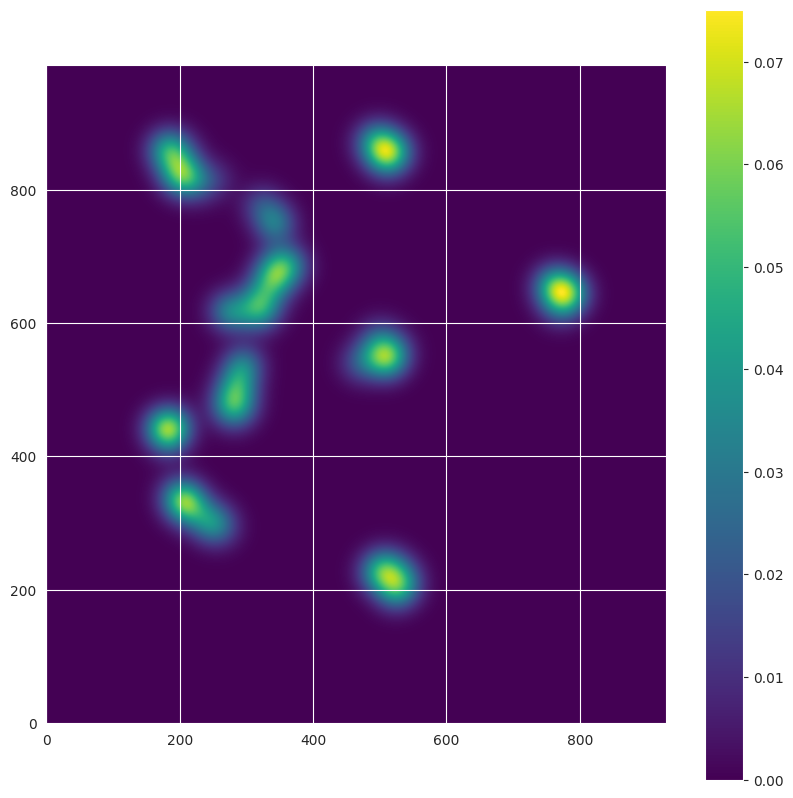

unique_vectors shape: (369031, 359)
vectors shape: (917910, 359)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [72]:
# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) with the last 10% of the embeddings
test_sub_embedding = embedding[-int(embedding.shape[0] * 0.2):]
# use the label as the score for the heatmap
sub_labels = labels[-int(embedding.shape[0] * 0.2):]
# normalise the labels between 0 and 1
sub_labels = (sub_labels - sub_labels.min()) / (sub_labels.max() - sub_labels.min())


# create the rescaled and discrete embeddings
dls.rescale_embedding(dls.raw_embeddings)
# dls.create_inverse_rescaled_embedding()
dls.create_discrete_space(dls.rescaled_embeddings, 10)
# delete the heatmap if it already exists
dls.delete_heatmap('test_heatmap')
dls.create_heatmap_spaces(test_sub_embedding, sub_labels, 'test_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='test_heatmap')

dls.plot_heatmap('test_heatmap', 50)

heatmap = dls.heatmaps['test_heatmap']

# Now I want to use compute_stats_on_smoothed_nplusone_dim_discrete_space and then display the statistics and the corrected p-values heatmap
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'
print(f'Heatmap shape: {heatmap.shape}')
statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics shape: {statistics.shape}')
statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics clusters shape: {statistics_clu.shape}')



 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (930, 987)
Number of non-Nan values: 373015


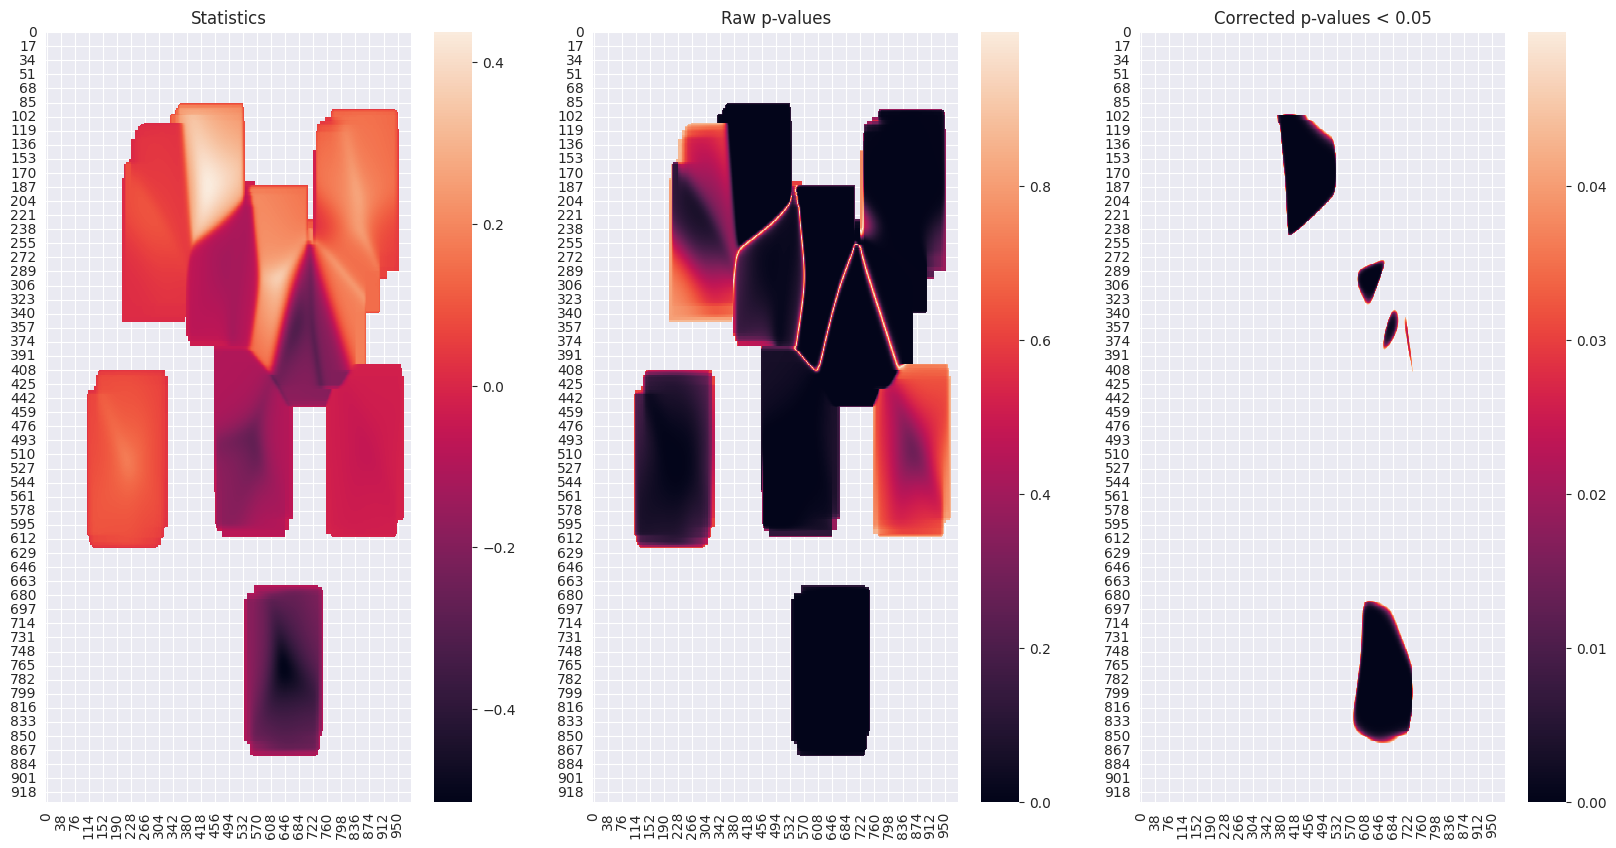

In [74]:
# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(20, 10))

sns.heatmap(statistics, ax=ax[0])
ax[0].set_title('Statistics')

# raw p-values
sns.heatmap(pvalues, ax=ax[1])
ax[1].set_title('Raw p-values')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Corrected p-values < 0.05')
else:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')

plt.show()



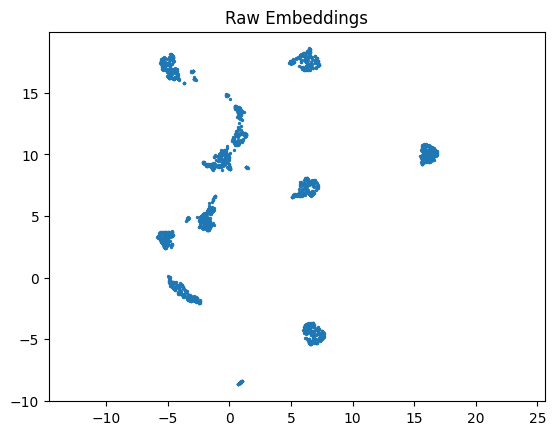

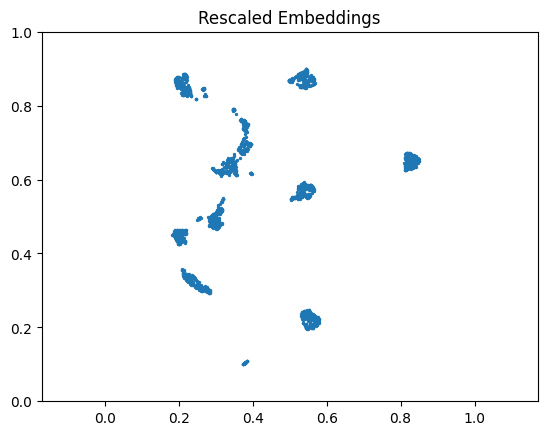

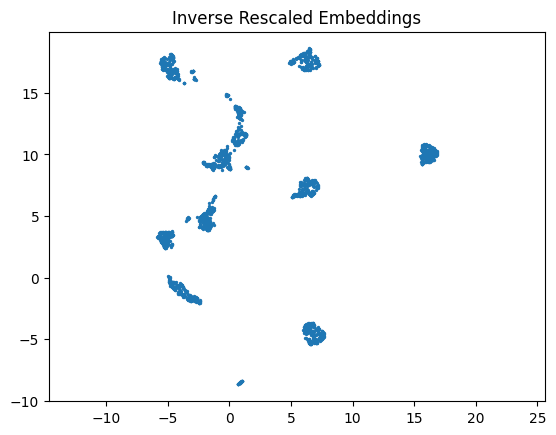

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348


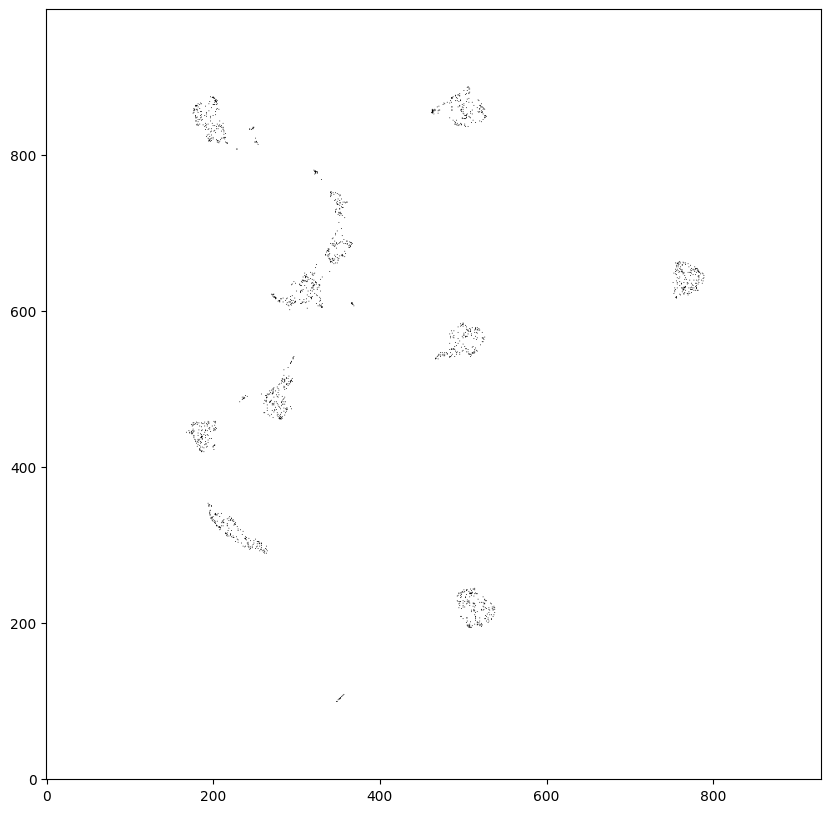

There is an overlap of 11.57% points in the discrete space
The number of cells in the discrete space is 722750
The shape of the discrete space is (826, 875)
Maximum in each dimension: 18.60238075256348


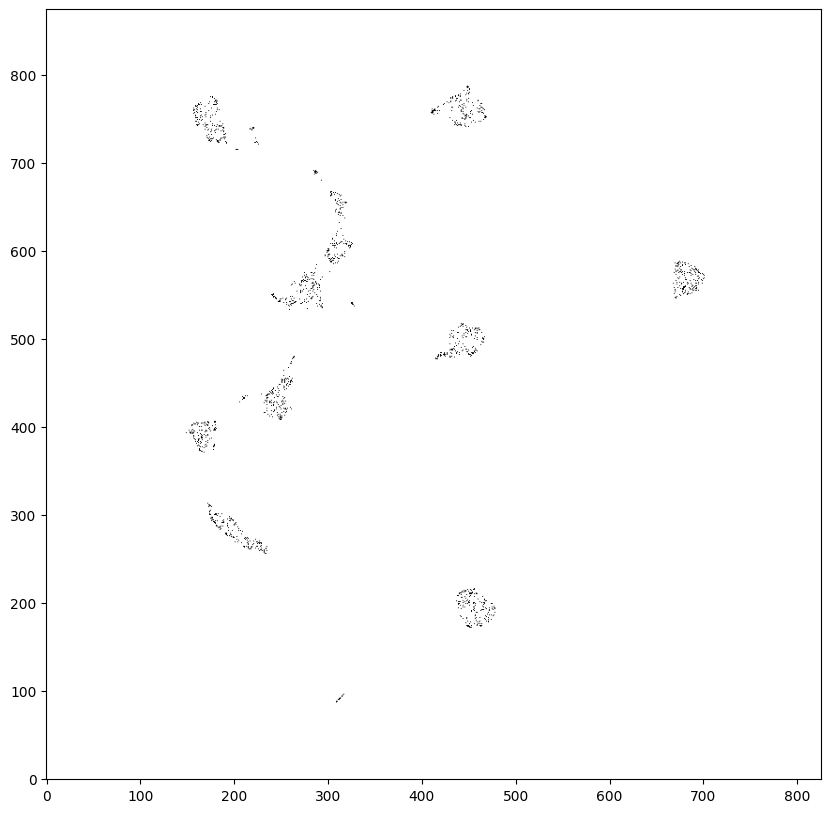

There is an overlap of 11.69% points in the discrete space
The number of cells in the discrete space is 722700
The shape of the discrete space is (825, 876)
Maximum in each dimension: 18.60238075256348


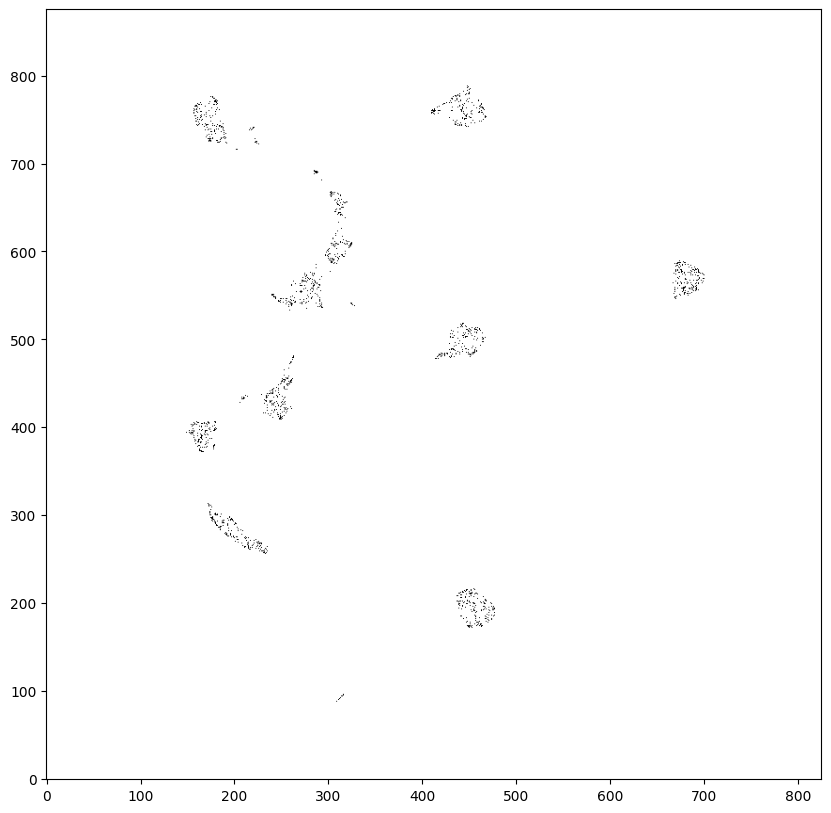

In [223]:
# plot the different versions of the embeddings in the latent space
dls.plot_raw_embedding()

dls.plot_rescaled_embedding()

dls.plot_inverse_rescaled_embedding()

dls.plot_discrete_embedding(10)

dls.plot_discrete_embedding(None, (826, 875))
dls.plot_discrete_embedding(None, (825, 876))


In [8]:
import os
import glob
from PIL import Image
import numpy as np
import pandas as pd

# image_paths_list_to_matrix
images_folder = "/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/Images"

# List all image files in the directory and its subdirectories
image_files = glob.glob(os.path.join(images_folder, '**', '*.*'), recursive=True)

# Filter the image files with a filename ending with "-N"
filtered_files = [f for f in image_files if os.path.splitext(os.path.basename(f))[0].endswith('-N')]

print(len(filtered_files))
print(f'Unique files names (without folder): {len(set([os.path.basename(f) for f in filtered_files]))}')

# save filtered_files as a csv
filtered_files_df = pd.DataFrame(filtered_files, columns=['image_path'])
filtered_files_df.to_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv', index=False)


# print the different resolutions (unique ones) of the images
# resolutions = set([np.array(Image.open(f)).shape for f in filtered_files])
# print(resolutions)


831
Unique files names (without folder): 831


In [4]:
from tqdm import tqdm
import importlib
import tools.inputs_utils

importlib.reload(tools.inputs_utils)

# images_list = [Image.open(img_path) for img_path in filtered_files]
# faces_input_matrix = image_paths_list_to_matrix(filtered_files, rescale=True)

def process_images(image_list, target_size=(128, 128)):
    images = []
    for img_path in tqdm(image_list):
        with Image.open(img_path) as img:
            img = img.resize(target_size)
            img_array = np.array(img, dtype=np.uint8)  # Use uint8 to save memory
            images.append(img_array.flatten())  # Flatten if necessary or adapt based on UMAP needs
    return np.array(images)

faces_input_matrix = process_images(filtered_files, (2407, 1662))

100%|██████████| 831/831 [01:53<00:00,  7.34it/s]


In [8]:
import scipy.sparse as sparse
# create an output folder for the trained umap and embeddings
output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
seed = 42

# create the output folder if it does not exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# faces_input_matrix = sparse.csr_matrix(faces_input_matrix, dtype=np.uint8)
    
# save the faces_input_matrix
np.save(os.path.join(output_folder, 'faces_input_matrix.npy'), faces_input_matrix)
# sparse.save_npz(os.path.join(output_folder, 'faces_input_matrix.npz'), faces_input_matrix)

MemoryError: Unable to allocate 148. GiB for an array with shape (9945723878, 2) and data type int64

In [ ]:
# train the umap model
from umap import UMAP

umap_model = UMAP(random_state=seed, verbose=True, n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean')
umap_embedding = umap_model.fit(faces_input_matrix)

In [12]:
import pickle
# save the umap model
with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'wb') as f:
    pickle.dump(umap_model, f)
    
# save the umap embedding
np.savetxt(os.path.join(output_folder, 'faces_embedding_42.csv'), umap_embedding.embedding_, delimiter=',')

In [5]:
import os 
import pandas as pd

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'

faces_embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)

print(faces_embedding.shape)

(831, 2)


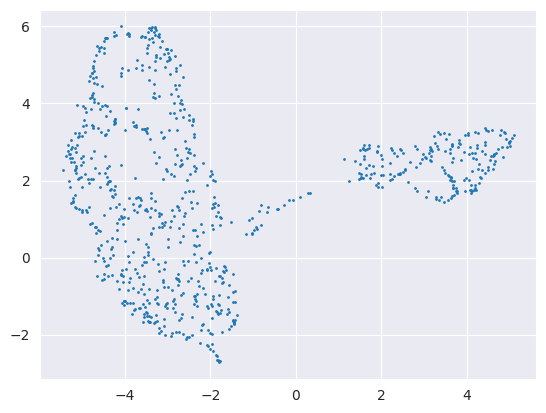

In [6]:
# plot the umap embedding
import matplotlib.pyplot as plt

plt.scatter(faces_embedding[0], faces_embedding[1], s=1)
plt.show()


In [9]:
# load /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx
info_dataframe = pd.read_excel('/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx', sheet_name=None, header=7)

# print sheet names
print(list(info_dataframe.keys()))

# create a dataframe maching the image names (filenames in filtered_files) with the "Model" column in all the "Norming Data" sheets. The filename should contain the "Model" column in the "Norming Data" sheets
import os
import pandas as pd
from pathlib import Path

# Get the common columns across all dataframes
common_columns = set(info_dataframe[list(info_dataframe.keys())[1]].columns)
for sheet_name, df in info_dataframe.items():
    if 'Norming Data' not in sheet_name:
        continue
    # print first 5 columns
    # print(df.columns[:5])
    common_columns.intersection_update(df.columns)
    
common_columns = list(common_columns)

# print(common_columns)

model_data = []
for sheet_name, df in info_dataframe.items():
    if "U.S. Norming Data" in sheet_name:
        # Only append the common columns
        model_data.append(df[common_columns])

# Create a new dataframe that contains the common data from all sheets
model_df = pd.concat(model_data, ignore_index=True)

# remove the rows with NaN values for Model
model_df = model_df.dropna(subset=['Model'])

# print(model_df.columns)

# print(f'Model in columns {"Model" in model_df.columns}')
# print(len(model_df['Model'].unique()))

path_model_match = {}

# Match the filename with the "Model" column
for img_path in filtered_files:
    img_name = Path(img_path).name
    found = False
    for model in model_df['Model']:
        # print(model)
        if model in img_name or model in img_name.replace('-', '', 2):
            if found:
                print(f"Multiple matches for {img_name}")
                break
            path_model_match[img_name] = model
            found = True
    if not found:
        print(f"No match for {img_name}")
        
# save the path_model_match dictionary in a json
import json

with open(os.path.join(output_folder, 'path_model_match.json'), 'w') as f:
    json.dump(path_model_match, f, indent=4)
    
# save the model_df dataframe filtered with only the matched models in a csv
model_df = model_df[model_df['Model'].isin(path_model_match.values())]
print(model_df.shape)
model_df.to_csv(os.path.join(output_folder, 'models_merged_df.csv'), index=False)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


['CFD 3.0 Codebook', 'CFD U.S. Norming Data', 'CFD-MR U.S. Norming Data', 'CFD-I U.S. Norming Data', 'CFD-I INDIA Norming Data']
No match for CFD-IM-719-221-N.jpg
No match for CFD-IM-638-250-2-N.jpg
No match for CFD-IF-644-306-2-N.jpg
No match for CFD-IF-714-008-2-N.jpg
No match for CFD-IF-677-452-2-N.jpg
(826, 118)


In [49]:
# Now I want to create a DiscreteLatentSpace object with the faces umap model and embedding
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd
import os

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
# Load the UMAP embedding to numpy
embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)
embedding = embedding.values

# Load the UMAP model
# with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'rb') as f:
#     umap_model = pickle.load(f)
    
umap_model = None
    
filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

print(filtered_files_df.columns)

# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=5)


Index(['image_path'], dtype='object')


There is an overlap of 4.93% points in the discrete space
The number of cells in the discrete space is 68000
The shape of the discrete space is (250, 272)
Maximum in each dimension: 6.000002384185791
Size of Attractive column: (826,)
Embedding shape: (831, 2)
Attractive embedding shape: (826, 2)


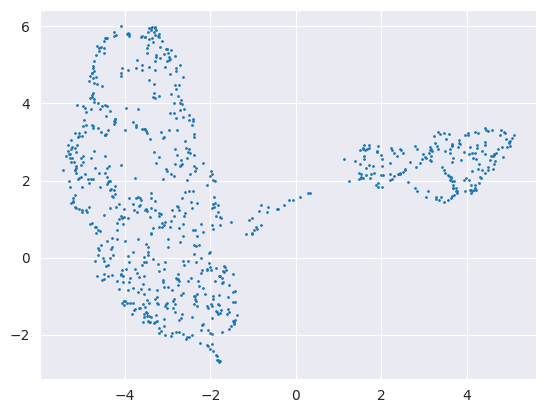

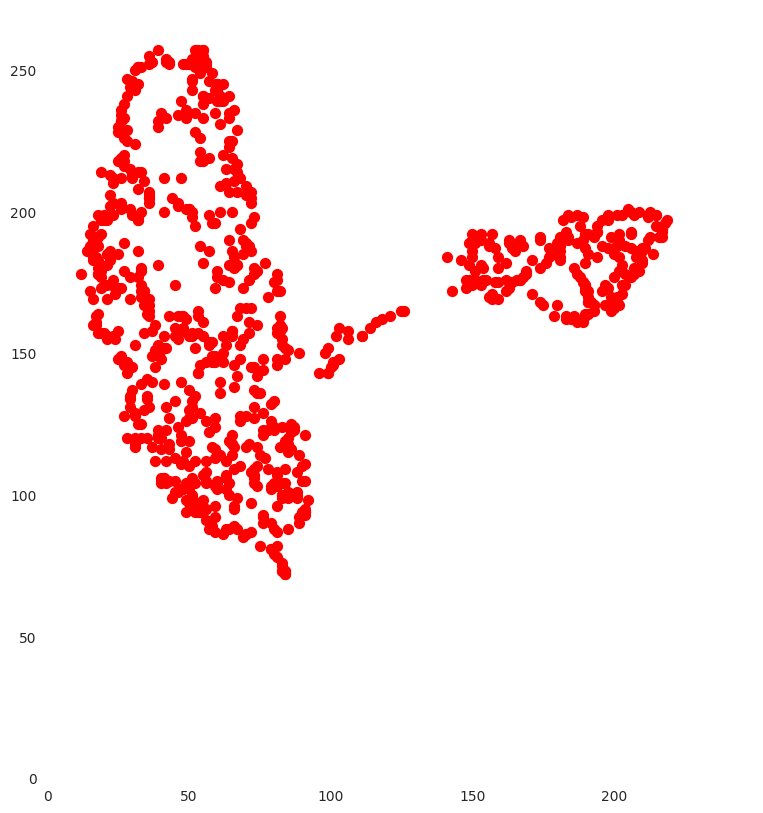

In [52]:
import json
from pathlib import Path

# Now I want to create the different spaces to finally create a heatmap and display the corrected p-values heatmap

dls.rescale_embedding(dls.raw_embeddings)
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) 


path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))
model_df = pd.read_csv(os.path.join(output_folder, 'models_merged_df.csv'))
# use the "Attractive" column in the model_df as the score for the heatmap
sub_labels = model_df['Attractive']
# Normalize the 'Attractive' column between 0 and 1 using 1 and 7 as boundaries
model_df['Attractive'] = (model_df['Attractive'] - 1) / (7 - 1)

print(f'Size of Attractive column: {model_df["Attractive"].shape}')

# the umap was trained with all the file but path_model_match contains only the matched files
# so I need to filter the embedding.
print(f'Embedding shape: {embedding.shape}')
attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]
print(f'Attractive embedding shape: {attractive_embedding.shape}')

# plot attractive_embedding
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], s=1)
plt.show()

# create the heatmap and all the spaces needed to compute the corrected p-values
dls.delete_heatmap('attractive_heatmap')
dls.create_heatmap_spaces(attractive_embedding, model_df['Attractive'], 'attractive_heatmap')

# create the heatmap raw, rescaled and discrete spaces
attractive_heatmap = dls.heatmaps['attractive_heatmap']

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='attractive_heatmap')

Smoothing the discrete space with a sigma of 2.1233045007200477
Shape of the smoothed space: (826, 250, 272)
Sigma tuple: (0, 2.1233045007200477, 2.1233045007200477)
Shape of the smoothed n+1 dim discrete space: (826, 250, 272)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


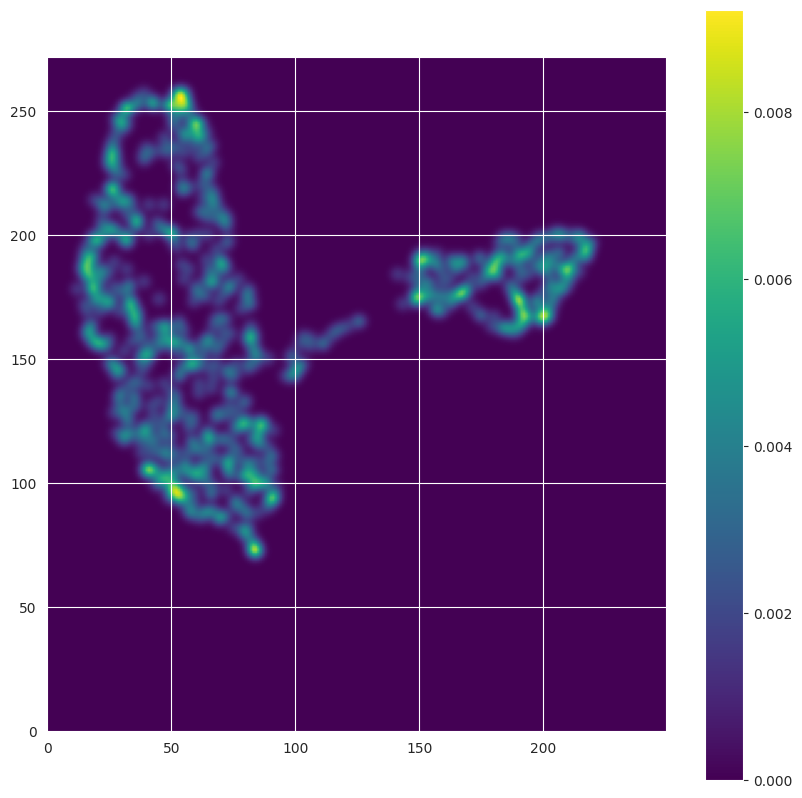

unique_vectors shape: (18276, 826)
vectors shape: (68000, 826)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (250, 272)
Number of non-Nan values: 18580


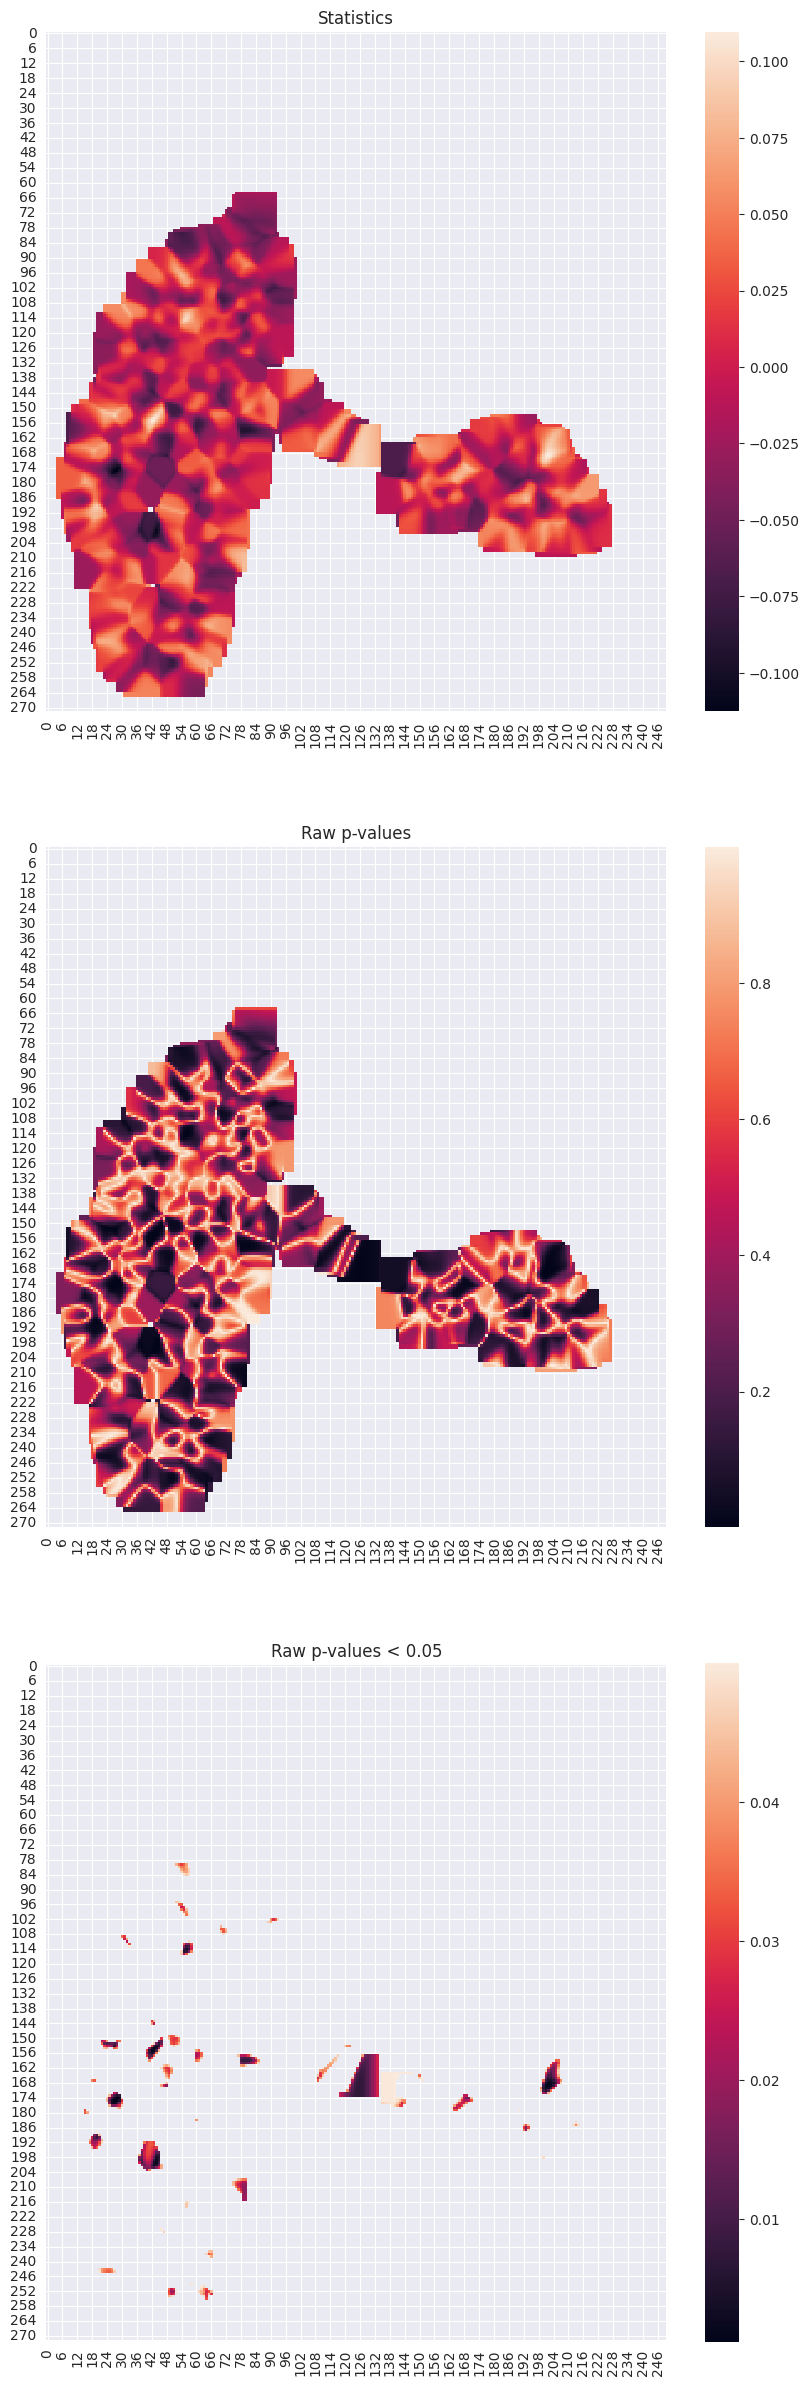

In [53]:
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('attractive_heatmap', 5)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

sns.heatmap(statistics.T, ax=ax[0])
ax[0].set_title('Statistics')
plt.axis('scaled')

# raw p-values
sns.heatmap(pvalues.T, ax=ax[1])
ax[1].set_title('Raw p-values')
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    if np.sum(~np.isnan(masked_pvalues)) > 0:
        sns.heatmap(masked_pvalues.T, ax=ax[2])
        ax[2].set_title('Corrected p-values')
if np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    if np.sum(~np.isnan(masked_pvalues_clu)) > 0:
        sns.heatmap(masked_pvalues_clu.T, ax=ax[2])
        ax[2].set_title('Corrected p-values clusters')
if np.sum(~np.isnan(masked_pvalues)) == 0 and np.sum(~np.isnan(masked_pvalues_clu)) == 0:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues.T, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')
    
plt.axis('scaled')
plt.show()


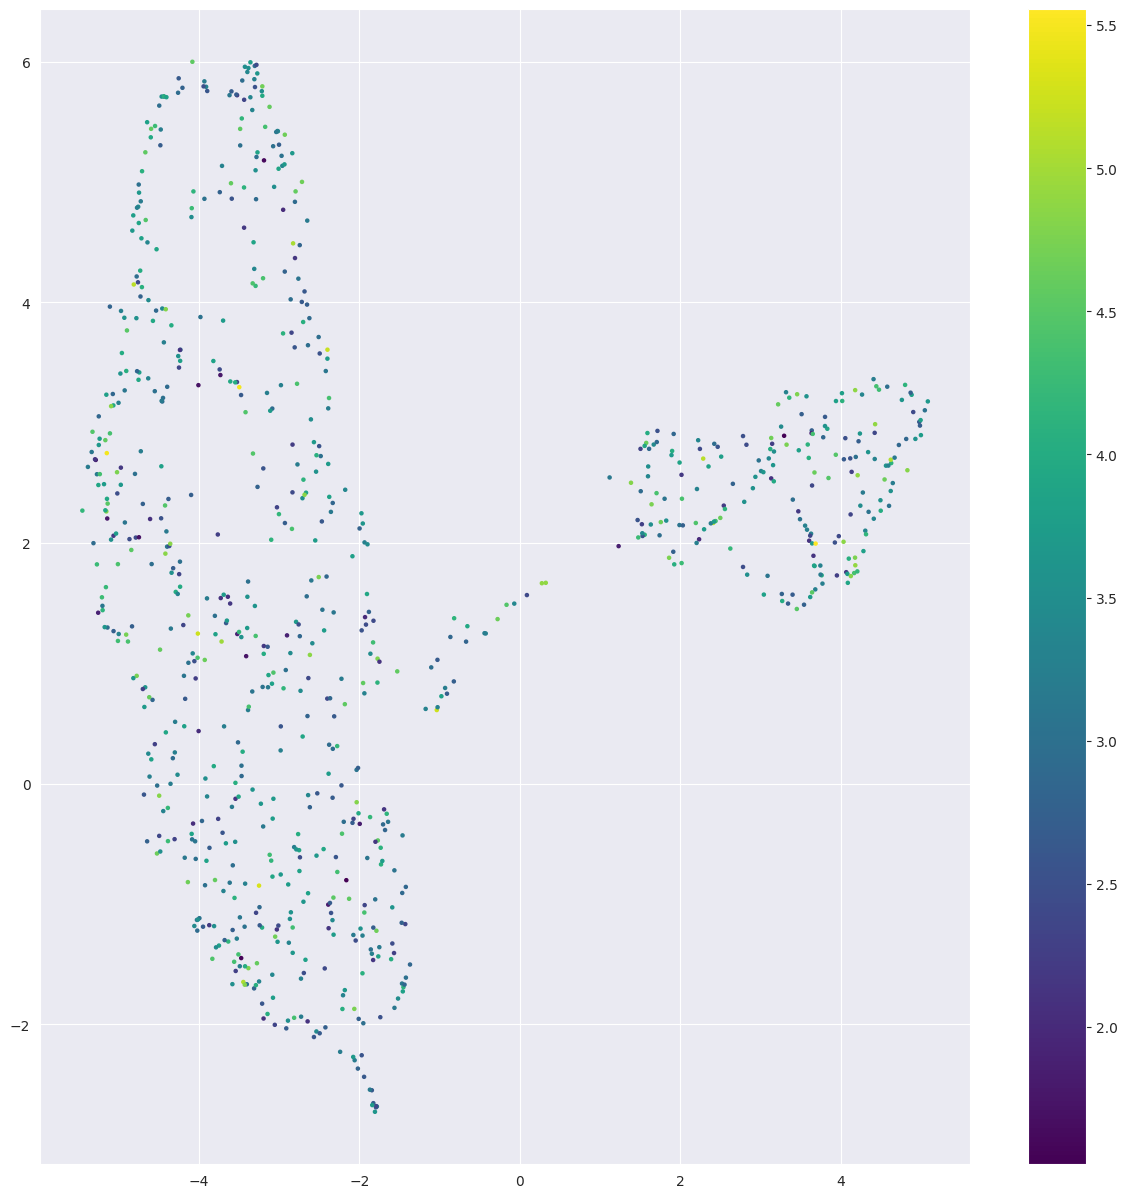

In [75]:
import matplotlib.pyplot as plt

embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/faces_embedding_42.csv', header=None).to_numpy()

filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))

attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]

model_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/models_merged_df.csv')

# plot the embedding with the attractive column as colour (and a colourbar)
variable = 'Attractive'
# increase figure size
plt.figure(figsize=(15, 15))
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], c=model_df[variable], cmap='viridis', s=5)
plt.colorbar()
# save the plot
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/attractive_embedding.png')
plt.show()


In [36]:
import joblib
from tools.inputs_utils import nifti_dataset_to_matrix
import pandas as pd
from pathlib import Path
import os

lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/lesion_masks_registered/'
# lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/disco/'

spreadsheet = pd.read_excel('/home/chrisfoulon/neuro_data/NEURAL_DATA/NEURAL_CUP_scores_training.xlsx', header=0, index_col=0)

# list nifti files in lesions_folder
lesions_list = [p for p in Path(lesions_folder).iterdir() if p.is_file()]

matched_lesions_list = []
for index in spreadsheet.index:
    found = False
    for i in lesions_list:
        formatted_str = index.replace('-', '')
        # the string must be 6 characters long not more (cut the last character if it is)
        if len(formatted_str) > 6:
            formatted_str = formatted_str[:-1]
        if formatted_str.replace('-', '') in i.name:
            matched_lesions_list.append(i)
            found = True
            break
    if not found:
        print(f'{index} not found')
        
# print columns of spreadsheet
print(spreadsheet.columns)

neural_input_matrix = nifti_dataset_to_matrix(matched_lesions_list)

output_folder = '/home/chrisfoulon/neuro_data/umap_tests_les/'

# load umap from /home/chrisfoulon/neuro_data/umap_tests_les/trained_umap.sav
trained_umap = joblib.load(os.path.join(output_folder, 'trained_umap.sav'))

# embed the neural_input_matrix with the trained umap
les_embeddings = trained_umap.transform(neural_input_matrix)


Index(['MOCA tot M12', 'Visuospatial M12', 'Denomination M12', 'Attention M12',
       'Langage M12', 'Abstraction M12', 'Rappel M12', 'Orientation M12',
       'Isaac M12', 'FM tot M12', 'FM moteur M12', 'HAD_A M12', 'HAD_D M12'],
      dtype='object')


187it [00:04, 46.08it/s]


There is an overlap of 3.74% points in the discrete space
The number of cells in the discrete space is 5035
The shape of the discrete space is (95, 53)
Maximum in each dimension: 12.373346328735352
delete_heatmap: No heatmap with the name neural_heatmap exists


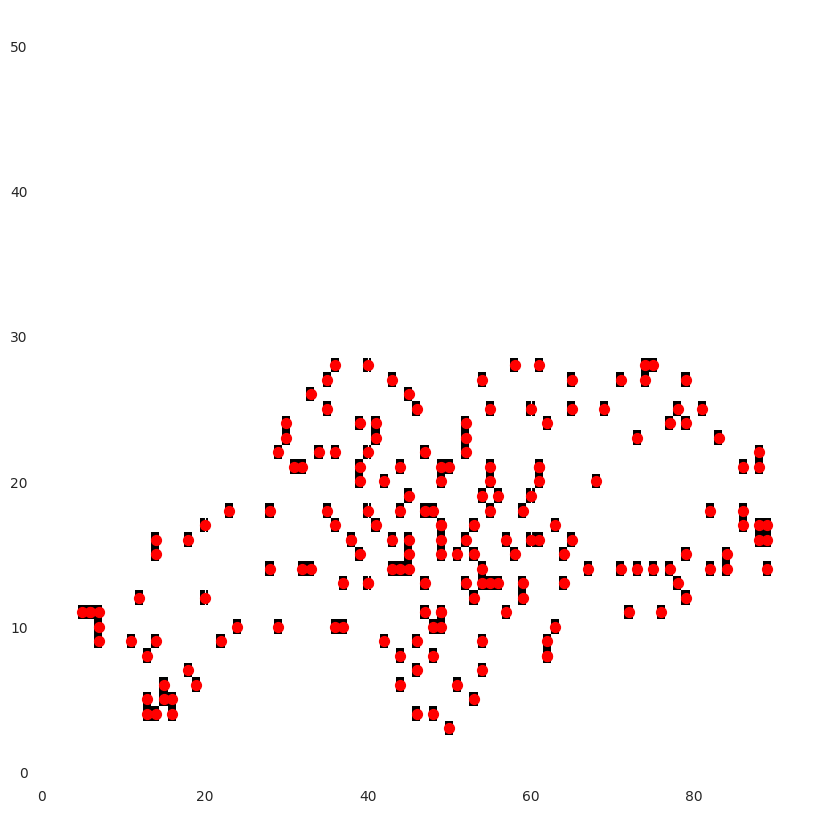

Smoothing the discrete space with a sigma of 1.6986436005760381
Shape of the smoothed space: (187, 95, 53)
Sigma tuple: (0, 1.6986436005760381, 1.6986436005760381)
Shape of the smoothed n+1 dim discrete space: (187, 95, 53)
Max value in the smoothed_nplusone_dim_discrete_space: 0.05517105800002826


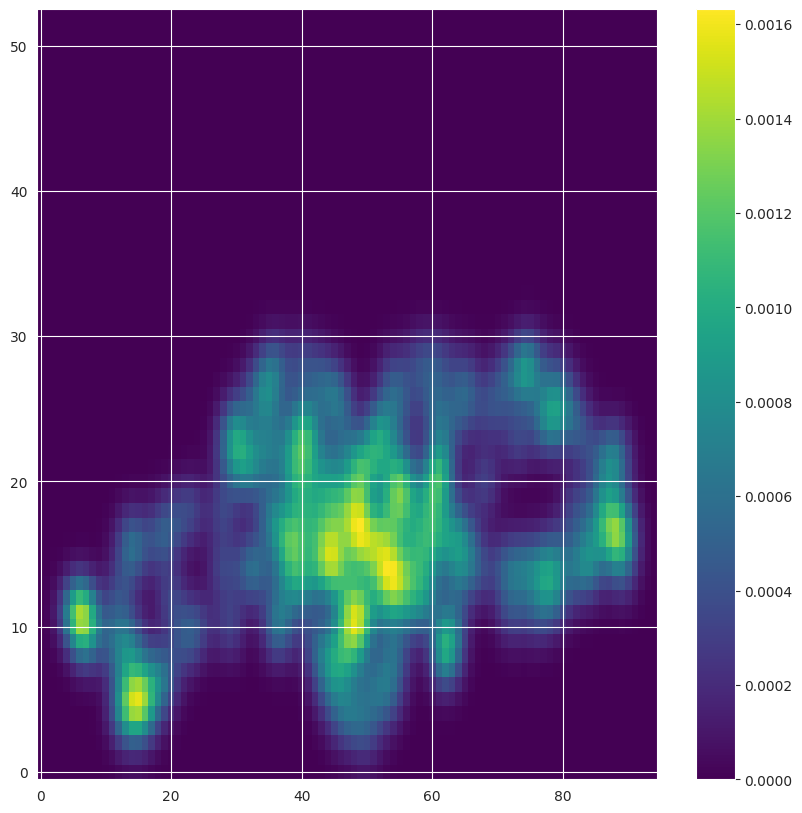

In [37]:
from tools.emuse_utils import DiscreteLatentSpace

test = "MOCA tot M12"
# test_scores needs to be a list
test_scores = spreadsheet[test].tolist()

# create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(trained_umap, les_embeddings, margin=5)

# rescale the embedding
dls.rescale_embedding(dls.raw_embeddings)

# create the discrete space
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create the heatmap
dls.delete_heatmap('neural_heatmap')
dls.create_heatmap_spaces(dls.raw_embeddings, test_scores, 'neural_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='neural_heatmap')

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 4)


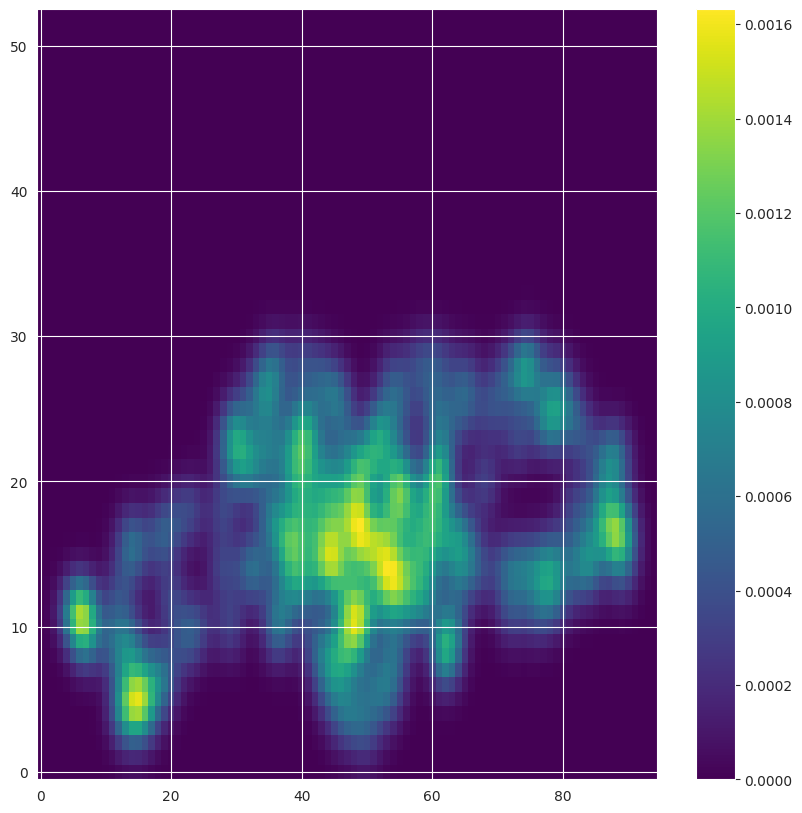

unique_vectors shape: (2894, 187)
vectors shape: (5035, 187)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (95, 53)
Number of non-Nan values: 2897
Number of non-Nan values: 2897


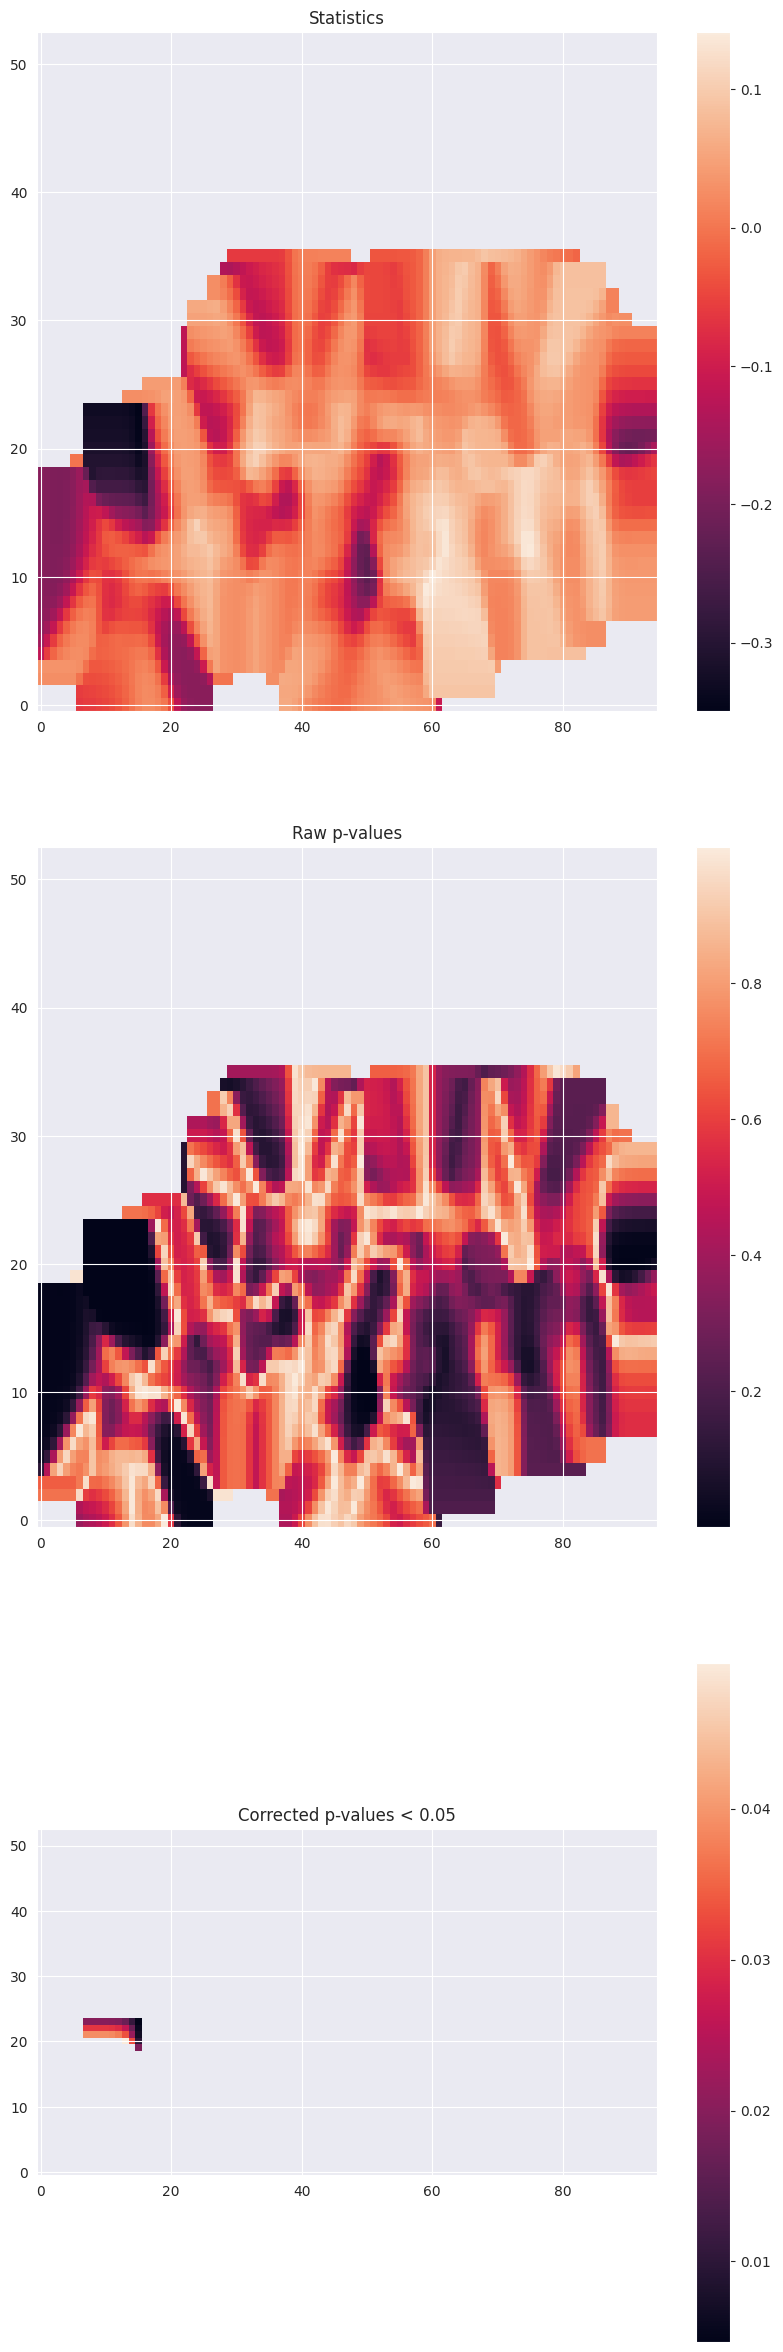

In [40]:
# compute the statistics and corrected p-values
import numpy as np
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 10)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

# Statistics
im = ax[0].imshow(statistics.T, origin='lower', aspect='auto')
ax[0].set_title('Statistics')
fig.colorbar(im, ax=ax[0])
plt.axis('scaled')

# Raw p-values
im = ax[1].imshow(pvalues.T, origin='lower', aspect='auto')
ax[1].set_title('Raw p-values')
fig.colorbar(im, ax=ax[1])
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')
print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')
    masked_corrected_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values < 0.05')
elif np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    print(f'Number of non-Nan values (clusters): {np.sum(~np.isnan(corrected_pvalues_clu))}')
    masked_corrected_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues_clu.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values clusters < 0.05')
else:
    print(f'Number of non-Nan values (raw p-values): {np.sum(pvalues < 0.05)}')
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    im = ax[2].imshow(masked_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Raw p-values < 0.05')

fig.colorbar(im, ax=ax[2])
plt.axis('scaled')
plt.show()

Predicted value: 4.474059295602397, Standard deviation: 1.6039558705943955


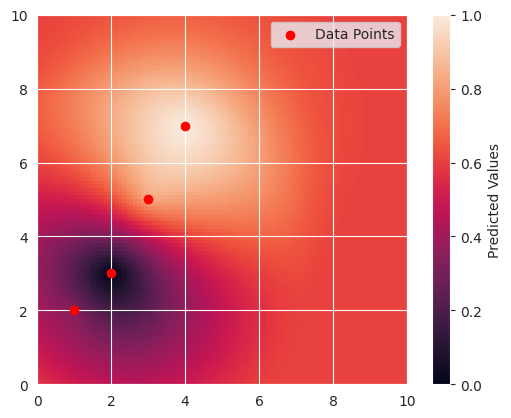

In [2]:
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt

# Sample data: coordinates (x, y) and values (z)
X = np.array([1, 2, 3, 4], dtype=np.float64)
Y = np.array([2, 3, 5, 7], dtype=np.float64)
Z = np.array([3.0, 2.0, 4.5, 5.0], dtype=np.float64)

# Creating an Ordinary Kriging model
OK = OrdinaryKriging(X, Y, Z, variogram_model='spherical')

# Coordinates where we want to predict the values
X_new = np.array([5], dtype=np.float64)
Y_new = np.array([8], dtype=np.float64)

# Performing the prediction
Z_pred, ss = OK.execute('points', X_new, Y_new)

print(f"Predicted value: {Z_pred[0]}, Standard deviation: {ss[0]}")

# Visualization (optional)
gridx = np.linspace(0.0, 10.0, 100)
gridy = np.linspace(0.0, 10.0, 100)
z, ss = OK.execute('grid', gridx, gridy)

plt.imshow(z, extent=(0, 10, 0, 10), origin='lower')
plt.scatter(X, Y, c='r', label='Data Points')
plt.colorbar(label='Predicted Values')
plt.legend()
plt.show()
 

In [13]:
from tools.inputs_utils import load_and_preprocess_mnist_dataset
from sklearn.datasets import fetch_openml

# Load data from https://www.openml.org/d/554
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()

print(f'MNIST features shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Min max values: pixel1      0.0
pixel2      0.0
pixel3      0.0
pixel4      0.0
pixel5      0.0
           ... 
pixel780    0.0
pixel781    0.0
pixel782    0.0
pixel783    0.0
pixel784    0.0
Length: 784, dtype: float64, pixel1       0.0
pixel2       0.0
pixel3       0.0
pixel4       0.0
pixel5       0.0
            ... 
pixel780    62.0
pixel781     0.0
pixel782     0.0
pixel783     0.0
pixel784     0.0
Length: 784, dtype: float64
MNIST features shape: (70000, 784)
MNIST labels shape: (70000,)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Leaving out 90% of the dataset for testing
Completed evaluation with 90% left out
Leaving out 91% of the dataset for testing
Completed evaluation with 91% left out
Leaving out 92% of the dataset for testing
Completed evaluation with 92% left out
Leaving out 93% of the dataset for testing
Completed evaluation with 93% left out
Leaving out 94% of the dataset for testing
Completed evaluation with 94% left out
Leave out 90%: Fold Accuracy = 0.9380, Left Out Accuracy = 0.9411
Leave out 91%: Fold Accuracy = 0.9340, Left Out Accuracy = 0.9370
Leave out 92%: Fold Accuracy = 0.9305, Left Out Accuracy = 0.9368
Leave out 93%: Fold Accuracy = 0.9278, Left Out Accuracy = 0.9355
Leave out 94%: Fold Accuracy = 0.9279, Left Out Accuracy = 0.9317


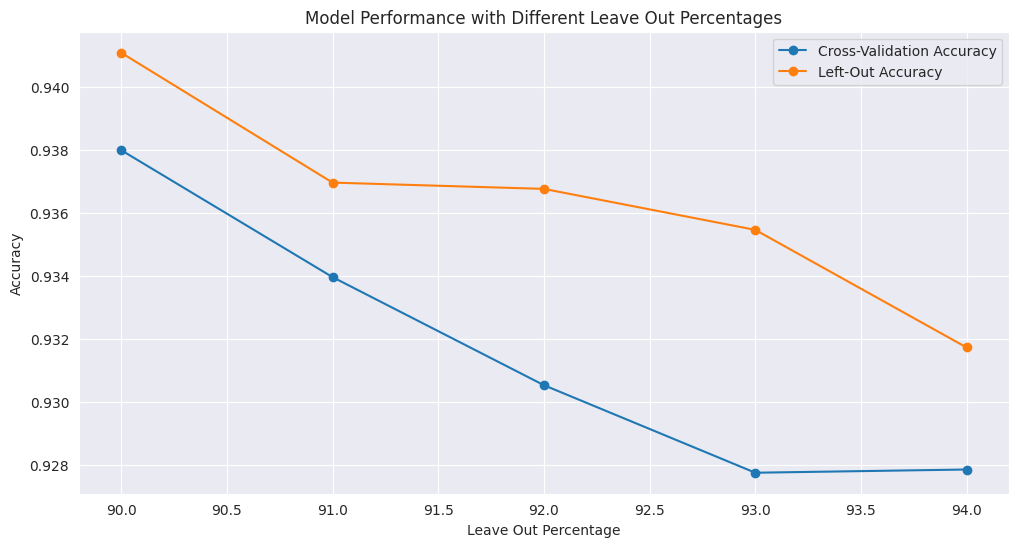

In [8]:
"""
Trying different left out proportions to see the performance of the random forest
"""
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from tools.inputs_utils import load_and_preprocess_mnist_dataset

# Load and preprocess the MNIST dataset
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()
mnist_features_normalized = mnist_features_normalized.to_numpy()
mnist_labels = mnist_labels.to_numpy()

# Shuffle the dataset
indices = np.arange(len(mnist_features_normalized))
np.random.shuffle(indices)
mnist_features_normalized = mnist_features_normalized[indices]
mnist_labels = mnist_labels[indices]

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# List to store results
results = []

# Loop to leave out different portions of the dataset
for leave_out_percentage in range(90, 95, 1):
    leave_out_size = int(len(mnist_features_normalized) * (leave_out_percentage / 100))
    X_left_out = mnist_features_normalized[:leave_out_size]
    y_left_out = mnist_labels[:leave_out_size]
    X_remaining = mnist_features_normalized[leave_out_size:]
    y_remaining = mnist_labels[leave_out_size:]
    
    print(f"Leaving out {leave_out_percentage}% of the dataset for testing")

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    fold_accuracies = []
    left_out_accuracies = []

    for train_index, test_index in kf.split(X_remaining):
        X_train, X_test = X_remaining[train_index], X_remaining[test_index]
        y_train, y_test = y_remaining[train_index], y_remaining[test_index]
        
        # Perform grid search with cross-validation for hyperparameter tuning
        rf = RandomForestClassifier(random_state=42)
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
        
        # Fit the model
        grid_search.fit(X_train, y_train)
        best_rf = grid_search.best_estimator_
        
        # Predict the labels for the test set
        y_pred = best_rf.predict(X_test)
        
        # Calculate the accuracy for this fold
        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_accuracies.append(fold_accuracy)
    
    # Test on the left-out dataset
    y_left_out_pred = best_rf.predict(X_left_out)
    left_out_accuracy = accuracy_score(y_left_out, y_left_out_pred)
    left_out_accuracies.append(left_out_accuracy)
    
    results.append({
        'leave_out_percentage': leave_out_percentage,
        'fold_accuracies': fold_accuracies,
        'left_out_accuracy': left_out_accuracy
    })

    print(f"Completed evaluation with {leave_out_percentage}% left out")

# Calculate the average accuracy across all folds for each leave out percentage
for result in results:
    avg_fold_accuracy = np.mean(result['fold_accuracies'])
    print(f"Leave out {result['leave_out_percentage']}%: Fold Accuracy = {avg_fold_accuracy:.4f}, Left Out Accuracy = {result['left_out_accuracy']:.4f}")

# Plot the results
leave_out_percentages = [result['leave_out_percentage'] for result in results]
fold_accuracies = [np.mean(result['fold_accuracies']) for result in results]
left_out_accuracies = [result['left_out_accuracy'] for result in results]

plt.figure(figsize=(12, 6))
plt.plot(leave_out_percentages, fold_accuracies, label='Cross-Validation Accuracy', marker='o')
plt.plot(leave_out_percentages, left_out_accuracies, label='Left-Out Accuracy', marker='o')
plt.xlabel('Leave Out Percentage')
plt.ylabel('Accuracy')
plt.title('Model Performance with Different Leave Out Percentages')
plt.legend()
plt.grid(True)
plt.show()


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Min max values: pixel1      0.0
pixel2      0.0
pixel3      0.0
pixel4      0.0
pixel5      0.0
           ... 
pixel780    0.0
pixel781    0.0
pixel782    0.0
pixel783    0.0
pixel784    0.0
Length: 784, dtype: float64, pixel1       0.0
pixel2       0.0
pixel3       0.0
pixel4       0.0
pixel5       0.0
            ... 
pixel780    62.0
pixel781     0.0
pixel782     0.0
pixel783     0.0
pixel784     0.0
Length: 784, dtype: float64
MNIST features shape: (70000, 784)
MNIST labels shape: (70000,)
Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Fold 1/5 Accuracy: 0.9677857142857142
Model checkpoint saved for fold 1 at ./mnist_model_checkpoints/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Fold 2/5 Accuracy: 0.97
Model checkpoint saved for fold 2 at ./mnist_model_checkpoints/rf_model_fold_2.pkl


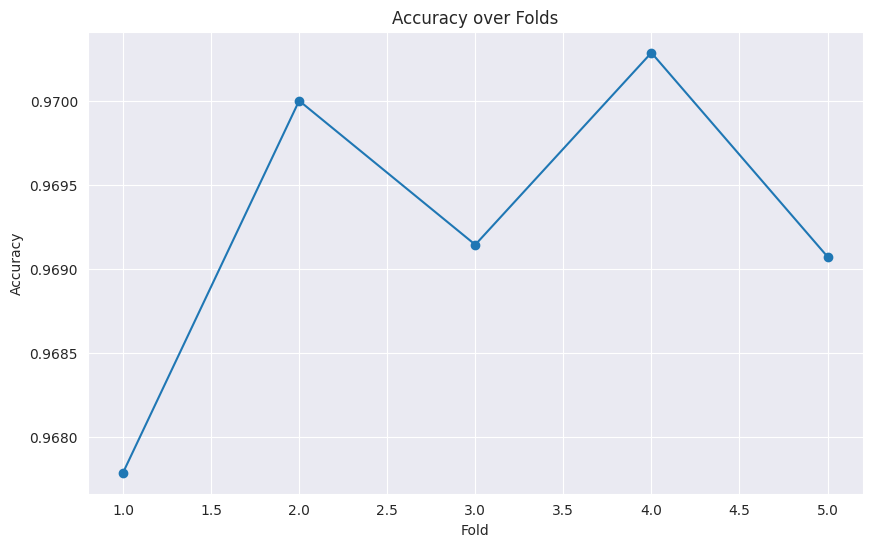


Classification Report for the last fold:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1375
           1       0.98      0.98      0.98      1613
           2       0.97      0.96      0.97      1414
           3       0.97      0.96      0.96      1414
           4       0.96      0.98      0.97      1364
           5       0.98      0.96      0.97      1265
           6       0.98      0.99      0.98      1360
           7       0.97      0.97      0.97      1429
           8       0.96      0.96      0.96      1375
           9       0.95      0.94      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



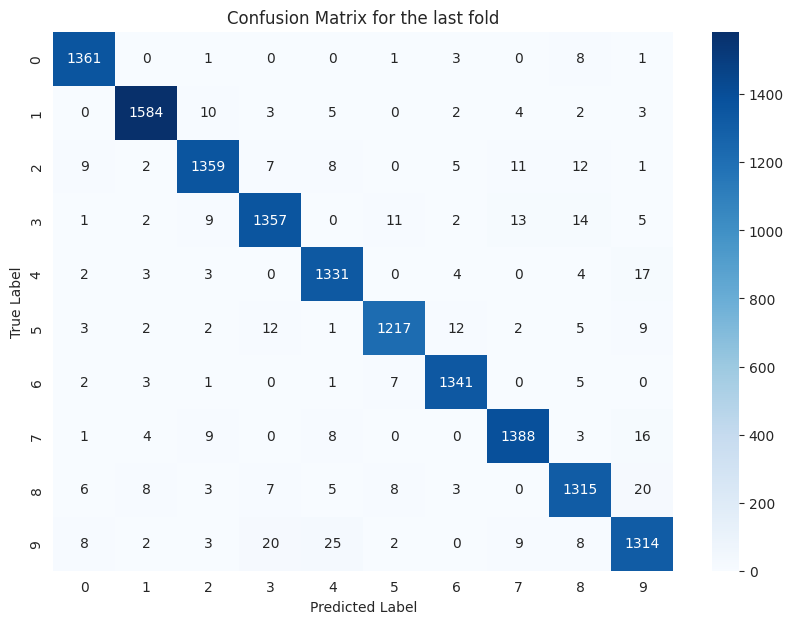

In [15]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from tools.inputs_utils import load_and_preprocess_mnist_dataset

# Load and preprocess the MNIST dataset
mnist_features_normalized, mnist_labels = load_and_preprocess_mnist_dataset()
mnist_features_normalized = mnist_features_normalized.to_numpy()
mnist_labels = mnist_labels.to_numpy()

print(f'MNIST features shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')

output_folder = './mnist_model_checkpoints'

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store accuracy for each fold
accuracy_scores = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_features_normalized)
current_fold = 1

# Define the parameter grid for hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Random Forest with Flattened Image Data
for train_index, test_index in kf.split(mnist_features_normalized):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_features_normalized[train_index], mnist_features_normalized[test_index]
    y_train, y_test = mnist_labels[train_index], mnist_labels[test_index]
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Calculate the accuracy for this fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    print(f"Fold {current_fold}/{total_folds} Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average accuracy across all folds
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Accuracy: {avg_accuracy}')

# Plot the evolution of the accuracy over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(accuracy_scores) + 1), accuracy_scores, marker='o')
plt.title('Accuracy over Folds')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the last fold
print("\nClassification Report for the last fold:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the last fold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


MNIST embedding shape: (70000, 2)
MNIST labels shape: (70000, 1)
MNIST features left out shape: (3500, 2)
MNIST labels left out shape: (3500, 1)
MNIST features remaining shape: (66500, 2)
MNIST labels remaining shape: (66500, 1)
There is an overlap of 9.93% points in the discrete space
The number of cells in the discrete space is 3094248
The shape of the discrete space is (1832, 1689)
Maximum in each dimension: 17.169851303100586
delete_heatmap: No heatmap with the name mnist_heatmap exists
Shape embeddings_scores_df:  (3500, 2)


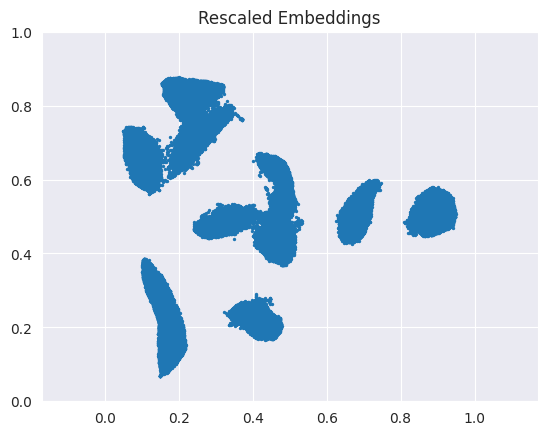

Creating heatmap


In [45]:
# load /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/embeddings.npy and plot it
import numpy as np
import pandas as pd

mnist_features_normalized = np.load('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/embeddings.npy')
mnist_labels = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/mnist_labels.csv', header=0).to_numpy()

# shuffle the indices
indices = np.arange(len(mnist_features_normalized))
np.random.shuffle(indices)
mnist_features_normalized = mnist_features_normalized[indices]
mnist_labels = mnist_labels[indices]

# take 5% out of the dataset (features ans labels)
leave_out_size = int(len(mnist_features_normalized) * 0.05)
mnist_features_normalized_left_out = mnist_features_normalized[:leave_out_size]
mnist_labels_left_out = mnist_labels[:leave_out_size]
mnist_features_normalized_remaining = mnist_features_normalized[leave_out_size:]
mnist_labels_remaining = mnist_labels[leave_out_size:]

print(f'MNIST embedding shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')
print(f'MNIST features left out shape: {mnist_features_normalized_left_out.shape}')
print(f'MNIST labels left out shape: {mnist_labels_left_out.shape}')
print(f'MNIST features remaining shape: {mnist_features_normalized_remaining.shape}')
print(f'MNIST labels remaining shape: {mnist_labels_remaining.shape}')

# now create a DiscreteLatentSpace object with the remaining features and labels
from tools.emuse_utils import DiscreteLatentSpace

dls = DiscreteLatentSpace(None, mnist_features_normalized_remaining, margin=5)
# create the discrete space (remember to rescale the embedding)
dls.rescale_embedding(dls.raw_embeddings)
dls.create_discrete_space(dls.rescaled_embeddings, 10)

# create a heatmap with the left out features and labels
dls.delete_heatmap('mnist_heatmap')
# for the heatmap the parameter is a dataframe embeddings_scores_df with the embeddings (one tuple a cell) and associated scores
col_names = ['coord', 'labels']
embeddings_scores_df = pd.DataFrame(data={'coord': [tuple(coord) for coord in mnist_features_normalized_left_out], 'labels': mnist_labels_left_out.flatten()}, columns=col_names)
print('Shape embeddings_scores_df: ', embeddings_scores_df.shape)

# plot the rescaled embeddings
dls.plot_rescaled_embedding()

# plot the heatmap

print('Creating heatmap')
# 
# dls.create_heatmap_spaces(embeddings_scores_df, 'mnist_heatmap', smoothing_fwhm=10)
# dls.plot_discrete_embedding(heatmap_name='mnist_heatmap')
# plot the heatmap
# dls.plot_heatmap('mnist_heatmap')



Accuracy: 0.9115939849624061

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      6561
         1.0       0.96      0.86      0.90      7478
         2.0       0.85      0.92      0.89      6651
         3.0       0.92      0.89      0.91      6745
         4.0       0.90      0.91      0.91      6475
         5.0       0.90      0.92      0.91      6015
         6.0       0.89      0.98      0.93      6507
         7.0       0.89      0.94      0.91      6935
         8.0       0.88      0.87      0.87      6483
         9.0       0.96      0.85      0.90      6650

    accuracy                           0.91     66500
   macro avg       0.91      0.91      0.91     66500
weighted avg       0.91      0.91      0.91     66500



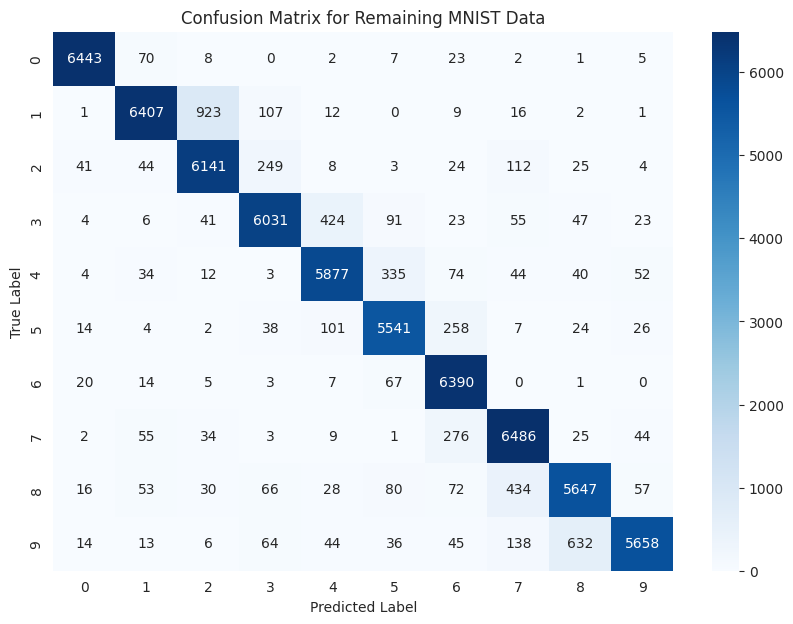

Min max ss: 1.2879680532151947 11.734969969976339


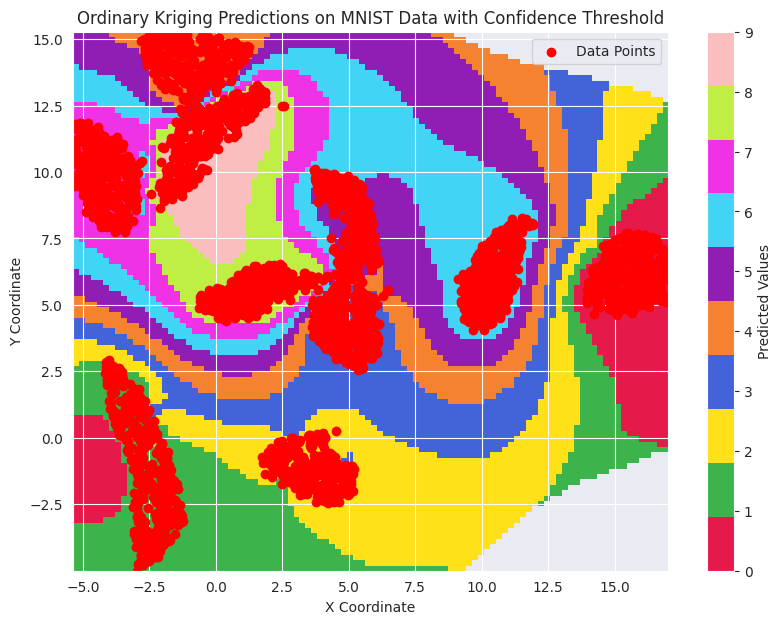

In [20]:
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming mnist_features_normalized_left_out and mnist_labels_left_out are already loaded
mnist_features = mnist_features_normalized_left_out
mnist_labels = mnist_labels_left_out.astype(float)

# Assuming mnist_features_normalized_remaining and mnist_labels_remaining are already loaded
mnist_features_remaining = mnist_features_normalized_remaining
mnist_labels_remaining = mnist_labels_remaining.astype(float)

# Extracting the coordinates (X, Y) and values (Z) for Kriging
X = mnist_features[:, 0]
Y = mnist_features[:, 1]
Z = mnist_labels

# Creating an Ordinary Kriging model
OK = OrdinaryKriging(X, Y, Z, variogram_model='spherical')

# Coordinates where we want to predict the values
X_new = mnist_features_remaining[:, 0]
Y_new = mnist_features_remaining[:, 1]

# Performing the prediction
Z_pred, ss = OK.execute('points', X_new, Y_new)

# Round predictions to nearest integer to evaluate classification accuracy
Z_pred_rounded = np.round(Z_pred)

# Calculate accuracy
accuracy = accuracy_score(mnist_labels_remaining, Z_pred_rounded)
print(f'Accuracy: {accuracy}')

# Print classification report
print("\nClassification Report:")
print(classification_report(mnist_labels_remaining, Z_pred_rounded))

# Confusion matrix
conf_matrix = confusion_matrix(mnist_labels_remaining, Z_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Remaining MNIST Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Define a list of 10 distinct colors
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabebe"
]

# Create a ListedColormap
cmap = ListedColormap(colors)

# Visualization with custom colormap
gridx = np.linspace(X.min(), X.max(), 100)
gridy = np.linspace(Y.min(), Y.max(), 100)
z, ss = OK.execute('grid', gridx, gridy)

print(f'Min max ss: {ss.min()} {ss.max()}')

# Define confidence threshold (variance threshold)
confidence_threshold = 8  # Adjust this value based on your needs

# Set predictions with variance above the threshold to NaN
z[ss > confidence_threshold] = np.nan

plt.figure(figsize=(10, 7))
plt.imshow(z, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=cmap, vmin=0, vmax=9)
cb = plt.colorbar(label='Predicted Values', ticks=np.arange(10))
cb.set_ticklabels(np.arange(10))
plt.scatter(X, Y, c='r', label='Data Points')
plt.legend()
plt.title('Ordinary Kriging Predictions on MNIST Data with Confidence Threshold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
# Save as svg
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/kriging_mnist_with_confidence.svg')
plt.show()


Accuracy: 0.8907368421052632

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      6563
         1.0       0.94      0.86      0.90      7482
         2.0       0.85      0.93      0.89      6641
         3.0       0.90      0.88      0.89      6750
         4.0       0.91      0.86      0.88      6495
         5.0       0.84      0.88      0.86      5989
         6.0       0.78      0.97      0.86      6514
         7.0       0.89      0.84      0.86      6960
         8.0       0.90      0.87      0.88      6488
         9.0       0.96      0.87      0.91      6618

    accuracy                           0.89     66500
   macro avg       0.89      0.89      0.89     66500
weighted avg       0.90      0.89      0.89     66500



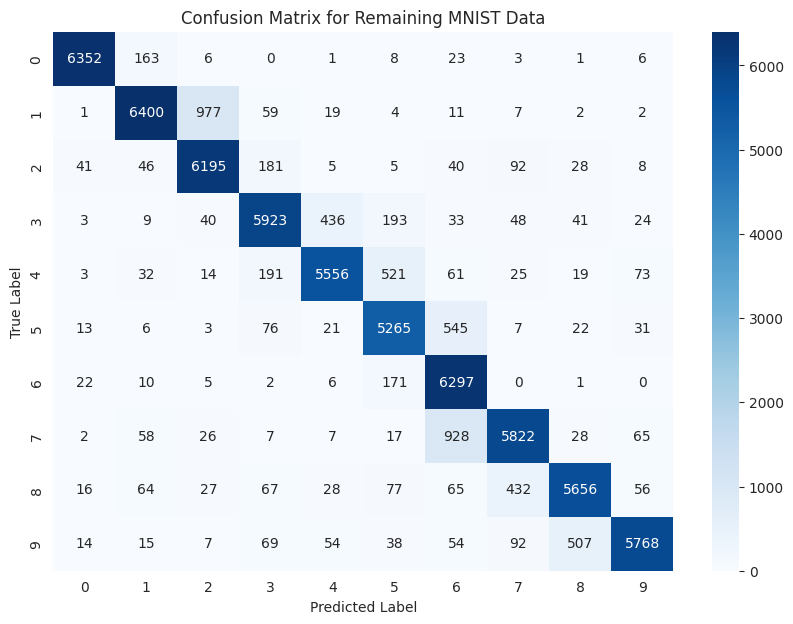

Min max ss: 0.034253480080450614 9.877431302356117


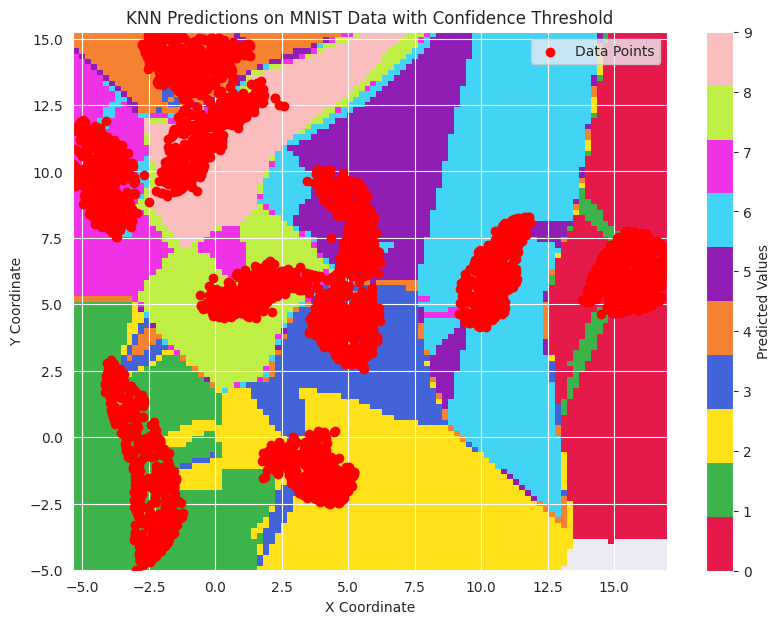

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsRegressor

# Assuming mnist_features_normalized_left_out and mnist_labels_left_out are already loaded
mnist_features = mnist_features_normalized_left_out
mnist_labels = mnist_labels_left_out.astype(float)

# Assuming mnist_features_normalized_remaining and mnist_labels_remaining are already loaded
mnist_features_remaining = mnist_features_normalized_remaining
mnist_labels_remaining = mnist_labels_remaining.astype(float)

# Extracting the coordinates (X, Y) and values (Z) for KNN
X = mnist_features[:, 0]
Y = mnist_features[:, 1]
Z = mnist_labels

# Creating a KNN model
knn = KNeighborsRegressor(n_neighbors=5)

# Training the KNN model
knn.fit(mnist_features, mnist_labels)

# Coordinates where we want to predict the values
X_new = mnist_features_remaining[:, 0]
Y_new = mnist_features_remaining[:, 1]

# Performing the prediction
Z_pred = knn.predict(mnist_features_remaining)

# Round predictions to nearest integer to evaluate classification accuracy
Z_pred_rounded = np.round(Z_pred)

# Calculate accuracy
accuracy = accuracy_score(mnist_labels_remaining, Z_pred_rounded)
print(f'Accuracy: {accuracy}')

# Print classification report
print("\nClassification Report:")
print(classification_report(mnist_labels_remaining, Z_pred_rounded))

# Confusion matrix
conf_matrix = confusion_matrix(mnist_labels_remaining, Z_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Remaining MNIST Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Define a list of 10 distinct colors
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabebe"
]

# Create a ListedColormap
cmap = ListedColormap(colors)

# Visualization with custom colormap
gridx = np.linspace(X.min(), X.max(), 100)
gridy = np.linspace(Y.min(), Y.max(), 100)
grid_x, grid_y = np.meshgrid(gridx, gridy)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]

# Predict the grid
z = knn.predict(grid_points)
z = z.reshape(grid_x.shape)

# Estimate the confidence (using the inverse of the distance to the nearest neighbors)
distances, _ = knn.kneighbors(grid_points)
ss = distances.mean(axis=1)
ss = ss.reshape(grid_x.shape)

print(f'Min max ss: {ss.min()} {ss.max()}')

# Define confidence threshold (distance threshold)
confidence_threshold = np.percentile(ss, 99)  # Adjust this value based on your needs

# Set predictions with variance above the threshold to NaN
z[ss > confidence_threshold] = np.nan

plt.figure(figsize=(10, 7))
plt.imshow(z, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=cmap, vmin=0, vmax=9)
cb = plt.colorbar(label='Predicted Values', ticks=np.arange(10))
cb.set_ticklabels(np.arange(10))
plt.scatter(X, Y, c='r', label='Data Points')
plt.legend()
plt.title('KNN Predictions on MNIST Data with Confidence Threshold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
# Save as svg
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/knn_mnist_with_confidence.svg')
plt.show()


Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 1/5 MSE: 0.5867952624683666, Baseline MSE: 7.952857142857143, Accuracy: 0.8985714285714286
Model checkpoint saved for fold 1 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Fold 2/5 MSE: 0.6261751778991115, Baseline MSE: 8.23, Accuracy: 0.9014285714285715
Model checkpoint saved for fold 2 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_2.pkl
Starting fold 3/5
Training completed for fold 3/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 3/5 MSE: 0.7710633053463718, Baseline MSE: 8.441428571428572, Accuracy: 0.9028571428571428
Model checkpoint saved for fold 3 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_3.

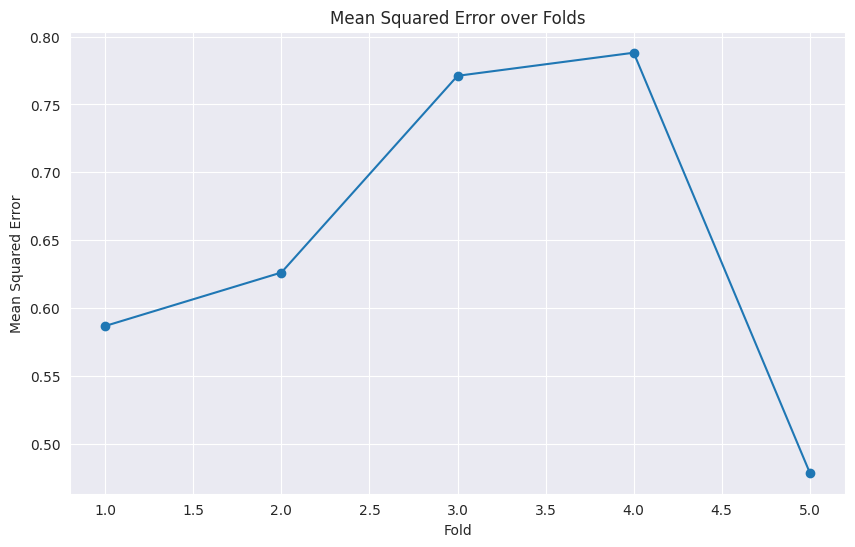


Classification Report for the ensemble:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      6561
           1       0.94      0.88      0.91      7478
           2       0.89      0.92      0.90      6651
           3       0.91      0.90      0.91      6745
           4       0.87      0.90      0.89      6475
           5       0.88      0.91      0.89      6015
           6       0.90      0.96      0.93      6507
           7       0.86      0.93      0.89      6935
           8       0.90      0.84      0.87      6483
           9       0.96      0.89      0.92      6650

    accuracy                           0.91     66500
   macro avg       0.91      0.91      0.91     66500
weighted avg       0.91      0.91      0.91     66500



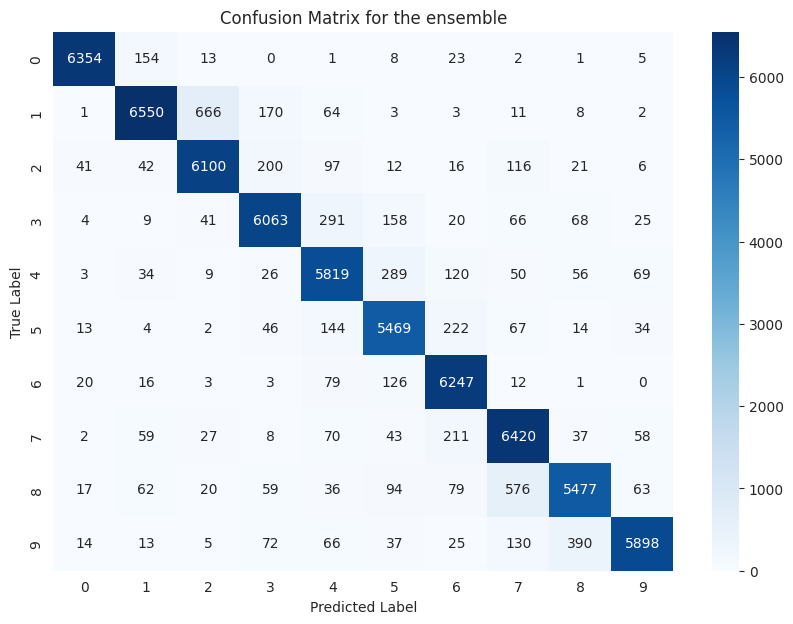

In [7]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor

output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

mnist_embedding = mnist_features_normalized_left_out
mnist_labels_int = mnist_labels_left_out.astype(int)

# Dataset for final evaluation
mnist_features_remaining = mnist_features_normalized[leave_out_size:]
mnist_labels_remaining = mnist_labels[leave_out_size:].astype(int)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the mean squared error and other metrics for each fold
mse_scores = []
baseline_mse_scores = []
loss_history = []
accuracy_scores = []

# To store the models
models = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_embedding)
current_fold = 1

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

for train_index, test_index in kf.split(mnist_embedding):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_embedding[train_index], mnist_embedding[test_index]
    y_train, y_test = mnist_labels_int[train_index], mnist_labels_int[test_index]
    
    # Reshape y_train to be a 1D array
    y_train = y_train.ravel()
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    models.append(best_rf)
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Round predictions to nearest integer
    y_pred_rounded = np.round(y_pred)
    
    # Calculate the mean squared error for this fold
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    loss_history.append(mse)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_rounded)
    accuracy_scores.append(accuracy)
    
    # Baseline model: predict the mean of y_train
    baseline_pred = np.mean(y_train)
    baseline_mse = mean_squared_error(y_test, np.full_like(y_test, baseline_pred))
    baseline_mse_scores.append(baseline_mse)
    
    print(f"Fold {current_fold}/{total_folds} MSE: {mse}, Baseline MSE: {baseline_mse}, Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average mean squared error and accuracy across all folds
avg_mse = np.mean(mse_scores)
avg_baseline_mse = np.mean(baseline_mse_scores)
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average Baseline Mean Squared Error: {avg_baseline_mse}')
print(f'Average Accuracy: {avg_accuracy}')

# Ensemble predictions on the remaining dataset
ensemble_predictions = np.zeros(mnist_labels_remaining.shape[0])

for model in models:
    ensemble_predictions += model.predict(mnist_features_remaining)

# Average the predictions
ensemble_predictions /= len(models)
ensemble_predictions_rounded = np.round(ensemble_predictions)

# Evaluate ensemble performance
ensemble_mse = mean_squared_error(mnist_labels_remaining, ensemble_predictions)
ensemble_accuracy = accuracy_score(mnist_labels_remaining, ensemble_predictions_rounded)
print(f'Ensemble Mean Squared Error: {ensemble_mse}')
print(f'Ensemble Accuracy: {ensemble_accuracy}')

# Plot the evolution of the loss (mean squared error) over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('Mean Squared Error over Folds')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the ensemble
print("\nClassification Report for the ensemble:")
print(classification_report(mnist_labels_remaining, ensemble_predictions_rounded))

conf_matrix = confusion_matrix(mnist_labels_remaining, ensemble_predictions_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Starting fold 1/5
Training completed for fold 1/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 1/5 MSE: 0.5888881245104405, Baseline MSE: 8.602642857142857, Accuracy: 0.9522142857142857
Model checkpoint saved for fold 1 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_1.pkl
Starting fold 2/5
Training completed for fold 2/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 2/5 MSE: 0.5676944542358917, Baseline MSE: 8.579142857142857, Accuracy: 0.9528571428571428
Model checkpoint saved for fold 2 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_2.pkl
Starting fold 3/5
Training completed for fold 3/5 with best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Fold 3/5 MSE: 0.5237669590118222, Baseline MSE: 8.5105, Accuracy: 0.9513571428571429
Model checkpoint saved for fold 3 at /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res/rf_model_fold_

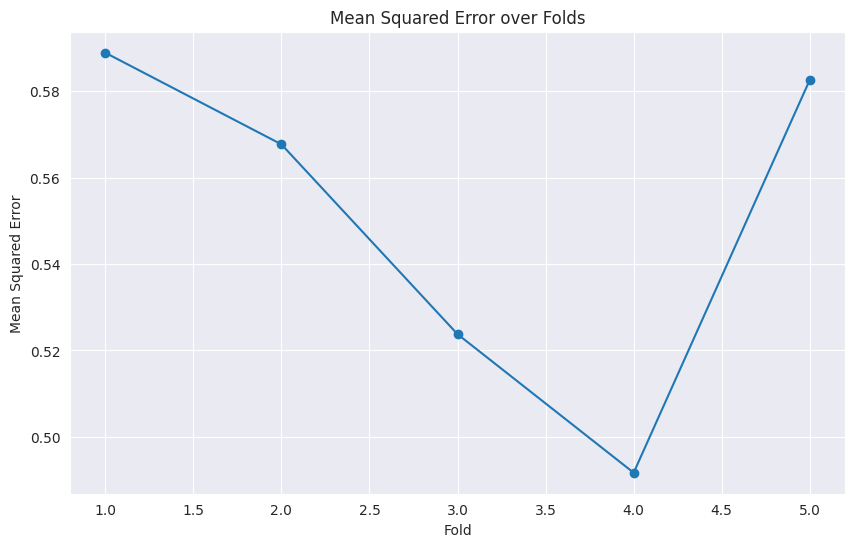


Classification Report for the last fold:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1375
           1       0.95      0.95      0.95      1613
           2       0.95      0.95      0.95      1414
           3       0.96      0.94      0.95      1414
           4       0.94      0.95      0.95      1364
           5       0.95      0.95      0.95      1265
           6       0.96      0.99      0.97      1360
           7       0.94      0.97      0.96      1429
           8       0.94      0.93      0.93      1375
           9       0.96      0.92      0.94      1391

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000



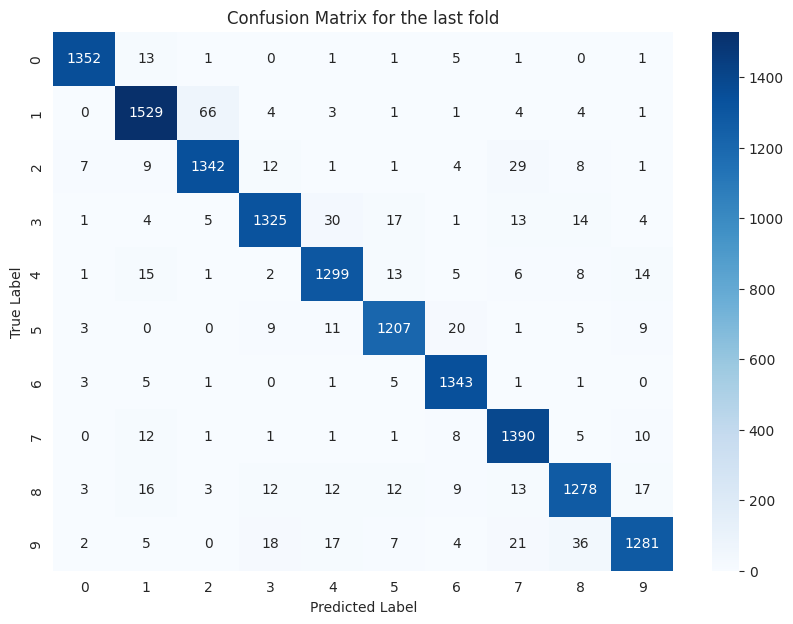

In [8]:
import numpy as np
import os
import pickle
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor

output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

mnist_embedding = mnist_features_normalized_left_out
mnist_labels_int = mnist_labels_left_out.astype(int)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the mean squared error and other metrics for each fold
mse_scores = []
baseline_mse_scores = []
loss_history = []
accuracy_scores = []

# Progress tracking
total_folds = kf.get_n_splits(mnist_embedding)
current_fold = 1

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

for train_index, test_index in kf.split(mnist_embedding):
    print(f"Starting fold {current_fold}/{total_folds}")
    
    # Split the data into training and testing sets
    X_train, X_test = mnist_embedding[train_index], mnist_embedding[test_index]
    y_train, y_test = mnist_labels_int[train_index], mnist_labels_int[test_index]
    
    # Reshape y_train to be a 1D array
    y_train = y_train.ravel()
    
    # Perform grid search with cross-validation for hyperparameter tuning
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
    
    # Fit the model
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Training completed for fold {current_fold}/{total_folds} with best parameters: {grid_search.best_params_}")

    # Predict the labels for the test set
    y_pred = best_rf.predict(X_test)
    
    # Round predictions to nearest integer
    y_pred_rounded = np.round(y_pred)
    
    # Calculate the mean squared error for this fold
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    loss_history.append(mse)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_rounded)
    accuracy_scores.append(accuracy)
    
    # Baseline model: predict the mean of y_train
    baseline_pred = np.mean(y_train)
    baseline_mse = mean_squared_error(y_test, np.full_like(y_test, baseline_pred))
    baseline_mse_scores.append(baseline_mse)
    
    print(f"Fold {current_fold}/{total_folds} MSE: {mse}, Baseline MSE: {baseline_mse}, Accuracy: {accuracy}")

    # Save the model checkpoint
    checkpoint_path = os.path.join(output_folder, f'rf_model_fold_{current_fold}.pkl')
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(best_rf, f)
    
    print(f"Model checkpoint saved for fold {current_fold} at {checkpoint_path}")
    
    current_fold += 1

# Calculate the average mean squared error and accuracy across all folds
avg_mse = np.mean(mse_scores)
avg_baseline_mse = np.mean(baseline_mse_scores)
avg_accuracy = np.mean(accuracy_scores)
print(f'Average Mean Squared Error: {avg_mse}')
print(f'Average Baseline Mean Squared Error: {avg_baseline_mse}')
print(f'Average Accuracy: {avg_accuracy}')

# Plot the evolution of the loss (mean squared error) over the folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('Mean Squared Error over Folds')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

# Print classification report and plot confusion matrix for the last fold
print("\nClassification Report for the last fold:")
print(classification_report(y_test, y_pred_rounded))

conf_matrix = confusion_matrix(y_test, y_pred_rounded)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the last fold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


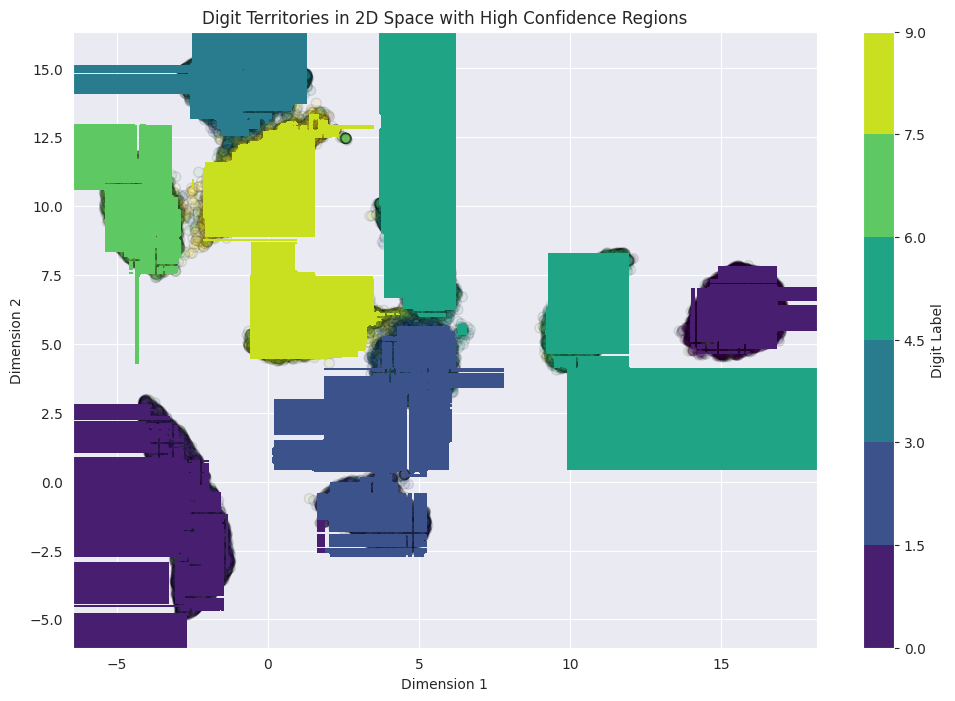

In [26]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Function to load the model checkpoints
def load_model_checkpoint(folder, fold_number):
    checkpoint_path = os.path.join(folder, f'rf_model_fold_{fold_number}.pkl')
    with open(checkpoint_path, 'rb') as f:
        model = pickle.load(f)
    return model

# Define the output folder where the models are saved
output_folder = '/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/test_res'

# Number of folds
k = 5

# Load the model from the last fold (or you can choose any specific fold)
last_fold_number = k
rf_model = load_model_checkpoint(output_folder, last_fold_number)

# Generate a mesh grid of points in the 2D space
x_min, x_max = mnist_embedding[:, 0].min() - 1, mnist_embedding[:, 0].max() + 1
y_min, y_max = mnist_embedding[:, 1].min() - 1, mnist_embedding[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Flatten the grid so it can be used as input to the model
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the digit labels for each point in the mesh grid and calculate standard deviation of predictions
tree_predictions = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
mean_predictions = np.mean(tree_predictions, axis=0)
std_predictions = np.std(tree_predictions, axis=0)

# Round the predictions to the nearest integer
predicted_labels_rounded = np.round(mean_predictions).astype(int)

# Reshape the predicted labels and standard deviations to match the shape of the mesh grid
predicted_labels_reshaped = predicted_labels_rounded.reshape(xx.shape)
std_predictions_reshaped = std_predictions.reshape(xx.shape)

# Define a threshold for high confidence (e.g., std deviation <= 0.5 indicates high confidence)
confidence_threshold = 0.5
high_confidence_mask = std_predictions_reshaped <= confidence_threshold

# Apply the high confidence mask to the predicted labels
high_confidence_predictions = np.where(high_confidence_mask, predicted_labels_reshaped, np.nan)

# Plot the digit territories with high confidence regions
plt.figure(figsize=(12, 8))
plt.scatter(mnist_embedding[:, 0], mnist_embedding[:, 1], c=mnist_labels_int, edgecolor='k', s=50, cmap='viridis', alpha=0.1)
plt.contourf(xx, yy, high_confidence_predictions, cmap='viridis', alpha=1)
plt.colorbar(label='Digit Label')
plt.title('Digit Territories in 2D Space with High Confidence Regions')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


In [8]:
# list niftis in /gamma/Dropbox\ \(GIN\)/EMUSE/DSD_repro/disco_1333
from pathlib import Path
import nibabel as nib

disco_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_1333'

# list nifti files in lesions_folder
disco_list = [p for p in Path(disco_folder).iterdir() if p.is_file()]

original_affine = nib.load(disco_list[0]).affine

original_shape = nib.load(disco_list[0]).shape

# disco_input_matrix with nifti_dataset_to_matrix
from tools.inputs_utils import nifti_dataset_to_matrix

disco_input_matrix = nifti_dataset_to_matrix(disco_list)

1333it [00:26, 50.08it/s]


In [ ]:
# train a umap on disco_input_matrix and save in /gamma/Dropbox\ \(GIN\)/EMUSE/DSD_repro/emuse_results with train_and_save_umap_and_embeddings
from tools.UMAP_utils import train_and_save_umap_and_embeddings

output_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results'
# use seed 42
trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(disco_input_matrix, output_folder, 'disco', random_state=42)


In [3]:
# plot the embeddings
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='b', s=10)
plt.title('UMAP Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()


NameError: name 'embeddings' is not defined

<Figure size 1000x700 with 0 Axes>

In [2]:
# create a disco_dls and create the different spaces. 
from tools.emuse_utils import DiscreteLatentSpace

umap_path = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/disco_umap_model_joblib1.3.1.joblib'

disco_dls = DiscreteLatentSpace(umap_path, margin=5)

# rescale the embedding
disco_dls.rescale_embedding(disco_dls.raw_embeddings)

# create the discrete space
disco_dls.create_discrete_space(disco_dls.rescaled_embeddings, 10)


Loading the trained UMAP model to get the embeddings
There is an overlap of 9.60% points in the discrete space
The number of cells in the discrete space is 147854
The shape of the discrete space is (413, 358)
Maximum in each dimension: 13.565800666809082


In [5]:
from bcblib.tools.general_utils import parse_file_list_argument
from tools.inputs_utils import load_and_preprocess_mnist_dataset, nifti_dataset_to_matrix
# load the scores
import pandas as pd
import numpy as np
from pathlib import Path

# create a heatmap with the left out features and labels
# training set /gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_119 and scores: /gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_complete.xlsx
# test set /gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_24 and scores /gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_20.xlsx

# load the scores
training_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_complete.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)

# create_heatmap_data
from tools.inputs_utils import create_heatmap_data

training_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_119/'
training_files_list = parse_file_list_argument(training_files_folder)
# the column names are the filenames without extension. Transpose the spreadsheet and replace the indices (filenames) with the file paths (matched with the training_files_list)
training_spreadsheet = training_spreadsheet.T
filename_list = training_spreadsheet.index
# find each filename in the training_files_list
for filename in filename_list:
    for training_file in training_files_list:
        if filename in training_file:
            training_spreadsheet.rename(index={filename: training_file}, inplace=True)
            break
            
# create an input_matrix with the indices (file paths now) which are in the right order
training_input_matrix = nifti_dataset_to_matrix(training_spreadsheet.index)
# 
# training_embeddings = disco_dls.trained_umap.transform(training_input_matrix)
# 
# np.save('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy', training_embeddings)
# training_embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy')

Found 119 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_119


119it [00:02, 40.40it/s]


Shape of matched embeddings: (119, 2)
Shape of matched embeddings after removing NaNs and Infs: (75, 2)
Setting discrete embedding with shape None
Created heatmap pos_acc_disengage
Setting discrete embedding with shape (413, 358)
Created heatmap rescaled and discrete space pos_acc_disengage
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (75, 413, 358)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (75, 413, 358)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


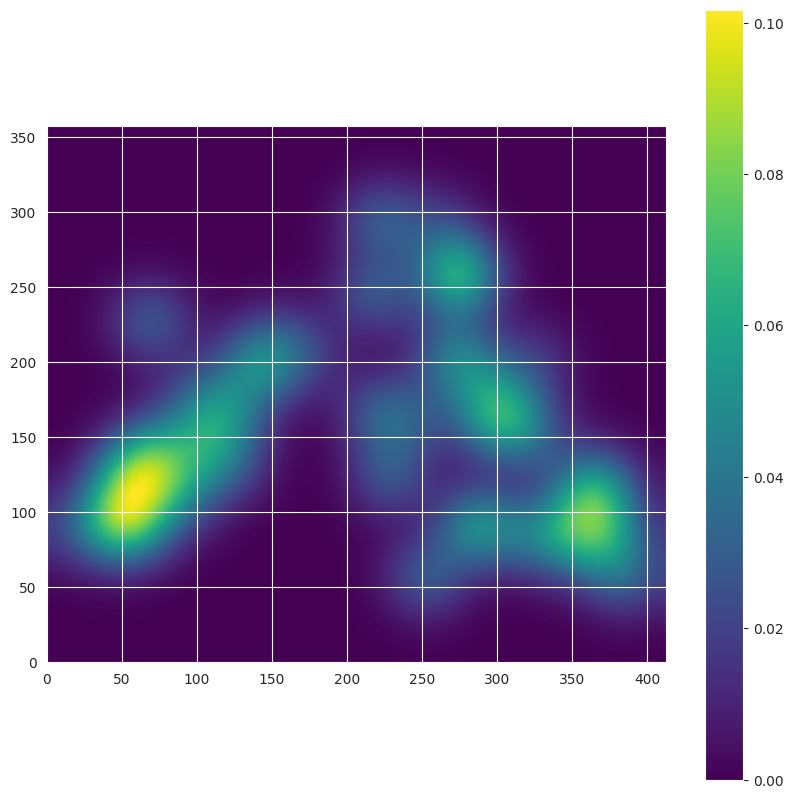

In [6]:
from tools.emuse_utils import compute_stats_on_corrected_clusters, compute_stats_on_smoothed_nplusone_dim_discrete_space

score_tag = 'pos_acc_disengage'
scores = training_spreadsheet[score_tag].to_numpy()
training_embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy')
# training_embeddings is a 2D array, the coordinates should be a tuple (x, y) (one tuple per row)
training_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
training_df['scores'] = scores
# create the heatmap data
# delete the heatmap
if 'pos_acc_disengage' in disco_dls.heatmaps:
    disco_dls.delete_heatmap('pos_acc_disengage')
if 'pos_acc_disengage' not in disco_dls.heatmaps:
    disco_dls.create_heatmap_spaces(training_df, 'pos_acc_disengage', smoothing_fwhm=None, smoothing_sigma=20)

# plot the heatmap
disco_dls.plot_heatmap('pos_acc_disengage')

# use compute_stats_on_corrected_clusters on the heatmap and plot it
statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(disco_dls.heatmaps['pos_acc_disengage'], disco_dls.heatmaps['pos_acc_disengage'].scores, correction_method='holm')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


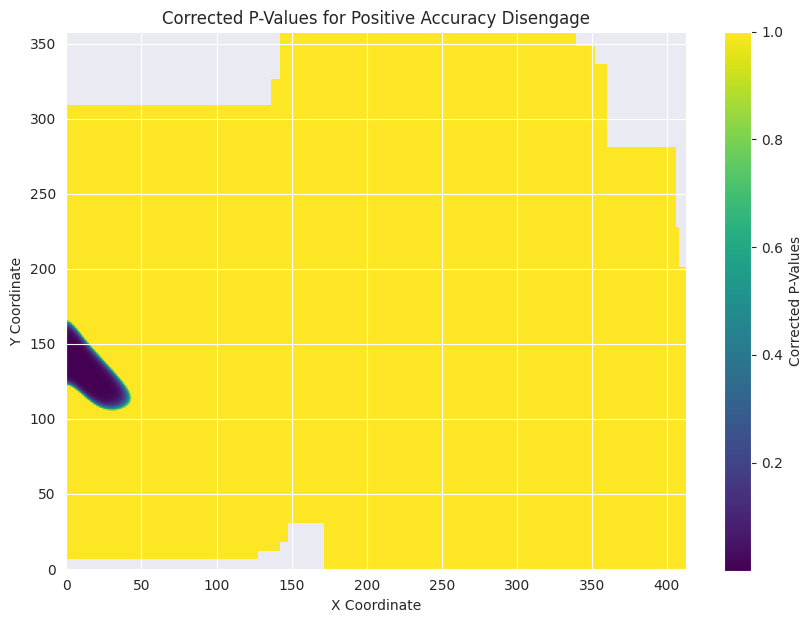

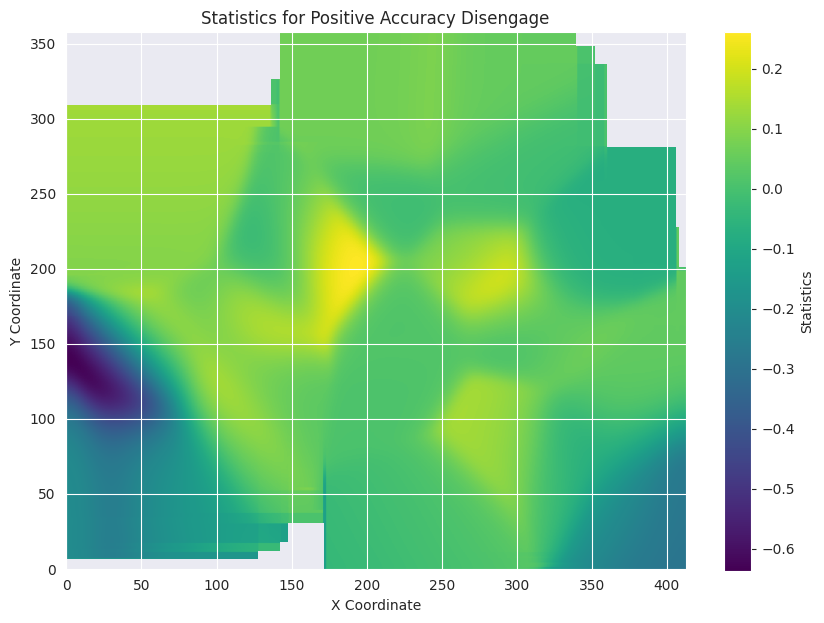

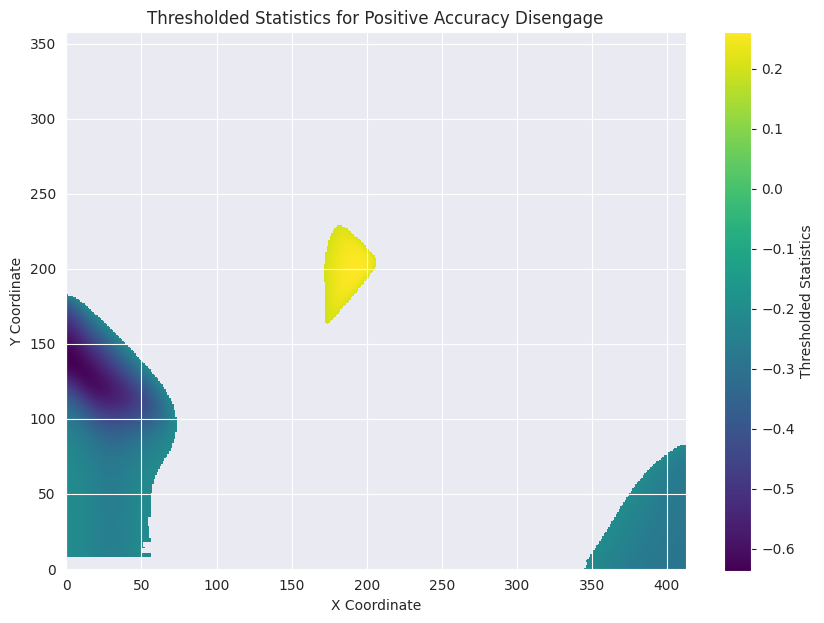

Unique values in thresholded statistics: [-0.63615315 -0.63614406 -0.63588358 ...  0.26161754  0.26169091
         nan]
Found 3 clusters


100%|██████████| 902629/902629 [03:06<00:00, 4840.50it/s]
/tmp/ipykernel_11454/2076118401.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('gist_rainbow')


TypeError: expected str, bytes or os.PathLike object, not NoneType

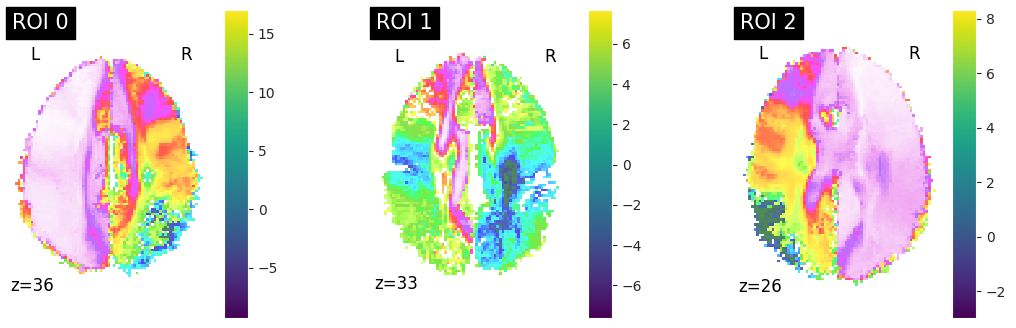

In [9]:
# plot the heatmap with the corrected pvalues
# autoreload
%load_ext autoreload
%autoreload 2

import bcblib

import importlib
importlib.reload(bcblib)
# !pip install --upgrade bcblib
import matplotlib.pyplot as plt
from bcblib.tools.visualisation import plot_multiple_rois
from tools.stats_utils import create_cluster_representative_maps

plt.figure(figsize=(10, 7))
plt.imshow(corrected_pvalues.T, cmap='viridis', origin='lower')
plt.colorbar(label='Corrected P-Values')
plt.title('Corrected P-Values for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# Plot the statistics
plt.figure(figsize=(10, 7))
plt.imshow(statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Statistics')
plt.title('Statistics for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


# plot |stats| > 0.2
thresholded_statistics = np.where(np.abs(statistics) < 0.2, np.nan, statistics)

plot_array = np.where(np.abs(statistics) < 0.2, np.nan, statistics)

plt.figure(figsize=(10, 7))
plt.imshow(plot_array.T, cmap='viridis', origin='lower')
plt.colorbar(label='Thresholded Statistics')
plt.title('Thresholded Statistics for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

print(f'Unique values in thresholded statistics: {np.unique(thresholded_statistics)}')

stat_map, pval_map, effect_size_map, centroids = create_cluster_representative_maps(thresholded_statistics, disco_dls.discrete_embeddings, disco_input_matrix, original_shape, test_name='mann-whitney')

cmap = plt.cm.get_cmap('gist_rainbow')
inverted_cmap = cmap.reversed()
plot_multiple_rois(stat_map, original_affine)
plot_multiple_rois(pval_map, original_affine)
plot_multiple_rois(effect_size_map, original_affine, prefix='effect_size_map_', image_mask=False, threshold=0.5, cmap=inverted_cmap, alpha=0.6)


# Create a mask for the rejected hypotheses
reject_mask = np.ma.masked_where(corrected_pvalues > 0.05, statistics)

# Plot the statistics that are not rejected
plt.figure(figsize=(10, 7))
plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
plt.colorbar(label='Non-rejected Statistics')
plt.title('Non-rejected Statistics for Positive Accuracy Disengage')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_11454/2967036406.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('gist_rainbow')
/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


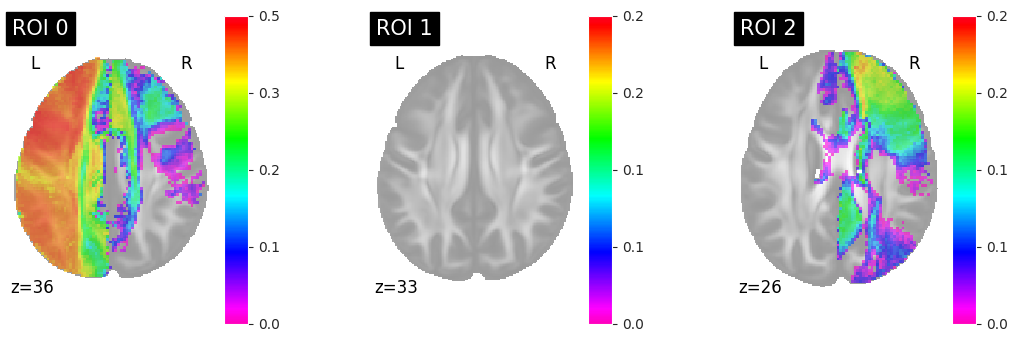

In [54]:
%load_ext autoreload
%autoreload 2

import bcblib

import importlib
importlib.reload(bcblib) 

overlay_path = '/gamma/Dropbox (GIN)/EMUSE/package/emuse/data/FSL_HCP1065_FA_1mm.nii.gz'
from nilearn.plotting import plot_roi
output_stat_maps_folder = '/gamma/Dropbox (GIN)/EMUSE/test_stat_maps'
# plot the stat_map
# plot_multiple_rois(stat_map, original_affine, output_stat_maps_folder, 'stat_map_')
# plot_multiple_rois(pval_map, original_affine, output_stat_maps_folder, 'pval_map_')
# colorbar should be the inverted gist_rainbow
cmap = plt.cm.get_cmap('gist_rainbow')
inverted_cmap = cmap.reversed()
plot_multiple_rois(effect_size_map, original_affine, overlay_path, output_stat_maps_folder, 'effect_size_map_', image_mask=True, threshold=0.1, cmap=inverted_cmap, alpha=0.6)
# plot_multiple_rois(effect_size_map[1:], original_affine, prefix='effect_size_map_', cmap=inverted_cmap, alpha=0.6)

In [24]:
# Load the scores
test_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_20.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)

# Parse the file list
test_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_24/'
test_files_list = parse_file_list_argument(test_files_folder)

# Match the filenames with the file paths
test_spreadsheet = test_spreadsheet.T
filename_list = test_spreadsheet.index

# List to store the filenames that were matched
matched_filenames = []

for filename in filename_list:
    # find each filename in the test_files_list and replace the filename with the full path
    for file_path in test_files_list:
        if Path(file_path).name.lower() == filename.lower():  # convert both to lower case for comparison
            test_spreadsheet = test_spreadsheet.rename(index={filename: file_path})
            matched_filenames.append(filename)
            break

# Find the filenames that could not be replaced
not_matched_filenames = set(filename_list) - set(matched_filenames)

print(f"The following filenames could not be replaced because they were not found: {not_matched_filenames}")
# Create an input matrix with the matched file paths
test_input_matrix = nifti_dataset_to_matrix(test_spreadsheet.index)

# Get the embeddings using the trained UMAP
test_embeddings = disco_dls.trained_umap.transform(test_input_matrix)

# Save the embeddings
np.save('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/test_embeddings.npy', test_embeddings)

# Create a DataFrame with the embeddings and scores
score_tag = 'pos_acc_disengage'
scores = test_spreadsheet[score_tag].to_numpy()
test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = scores

Found 24 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_24
The following filenames could not be replaced because they were not found: set()


20it [00:00, 43.20it/s]


Validation MSE: 0.0014997073763348334, Validation MAE: 0.02898332333333333
Normalized Validation MSE: 1.34%, Normalized Validation MAE: 8.65%
Validation MSE: 0.0032143826666666668, Validation MAE: 0.04255333333333334
Normalized Validation MSE: 2.86%, Normalized Validation MAE: 12.70%
Validation MSE: 0.0006695304227095002, Validation MAE: 0.02215672333333334
Normalized Validation MSE: 0.60%, Normalized Validation MAE: 6.61%
Validation MSE: 0.003817556034999994, Validation MAE: 0.04359366666666664
Normalized Validation MSE: 3.40%, Normalized Validation MAE: 13.01%
Validation MSE: 0.004757730845667832, Validation MAE: 0.03908333666666666
Normalized Validation MSE: 4.24%, Normalized Validation MAE: 11.67%
Test MSE: 0.0018974124903621574
Test MAE: 0.03373042210526316
Normalized Test MSE: 1.69%, Normalized Test MAE: 10.07%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/model_

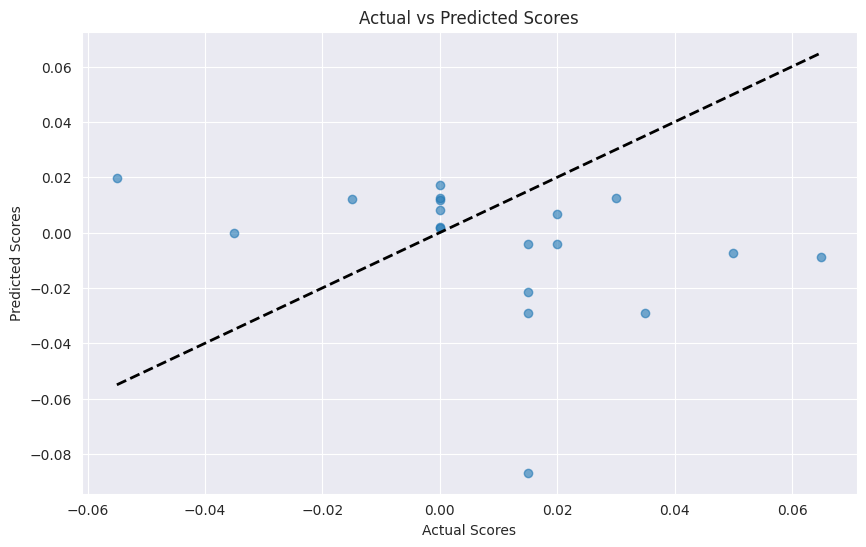

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import os

# Define the directory to save the models
model_save_dir = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training/'
os.makedirs(model_save_dir, exist_ok=True)

# Load your training and test dataframes
# Assuming training_df and test_df are already loaded

# Drop rows with NaN values in train_scores
training_df = training_df.dropna(subset=['scores'])

# Drop rows with NaN values in test_scores
test_df = test_df.dropna(subset=['scores'])

# Extract coordinates and scores from training data
train_coords = np.array([list(coord) for coord in training_df['embeddings']])
train_scores = training_df['scores'].values

# Extract coordinates and scores from test data
test_coords = np.array([list(coord) for coord in test_df['embeddings']])
test_scores = test_df['scores'].values

# Determine the range of possible values
min_score = min(np.min(train_scores), np.min(test_scores))
max_score = max(np.max(train_scores), np.max(test_scores))
range_of_values = max_score - min_score

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the trained models
models = []

# List to store MAE for validation sets
mae_scores = []

# Train multiple models using k-fold cross-validation
for train_index, val_index in kf.split(train_coords):
    X_train, X_val = train_coords[train_index], train_coords[val_index]
    y_train, y_val = train_scores[train_index], train_scores[val_index]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Store the trained model
    models.append(model)
    
    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mae_scores.append(mae_val)
    
    # Normalize errors
    normalized_mae_val = (mae_val / range_of_values) * 100
    normalized_mse_val = (mse_val / (range_of_values ** 2)) * 100
    print(f'Validation MSE: {mse_val}, Validation MAE: {mae_val}')
    print(f'Normalized Validation MSE: {normalized_mse_val:.2f}%, Normalized Validation MAE: {normalized_mae_val:.2f}%')

# Make predictions on the test data using the ensemble of models
test_predictions = np.zeros(test_coords.shape[0])
for model in models:
    test_predictions += model.predict(test_coords)
test_predictions /= len(models)

# Calculate the Mean Squared Error and Mean Absolute Error on the test data
mse_test = mean_squared_error(test_scores, test_predictions)
mae_test = mean_absolute_error(test_scores, test_predictions)

# Normalize errors
normalized_mae_test = (mae_test / range_of_values) * 100
normalized_mse_test = (mse_test / (range_of_values ** 2)) * 100

print(f'Test MSE: {mse_test}')
print(f'Test MAE: {mae_test}')
print(f'Normalized Test MSE: {normalized_mse_test:.2f}%, Normalized Test MAE: {normalized_mae_test:.2f}%')

# Save the models
for i, model in enumerate(models):
    model_path = os.path.join(model_save_dir, f'model_fold_{i}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Model {i} saved to {model_path}')

# Visualize the predictions vs. actual scores (optional)
plt.figure(figsize=(10, 6))
plt.scatter(test_scores, test_predictions, alpha=0.6)
plt.plot([test_scores.min(), test_scores.max()], [test_scores.min(), test_scores.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.show()


Validation MSE: 0.0024159429863408336, Validation MAE: 0.03674997000000001
Normalized Validation MSE: 2.15%, Normalized Validation MAE: 10.97%
Validation MSE: 0.003040875367334333, Validation MAE: 0.04116000666666666
Normalized Validation MSE: 2.71%, Normalized Validation MAE: 12.29%
Validation MSE: 0.0003659695004111667, Validation MAE: 0.01587658333333333
Normalized Validation MSE: 0.33%, Normalized Validation MAE: 4.74%
Validation MSE: 0.0014369449350000005, Validation MAE: 0.03028366666666667
Normalized Validation MSE: 1.28%, Normalized Validation MAE: 9.04%
Validation MSE: 0.0042261984426928325, Validation MAE: 0.03699331666666666
Normalized Validation MSE: 3.77%, Normalized Validation MAE: 11.04%
Test MSE: 0.0017876661845131995
Test MAE: 0.03177943052631579
Normalized Test MSE: 1.59%, Normalized Test MAE: 9.49%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_new/model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_ne

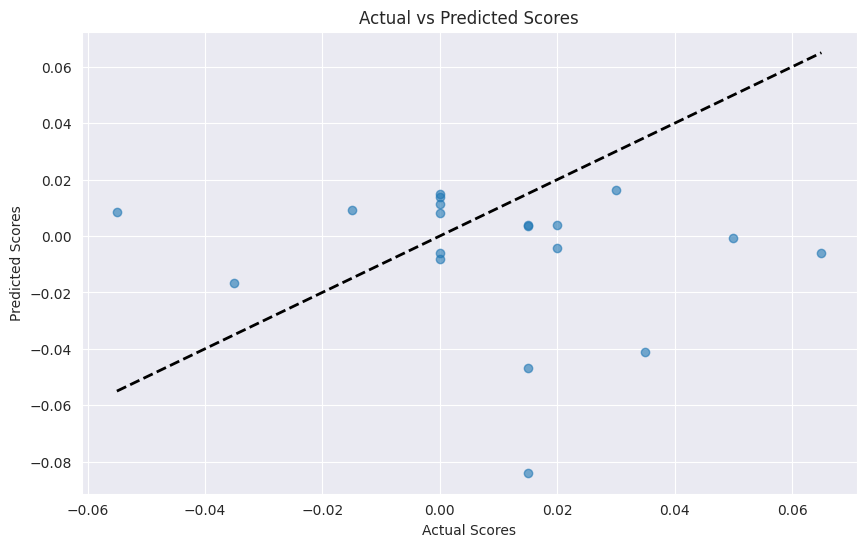

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import os

# Define the directory to save the models
new_model_save_dir = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/test_model_training_new/'
os.makedirs(new_model_save_dir, exist_ok=True)

# Load your training and test dataframes
# Assuming training_df and test_df are already loaded
# Assuming train_input_matrix and test_input_matrix are already loaded

# Drop rows with NaN values in scores and get the indices
train_valid_indices = training_df.dropna(subset=['scores']).index
test_valid_indices = test_df.dropna(subset=['scores']).index

# Filter the train_input_matrix and test_input_matrix based on the non-NaN scores
train_input_filtered = training_input_matrix[train_valid_indices]
train_scores_filtered = training_df.loc[train_valid_indices, 'scores'].values

test_input_filtered = test_input_matrix[test_valid_indices]
test_scores_filtered = test_df.loc[test_valid_indices, 'scores'].values

# Determine the range of possible values
min_score = min(np.min(train_scores_filtered), np.min(test_scores_filtered))
max_score = max(np.max(train_scores_filtered), np.max(test_scores_filtered))
range_of_values = max_score - min_score

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# List to store the trained models
new_models = []

# List to store MAE for validation sets
new_mae_scores = []

# Train multiple models using k-fold cross-validation
for train_index, val_index in kf.split(train_input_filtered):
    X_train, X_val = train_input_filtered[train_index], train_input_filtered[val_index]
    y_train, y_val = train_scores_filtered[train_index], train_scores_filtered[val_index]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Store the trained model
    new_models.append(model)
    
    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    new_mae_scores.append(mae_val)
    
    # Normalize errors
    normalized_mae_val = (mae_val / range_of_values) * 100
    normalized_mse_val = (mse_val / (range_of_values ** 2)) * 100
    print(f'Validation MSE: {mse_val}, Validation MAE: {mae_val}')
    print(f'Normalized Validation MSE: {normalized_mse_val:.2f}%, Normalized Validation MAE: {normalized_mae_val:.2f}%')

# Make predictions on the test data using the ensemble of models
test_predictions = np.zeros(test_input_filtered.shape[0])
for model in new_models:
    test_predictions += model.predict(test_input_filtered)
test_predictions /= len(new_models)

# Calculate the Mean Squared Error and Mean Absolute Error on the test data
mse_test = mean_squared_error(test_scores_filtered, test_predictions)
mae_test = mean_absolute_error(test_scores_filtered, test_predictions)

# Normalize errors
normalized_mae_test = (mae_test / range_of_values) * 100
normalized_mse_test = (mse_test / (range_of_values ** 2)) * 100

print(f'Test MSE: {mse_test}')
print(f'Test MAE: {mae_test}')
print(f'Normalized Test MSE: {normalized_mse_test:.2f}%, Normalized Test MAE: {normalized_mae_test:.2f}%')

# Save the models
for i, model in enumerate(new_models):
    model_path = os.path.join(new_model_save_dir, f'model_fold_{i}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Model {i} saved to {model_path}')

# Visualize the predictions vs. actual scores (optional)
plt.figure(figsize=(10, 6))
plt.scatter(test_scores_filtered, test_predictions, alpha=0.6)
plt.plot([test_scores_filtered.min(), test_scores_filtered.max()], [test_scores_filtered.min(), test_scores_filtered.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.show()


In [73]:
from pathlib import Path
import pandas as pd

# image_paths_list_to_matrix
images_folder = "/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/Images"

filtered_files = [str(p) for p in Path(images_folder).rglob('*-N.*')]

print(f'Number of filtered files: {len(filtered_files)}')

# match with "Model" in /gamma/Dropbox (GIN)/EMUSE/faces/filtered_face_attractive_US.csv
# load the scores
face_scores_spread_sheet = '/gamma/Dropbox (GIN)/EMUSE/faces/filtered_face_attractive_US.csv'

scores_df = pd.read_csv(face_scores_spread_sheet, index_col=0)
print(f'Size of scores dataframe: {scores_df.shape}')

# make a new df with the Model associated with file path
model_to_path_dict = {}
for m in scores_df.index:
    found = False
    for f in filtered_files:
        if m in f:
            if found:
                print(f'Multiple matches found for {m}')
            found = True
            model_to_path_dict[m] = f
    if not found:
        print(f'No match found for {m}')

# create a new dataframe with the model and the file path
model_path_df = pd.DataFrame(model_to_path_dict.items(), columns=['Model', 'File Path'])
print(f'Size of model_path_df: {model_path_df.shape}')
print(model_path_df.head())
# save in /gamma/Dropbox (GIN)/EMUSE/faces/filtered_files_model_match.csv
model_path_df.to_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files_model_match.csv')


Number of filtered files: 831
Size of scores dataframe: (685, 1)
Size of model_path_df: (685, 2)
    Model                                          File Path
0  AF-200  /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3...
1  AF-201  /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3...
2  AF-202  /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3...
3  AF-203  /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3...
4  AF-204  /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3...


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Train input shape: (548, 43), Train scores shape: (548, 1)
Test input shape: (137, 43), Test scores shape: (137, 1)
Train input value shape: (548, 43), Train scores value shape: (548, 1)
Test input value shape: (137, 43), Test scores value shape: (137, 1)
There is an overlap of 8.03% points in the discrete space
The number of cells in the discrete space is 87314
The shape of the discrete space is (298, 293)
Maximum in each dimension: 14.39889144897461


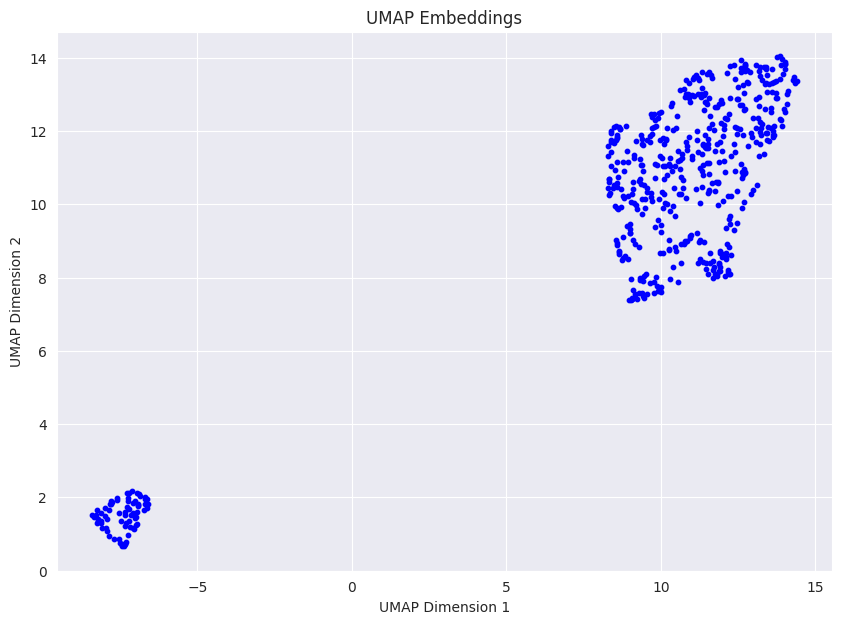

Shape of matched embeddings: (548, 2)
Shape of matched embeddings after removing NaNs and Infs: (548, 2)
Setting discrete embedding with shape None
Created heatmap Attractive
Setting discrete embedding with shape (298, 293)
Created heatmap rescaled and discrete space Attractive
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (548, 298, 293)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (548, 298, 293)
Heatmap Attractive created
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


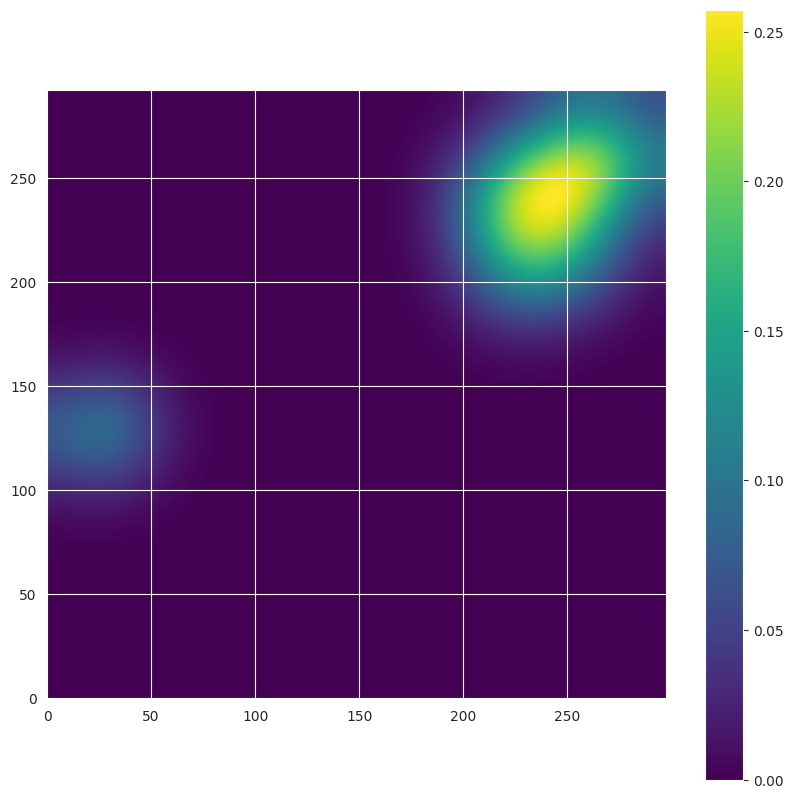

Statistics for Attractive computed


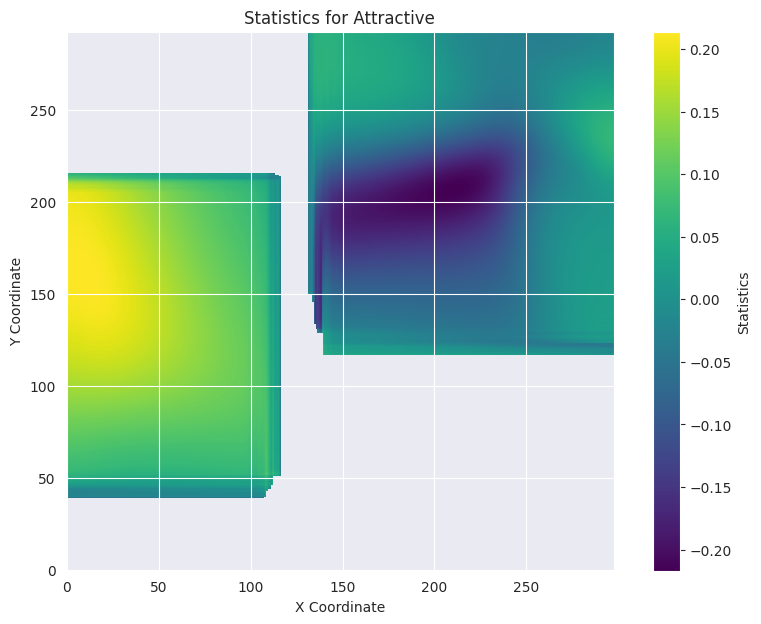

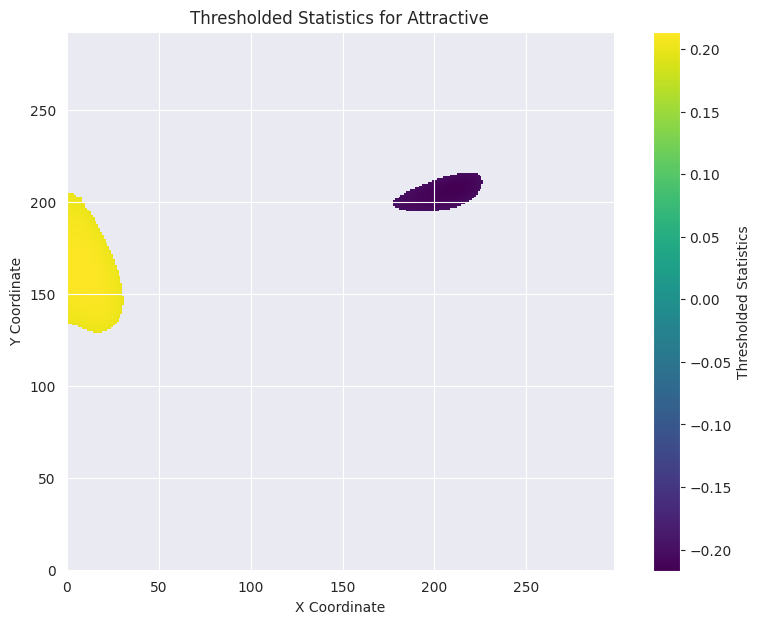

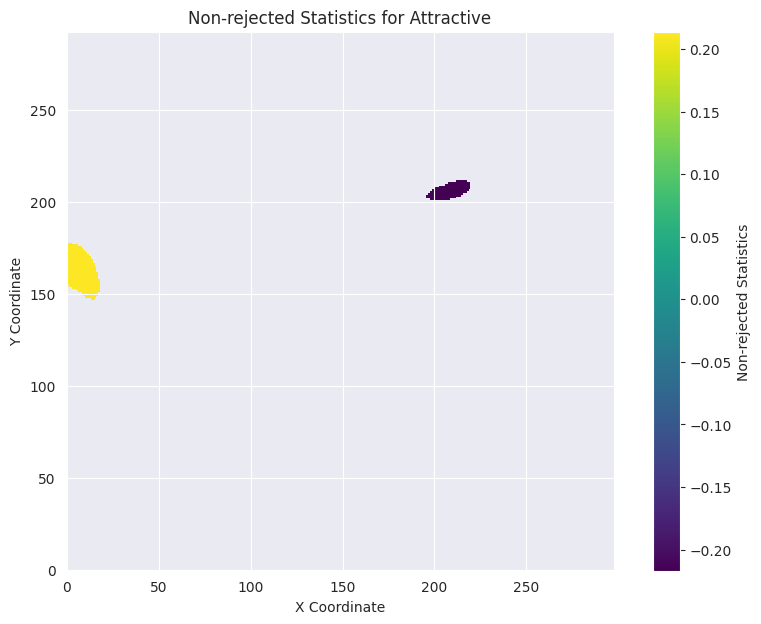

Found 2 clusters


100%|██████████| 43/43 [00:00<00:00, 4022.10it/s]

Shape of the maps: (43,)



100%|██████████| 43/43 [00:00<00:00, 3500.00it/s]


Shape of the maps: (43,)
Attractive - Avg Training R^2: 0.8496522430405582
Attractive - Avg Normalized Training MSE: 0.56%, Avg Normalized Training MAE: 5.98%, Avg MAE_max% Training: 4.33%
Attractive - Test R^2: -0.13026187786379406
Attractive - Normalized Test MSE: 4.57%, Normalized Test MAE: 17.55%, Test MAE_max%: 12.69%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:297: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


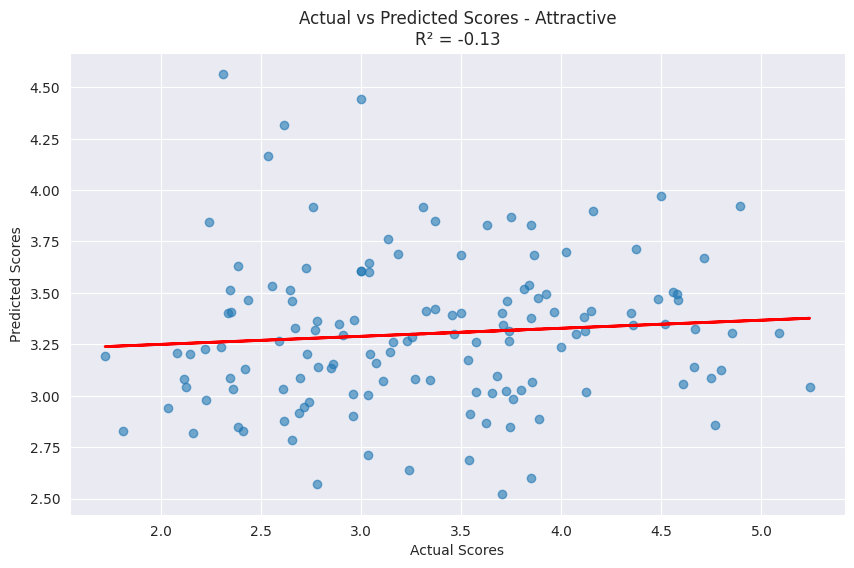

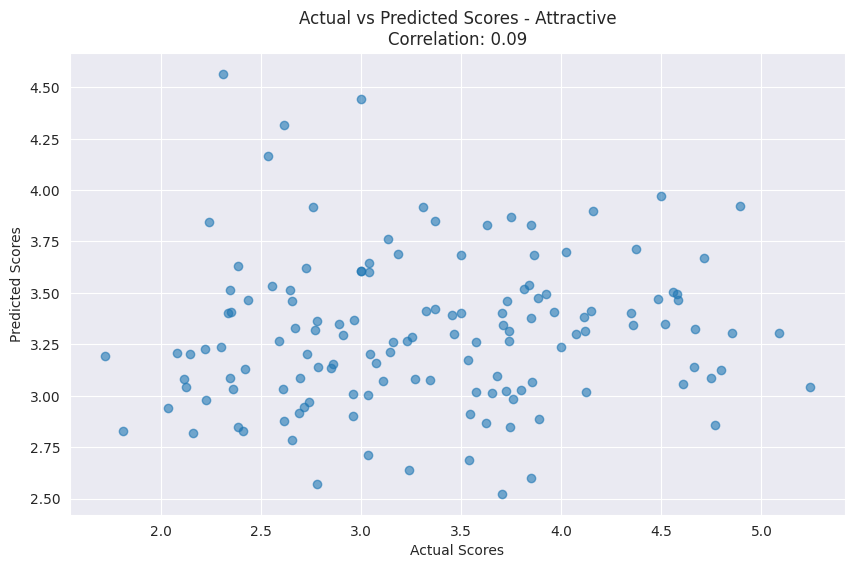

In [9]:
import platform
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from tools.inputs_utils import spreadsheet_to_input_df
from tools.UMAP_utils import train_and_save_umap_and_embeddings
from tools.emuse_utils import DiscreteLatentSpace, compute_stats_on_smoothed_nplusone_dim_discrete_space
from tools.stats_utils import train_model, train_model_kriging, train_model_xgboost_with_fold_grid_search, create_cluster_representative_maps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bcblib.tools.visualisation import plot_multiple_rois
from bcblib.tools.general_utils import parse_file_list_argument
from bcblib.tools.arrays_utils import separate_clusters_and_extract_coords


# reload modules
%load_ext autoreload
%autoreload 2

"""
Now the faces dataset
"""

# Detect the operating system
system_name = platform.system()

# Set the base path based on the detected operating system
if system_name == "Windows":
    base_path = Path("S:\GIN Dropbox\Chris Foulon")
else:
    base_path = Path("/gamma/Dropbox (GIN)/")

# Define file paths using the base path
model_path_spreadsheet = base_path / "EMUSE/faces/filtered_files_model_match.csv"
face_input_spreadsheet = base_path / "EMUSE/faces/filtered_face_characteristics_US.csv"
face_scores_spread_sheet = base_path / "EMUSE/faces/filtered_face_attractive_US.csv"
face_output_folder = base_path / "EMUSE/faces/res_EMUSE"

input_df = spreadsheet_to_input_df(str(face_input_spreadsheet), headers=0, index_col=0, columns_are_features=True)
scores_df = pd.read_csv(face_scores_spread_sheet, index_col=0)

# Split the data into training and test sets
train_input_df, test_input_df, train_scores_df, test_scores_df = train_test_split(input_df, scores_df, test_size=0.2, random_state=42)


model_path_df = pd.read_csv(model_path_spreadsheet, header=0, index_col=0)

# print the size and value shape of the train and test dfs 
print(f'Train input shape: {train_input_df.shape}, Train scores shape: {train_scores_df.shape}')
print(f'Test input shape: {test_input_df.shape}, Test scores shape: {test_scores_df.shape}')
print(f'Train input value shape: {train_input_df.values.shape}, Train scores value shape: {train_scores_df.values.shape}')
print(f'Test input value shape: {test_input_df.values.shape}, Test scores value shape: {test_scores_df.values.shape}')

faces_input_matrix = train_input_df.values

umap_path = Path(face_output_folder, 'faces_umap_model_joblib1.3.1.joblib')
embeddings_path = Path(face_output_folder, 'faces_embeddings.npy')
if not Path(umap_path).exists():
    trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(faces_input_matrix, face_output_folder, 'faces', random_state=42)
else:
    trained_umap = joblib.load(umap_path)
    embeddings = np.load(embeddings_path)

"""
CREATE DISCRETE SPACE AND HEATMAPS
5% margins around the embeddings
<15% of overlap between the data points
"""
# umap_path = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/disco_umap_model_joblib1.3.1.joblib'
if True or not Path(face_output_folder, 'faces_dls.dls').exists():
    faces_dls = DiscreteLatentSpace(trained_umap, margin=5) # could use the umap_path
    
    # rescale the embedding
    faces_dls.rescale_embedding(faces_dls.raw_embeddings)
    
    # create the discrete space
    faces_dls.create_discrete_space(faces_dls.rescaled_embeddings, 10)
    
    # create the heatmap spaces with the training AND test datasets combined (for the faces dataset) with disco_dls.trained_umap.transform
    training_embeddings = faces_dls.trained_umap.transform(train_input_df.values)
    
    np.save(Path(face_output_folder, 'training_embeddings.npy'), training_embeddings)
    
    test_embeddings = faces_dls.trained_umap.transform(test_input_df.values)
    
    np.save(Path(face_output_folder, 'test_embeddings.npy'), test_embeddings)
    
    faces_dls.save(Path(face_output_folder, 'faces_dls.dls'))
else:
    faces_dls = DiscreteLatentSpace.load(Path(face_output_folder, 'faces_dls.dls'))
    training_embeddings = np.load(Path(face_output_folder, 'training_embeddings.npy'))
    test_embeddings = np.load(Path(face_output_folder, 'test_embeddings.npy'))

# plot embeddings
plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='b', s=10)
plt.title('UMAP Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()

# Process for the single score 'Attractive'
score_tag = 'Attractive'
score_output_folder = Path(face_output_folder, score_tag)
Path(score_output_folder).mkdir(parents=True, exist_ok=True)

# Prepare DataFrames for training and test sets
train_scores = train_scores_df[score_tag].to_numpy()
train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
train_df['scores'] = train_scores

test_scores = test_scores_df[score_tag].to_numpy()
test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = test_scores

# Create heatmap for the combined dataset
if score_tag in faces_dls.heatmaps:
    faces_dls.delete_heatmap(score_tag)
if score_tag not in faces_dls.heatmaps:
    faces_dls.create_heatmap_spaces(train_df, score_tag, smoothing_fwhm=None, smoothing_sigma=20)

print(f'Heatmap {score_tag} created')

faces_attractive_3d_dls = faces_dls.heatmaps[score_tag].smoothed_nplusone_dim_discrete_space

faces_dls.plot_heatmap(score_tag, output_folder=score_output_folder)

# Now we compute the correlations and display the heatmaps for each score
statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(
    faces_dls.heatmaps[score_tag], faces_dls.heatmaps[score_tag].scores, correction_method='holm')

print(f'Statistics for {score_tag} computed')

# Plot the statistics
plt.figure(figsize=(10, 7))
plt.imshow(statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Statistics')
plt.title(f'Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'raw_statistics_{score_tag}.png'))
plt.show()

# Threshold the |statistics| > 0.2 and show the space
thresholded_statistics = np.where(np.abs(statistics) < 0.2, np.nan, statistics)
plt.figure(figsize=(10, 7))
plt.imshow(thresholded_statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Thresholded Statistics')
plt.title(f'Thresholded Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'thresholded_statistics_{score_tag}.png'))
plt.show()

# Create a mask for the rejected hypotheses
reject_mask = np.ma.masked_where(corrected_pvalues > 0.05, statistics)

# Plot the statistics that are not rejected
plt.figure(figsize=(10, 7))
plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
plt.colorbar(label='Non-rejected Statistics')
plt.title(f'Non-rejected Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'non_rejected_statistics_{score_tag}.png'))
plt.show()

# Create cluster representative maps
stat_maps, pval_maps, effect_size_maps, centroids = create_cluster_representative_maps(
    thresholded_statistics, faces_dls.discrete_embeddings, faces_input_matrix, (input_df.shape[1]), test_name='mann-whitney')

# now each map contains an array with a value for each feature
# So, for each map in stat_map, pval_map, effect_size_map, create a dataframe with the feature names as the index and the values as the columns and save it as a csv with the _x_y centroid coordinates in the name
for stat_map, pval_map, effect_size_map, centroid in zip(stat_maps, pval_maps, effect_size_maps, centroids):
    # create one dataframe with the three values as columns
    tests_df = pd.DataFrame(data={'Statistics': stat_map, 'P-Values': pval_map, 'Effect Size': effect_size_map})
    # save the dataframe as a csv
    tests_df.to_csv(Path(score_output_folder, f'tests_{score_tag}_{centroid[0]}_{centroid[1]}.csv'))

# create an output folder for each prediction model (random forest, kriging, xgboost)
rf_output_folder = Path(score_output_folder, 'random_forest')
Path(rf_output_folder).mkdir(parents=True, exist_ok=True)
krigin_output_folder = Path(score_output_folder, 'kriging')
Path(krigin_output_folder).mkdir(parents=True, exist_ok=True)
xgboost_output_folder = Path(score_output_folder, 'xgboost')
Path(xgboost_output_folder).mkdir(parents=True, exist_ok=True)
# Now train and validate the predictive model
# train_model_kriging(train_df, test_df, score_tag, krigin_output_folder)
train_model(train_df, test_df, score_tag, rf_output_folder)
# train_model_xgboost_with_fold_grid_search(train_df, test_df, score_tag, xgboost_output_folder)


In [93]:
# /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_12.736017897091722_161.84340044742729.csv
handsome_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_12.736017897091722_161.84340044742729.csv', index_col=0)

# load /gamma/Dropbox (GIN)/EMUSE/faces/filtered_face_characteristics_US.csv
face_input_spreadsheet = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_face_characteristics_US.csv', index_col=0, header=0)

# the indices in handsome_df are the columns in face_input_spreadsheet. 
# print all the column names of face_input_spreadsheet where handsome_df['Effect Size'] > 0.2
print(face_input_spreadsheet.columns[handsome_df['Effect Size'] > 0.2])
print(handsome_df[handsome_df['Effect Size'] > 0.2])

Index(['PupilTopAsymmetry', 'Heartshapeness', 'ForeheadHeight'], dtype='object')
    Statistics      P-Values  Effect Size
18    5.711024  1.119798e-08     0.243963
31    5.406106  6.472895e-08     0.230937
39    5.918440  3.267645e-09     0.252823


In [94]:
# /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_203.140350877193_204.65856950067476.csv
ugly_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_203.140350877193_204.65856950067476.csv', index_col=0)

# the indices in ugly_df are the columns in face_input_spreadsheet.
# print all the column names of face_input_spreadsheet where ugly_df['Effect Size'] > 0.2 and their values
print(face_input_spreadsheet.columns[ugly_df['Effect Size'] > 0.2])
print(ugly_df[ugly_df['Effect Size'] > 0.2])

Index(['FaceShape', 'FaceRoundness', 'fWHR2'], dtype='object')
    Statistics      P-Values  Effect Size
30    5.083581  3.720014e-07     0.217160
41    4.984373  6.242943e-07     0.212922
42    5.240660  1.607206e-07     0.223870


In [99]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os
import pickle

# Assuming face_dls contains discrete_embeddings and scores
# And faces_attractive_3d_dls is a 3D array

# Prepare the data
coordinates = np.array(faces_dls.heatmaps['Attractive'].discrete_coord)
scores = np.array(faces_dls.heatmaps['Attractive'].scores)

# Extract vectors from faces_attractive_3d_dls based on coordinates
vectors = np.array([faces_attractive_3d_dls[x, y] for x, y in coordinates])

# Combine coordinates and vectors into a single feature set
features = np.hstack([coordinates, vectors])

# Ensure output folder exists
output_folder = "/gamma/Dropbox (GIN)/EMUSE/faces/test_pred"
os.makedirs(output_folder, exist_ok=True)

# Number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Lists to store metrics for each fold
r2_scores_val = []
mae_scores_val = []

# Train and evaluate the model
for train_index, val_index in kf.split(features):
    X_train, X_val = features[train_index], features[val_index]
    y_train, y_val = scores[train_index], scores[val_index]

    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    r2_val = r2_score(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)

    r2_scores_val.append(r2_val)
    mae_scores_val.append(mae_val)

# Calculate average metrics
avg_r2_val = np.mean(r2_scores_val)
avg_mae_val = np.mean(mae_scores_val)

print(f'Avg Validation R²: {avg_r2_val}')
print(f'Avg Validation MAE: {avg_mae_val}')

# Save the final model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(features, scores)
model_path = os.path.join(output_folder, 'final_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f'Model saved to {model_path}')


Avg Validation R²: -0.04438347329760226
Avg Validation MAE: 0.6331975897636244
Model saved to /gamma/Dropbox (GIN)/EMUSE/faces/test_pred/final_model.pkl


In [104]:
def estimate_memory_size(n_points, dtype_size=8):
    """
    Estimate the memory size of the covariance matrix.
    
    Parameters:
    - n_points: Number of data points
    - dtype_size: Size of the data type (default is 8 bytes for float64)
    
    Returns:
    - Estimated memory size in bytes
    """
    return n_points ** 2 * dtype_size

n_points = 20000
estimated_memory = estimate_memory_size(n_points)

# Convert to GB
estimated_memory_gb = estimated_memory / (1024 ** 3)
print(f"Estimated memory size: {estimated_memory_gb:.2f} GB")

Estimated memory size: 2.98 GB


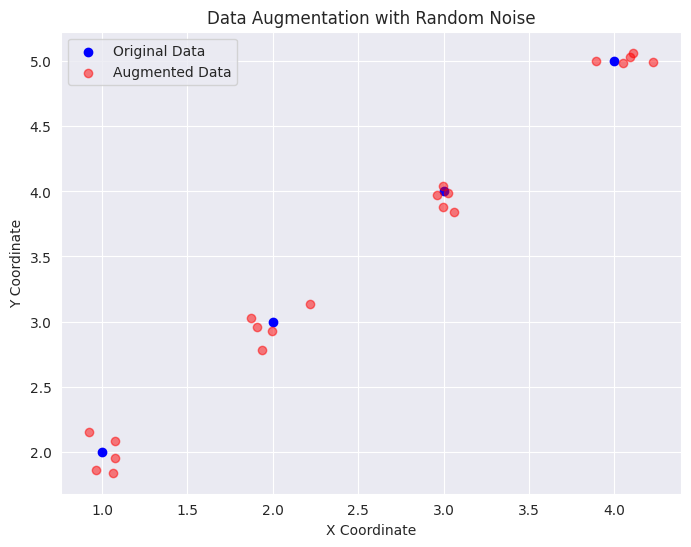

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Original dataset of 2D coordinates
coords = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
scores = np.array([10, 20, 30, 40])

# Data augmentation function
def augment_data(coords, scores, augmentation_factor=2, noise_level=0.1):
    augmented_coords = []
    augmented_scores = []
    
    for _ in range(augmentation_factor):
        noise = np.random.normal(0, noise_level, coords.shape)
        augmented_coords.append(coords + noise)
        augmented_scores.append(scores)
    
    augmented_coords = np.vstack(augmented_coords)
    augmented_scores = np.concatenate(augmented_scores)
    
    return augmented_coords, augmented_scores

# Augment the data
augmentation_factor = 5
noise_level = 0.1
augmented_coords, augmented_scores = augment_data(coords, scores, augmentation_factor, noise_level)

# Plot the original and augmented data
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], color='blue', label='Original Data')
plt.scatter(augmented_coords[:, 0], augmented_coords[:, 1], color='red', alpha=0.5, label='Augmented Data')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Data Augmentation with Random Noise')
plt.legend()
plt.show()


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

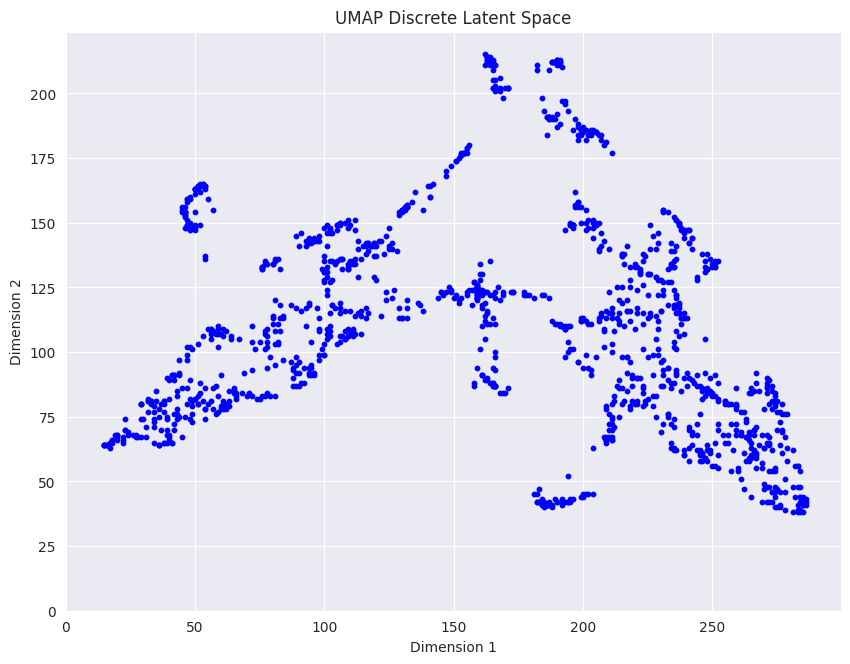

In [17]:
# /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/disco_embeddings.npy
# plot the embeddings
import numpy as np
import matplotlib.pyplot as plt
from tools.emuse_utils import DiscreteLatentSpace

# embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/disco_embeddings.npy')

# load the /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/disco_dls.dls
disco_dls = DiscreteLatentSpace.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/disco_dls.dls')

discrete_embeddings = disco_dls.discrete_embeddings

plt.figure(figsize=(10, 10))
plt.scatter(discrete_embeddings[:, 0], discrete_embeddings[:, 1], c='b', s=10)
plt.axis('scaled')
plt.xlim(0, plt.xlim()[1])  # Set x-axis to start at 0
plt.ylim(0, plt.ylim()[1])  # Set y-axis to start at 0
plt.title('UMAP Discrete Latent Space')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/discrete_umap_embeddings.png')
plt.show()

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

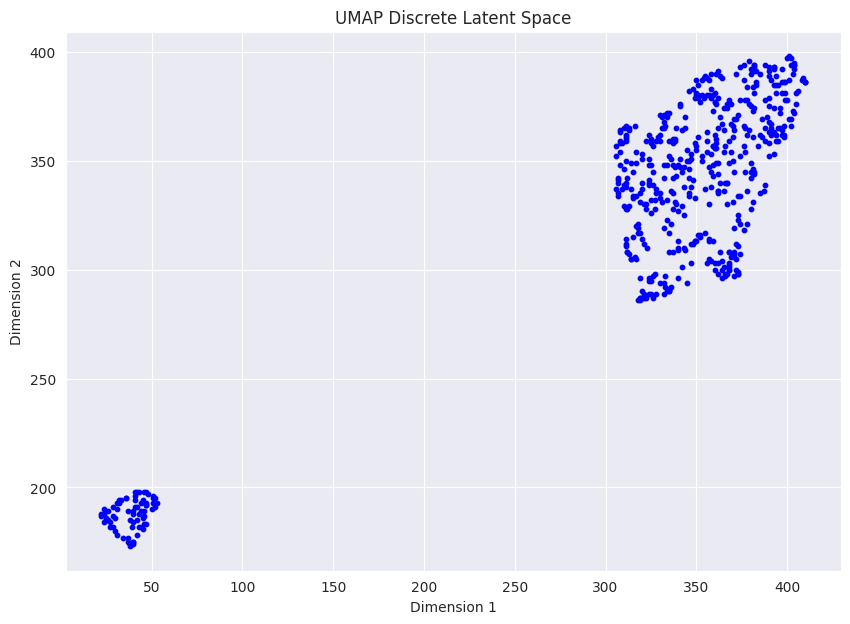

In [15]:
# Same thing with /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/faces_embeddings.npy
# embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/faces_embeddings.npy')

faces_dls = DiscreteLatentSpace.load('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/faces_dls.dls')

embeddings = faces_dls.discrete_embeddings

plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='b', s=10)
plt.title('UMAP Discrete Latent Space')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/discrete_umap_embeddings.png')
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
First element of labels: 0
Type of features: <class 'numpy.ndarray'>
Type of labels: <class 'numpy.int64'>
MNIST features shape: (1797, 64)
MNIST labels shape: (1797,)
Train features shape: (1437, 64), Train labels shape: (1437,)
Test features shape: (360, 64), Test labels shape: (360,)


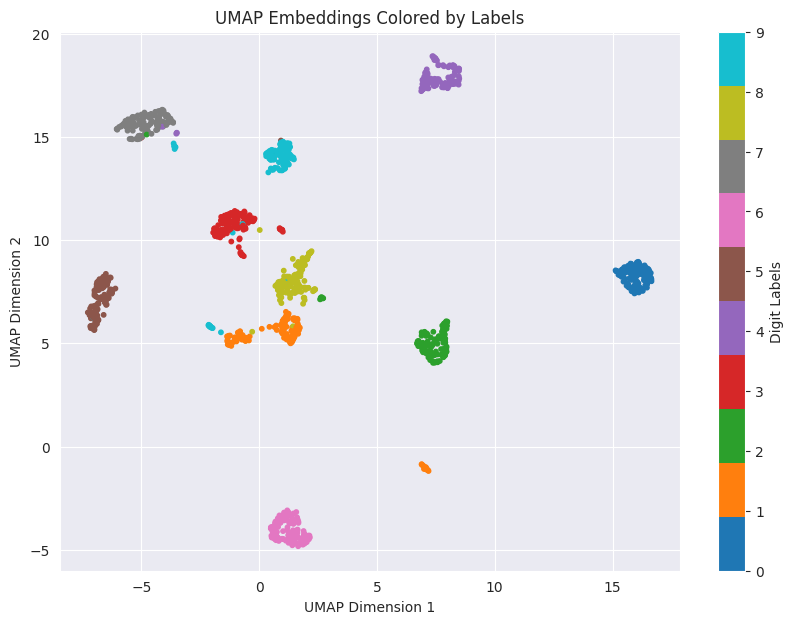

Creating / loading mnist_dls


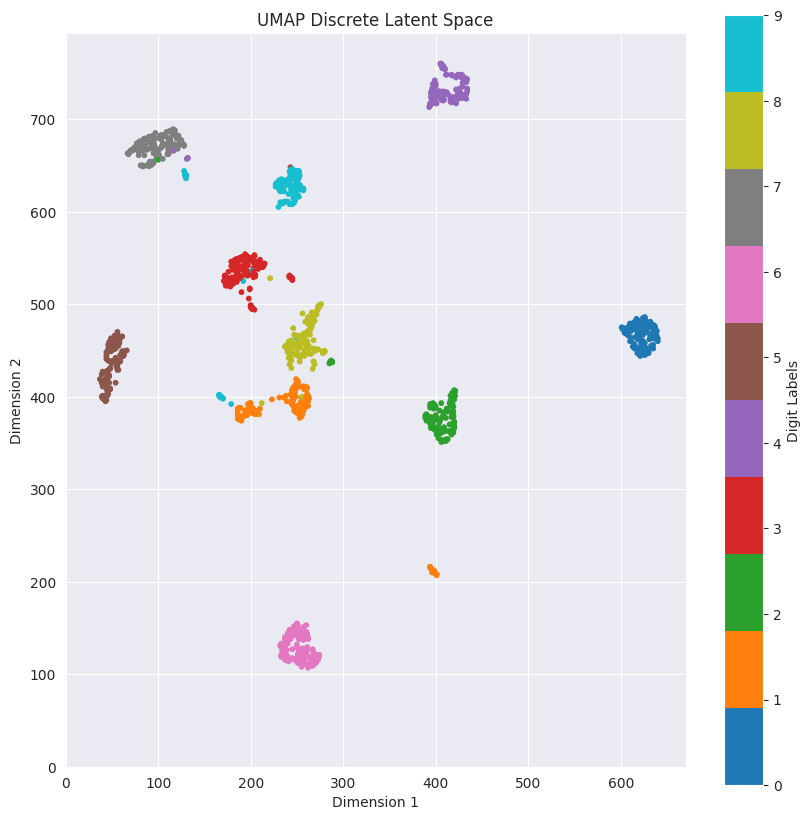

Max coord: 18.903474807739258


In [17]:
import platform
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from tools.UMAP_utils import train_and_save_umap_and_embeddings
from tools.emuse_utils import DiscreteLatentSpace, compute_stats_on_smoothed_nplusone_dim_discrete_space
from tools.stats_utils import train_model, create_cluster_representative_maps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# reload modules
%load_ext autoreload
%autoreload 2

# Load and preprocess the MNIST dataset
from tools.inputs_utils import load_and_preprocess_digits_dataset

mnist_features_normalized, mnist_labels = load_and_preprocess_digits_dataset()
if not isinstance(mnist_features_normalized, np.ndarray):
    mnist_features_normalized = mnist_features_normalized.to_numpy()
if not isinstance(mnist_labels, np.ndarray):
    mnist_labels = mnist_labels.to_numpy()
# convert labels to integers
mnist_labels = mnist_labels.astype(int)

# print the first element of the features and labels and their type
# print(f'First element of features: {mnist_features_normalized[0]}')
print(f'First element of labels: {mnist_labels[0]}')
print(f'Type of features: {type(mnist_features_normalized[0])}')
print(f'Type of labels: {type(mnist_labels[0])}')

print(f'MNIST features shape: {mnist_features_normalized.shape}')
print(f'MNIST labels shape: {mnist_labels.shape}')

# Detect the operating system
system_name = platform.system()

# Set the base path based on the detected operating system
if system_name == "Windows":
    base_path = Path("S:/GIN Dropbox/Chris Foulon")
else:
    base_path = Path("/gamma/Dropbox (GIN)/")

# Define file paths using the base path
# mnist_output_folder = base_path / "EMUSE/mnist_numbers/random_forest_output_42_final"
mnist_output_folder = base_path / "EMUSE/mnist_numbers/test_no_discrete"

# Split the data into training and test sets
train_features, test_features, train_labels, test_labels = train_test_split(mnist_features_normalized, mnist_labels, test_size=0.2, random_state=42)

# print the size and value shape of the train and test sets
print(f'Train features shape: {train_features.shape}, Train labels shape: {train_labels.shape}')
print(f'Test features shape: {test_features.shape}, Test labels shape: {test_labels.shape}')

mnist_input_matrix = train_features

umap_path = Path(mnist_output_folder, 'mnist_umap_model_joblib1.3.1.joblib')
embeddings_path = Path(mnist_output_folder, 'mnist_embeddings.npy')
if not Path(umap_path).exists():
    trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(mnist_input_matrix, mnist_output_folder, 'mnist', random_state=42)
else:
    trained_umap = joblib.load(umap_path)
    embeddings = np.load(embeddings_path)

"""
CREATE DISCRETE SPACE AND HEATMAPS
5% margins around the embeddings
<15% of overlap between the data points
"""
mnist_dls = None
if not Path(mnist_output_folder, 'mnist_dls.dls').exists():
    mnist_dls = DiscreteLatentSpace(trained_umap, margin=5)
    
    # rescale the embedding
    mnist_dls.rescale_embedding(mnist_dls.raw_embeddings)
    
    # create the discrete space
    mnist_dls.create_discrete_space(mnist_dls.rescaled_embeddings, 10)
    
    # create the heatmap spaces with the training AND test datasets combined
    training_embeddings = mnist_dls.trained_umap.transform(train_features)
    
    np.save(Path(mnist_output_folder, 'training_embeddings.npy'), training_embeddings)
    
    test_embeddings = mnist_dls.trained_umap.transform(test_features)
    
    np.save(Path(mnist_output_folder, 'test_embeddings.npy'), test_embeddings)
else:
    training_embeddings = np.load(Path(mnist_output_folder, 'training_embeddings.npy'))
    test_embeddings = np.load(Path(mnist_output_folder, 'test_embeddings.npy'))

# plot embeddings with labels as colors
plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c=train_labels, cmap='tab10', s=10)
plt.title('UMAP Embeddings Colored by Labels')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar(label='Digit Labels')
plt.savefig(Path(mnist_output_folder, 'umap_embeddings_colored_by_labels.png'))
plt.show()

# Process for the single score 'digit labels'
score_tag = 'digit_labels'
score_output_folder = Path(mnist_output_folder, score_tag)
Path(score_output_folder).mkdir(parents=True, exist_ok=True)

# Prepare DataFrames for training and test sets
train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
train_df['scores'] = train_labels

test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = test_labels

# Create heatmap for the combined dataset
print(f'Creating / loading mnist_dls')

if Path(mnist_output_folder, 'mnist_dls.dls').exists():
    mnist_dls = DiscreteLatentSpace.load(Path(mnist_output_folder, 'mnist_dls.dls'))
else:
    mnist_dls.save(Path(mnist_output_folder, 'mnist_dls.dls'))

discrete_embeddings = mnist_dls.discrete_embeddings

plt.figure(figsize=(10, 10))
plt.scatter(discrete_embeddings[:, 0], discrete_embeddings[:, 1], cmap='tab10', c=train_labels, s=10)
plt.axis('scaled')
plt.xlim(0, plt.xlim()[1])  # Set x-axis to start at 0
plt.ylim(0, plt.ylim()[1])  # Set y-axis to start at 0
plt.title('UMAP Discrete Latent Space')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.colorbar(label='Digit Labels')
plt.savefig(mnist_output_folder / 'discrete_umap_embeddings.png')
plt.show()
# Now we compute the correlations and display the heatmaps for each score
# statistics_maps, pvalues_maps, corrected_pvalues_maps, reject_maps, effect_sizes_maps = compute_category_stats_on_smoothed_nplusone_dim_discrete_space(
# mnist_dls.heatmaps[score_tag], mnist_dls.heatmaps[score_tag].scores, test_name='t-test', correction_method='holm')
# print(f'Statistics for {score_tag} computed')

# max_coord should be the (unique) max value of the embeddings
max_coord = np.max(embeddings)
print(f'Max coord: {max_coord}')

Length train labels: 1437
[0 1 2 3 4 5 6 7 8 9]


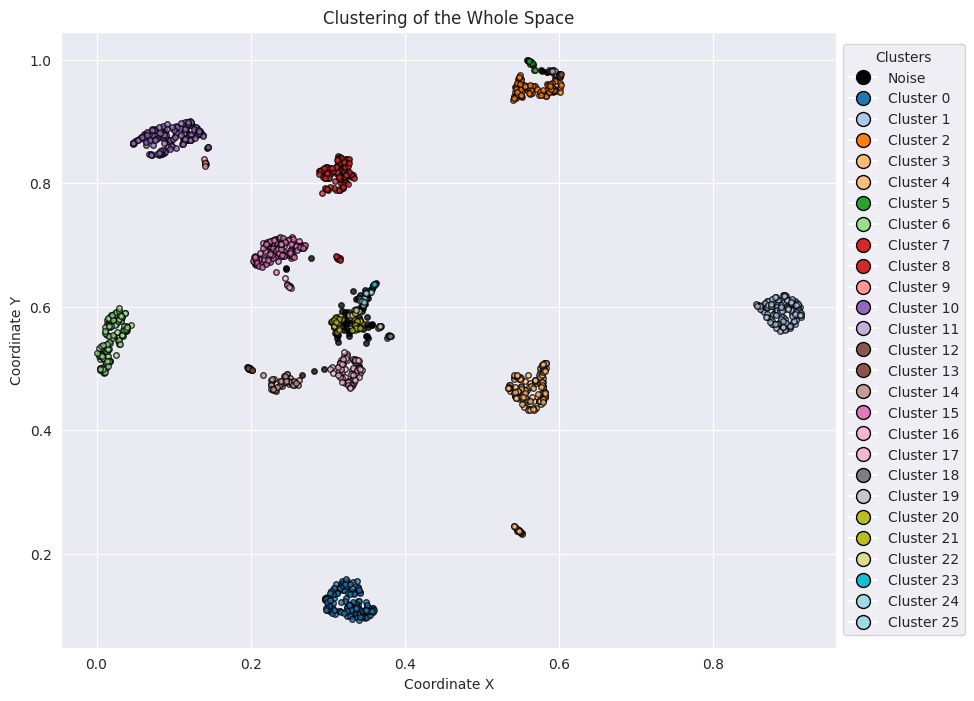

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


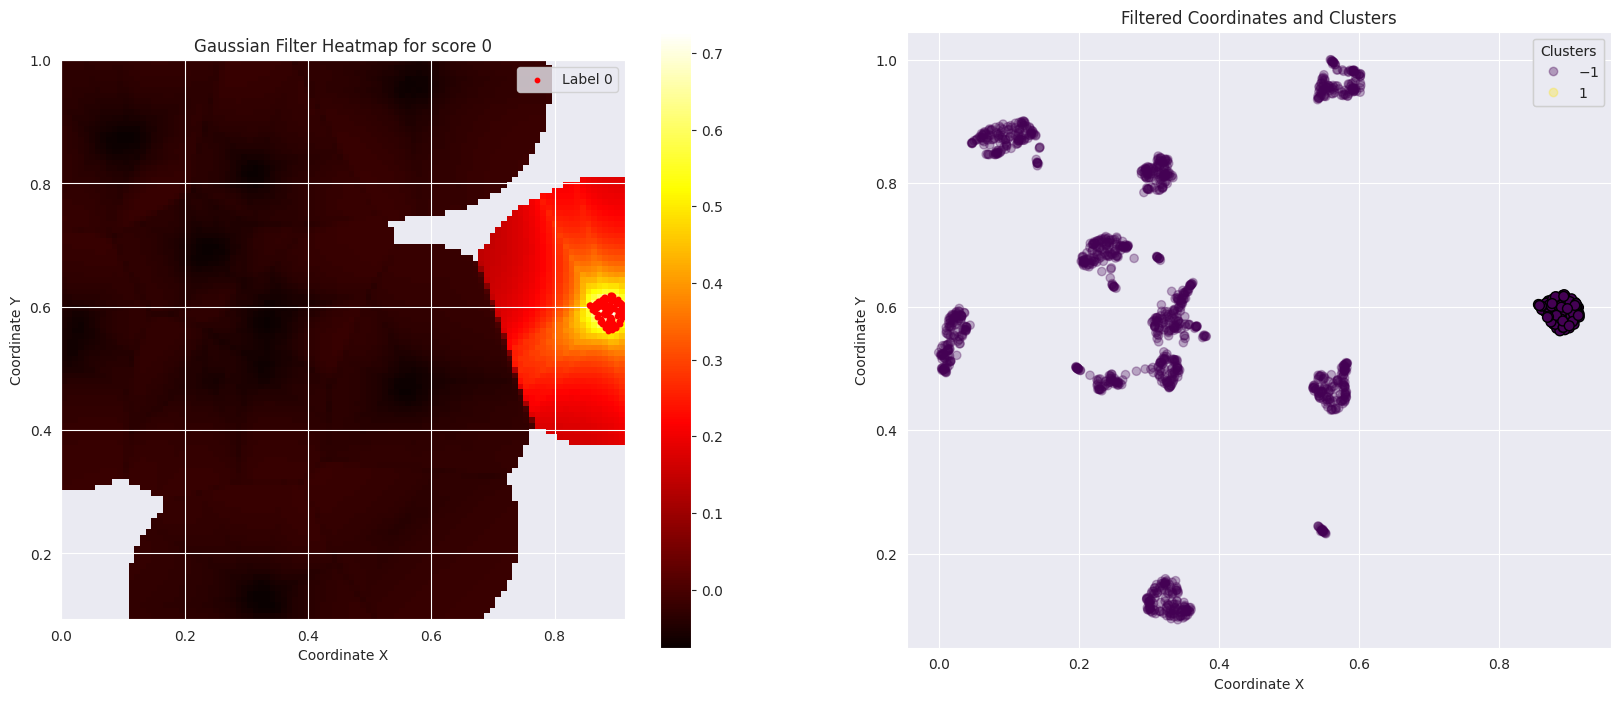

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


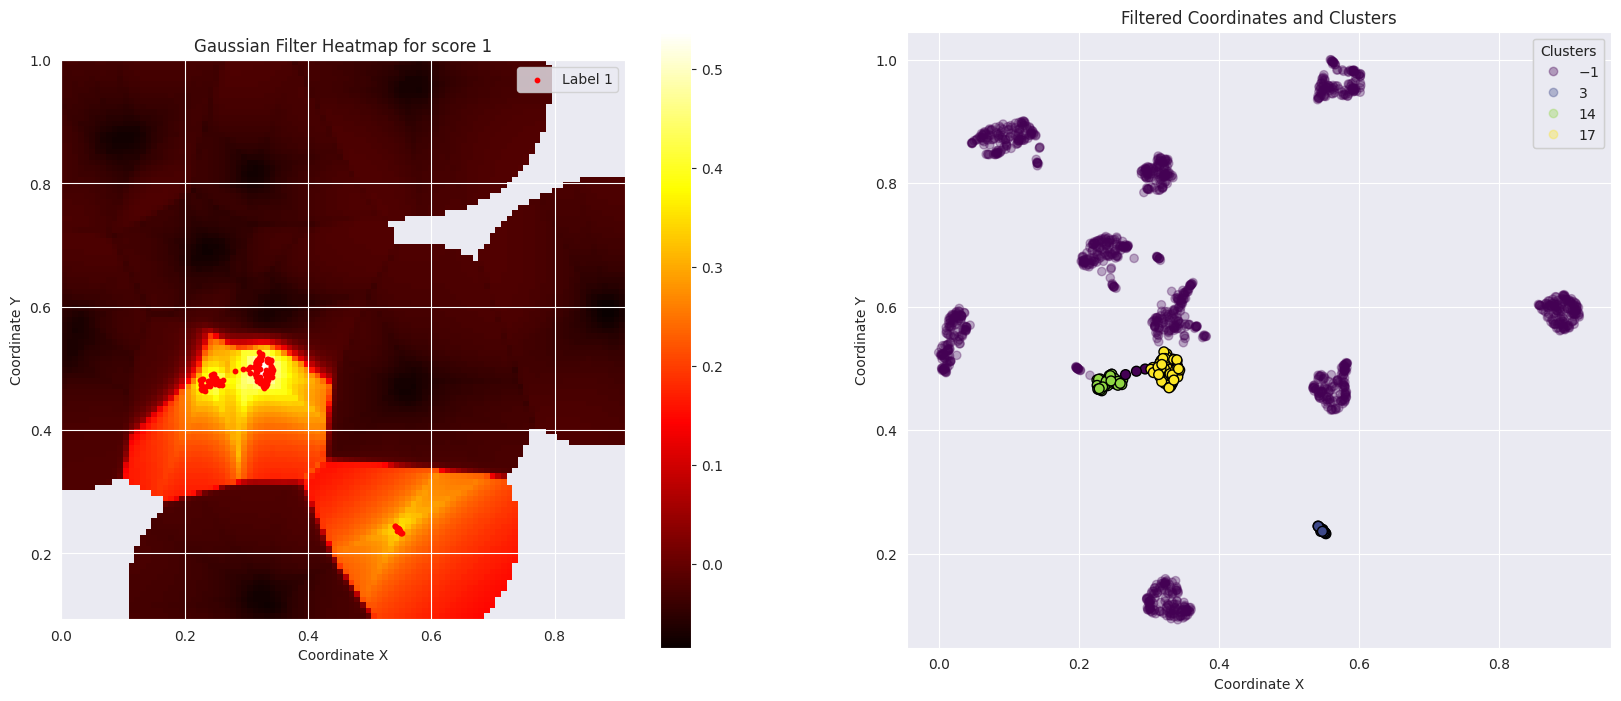

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


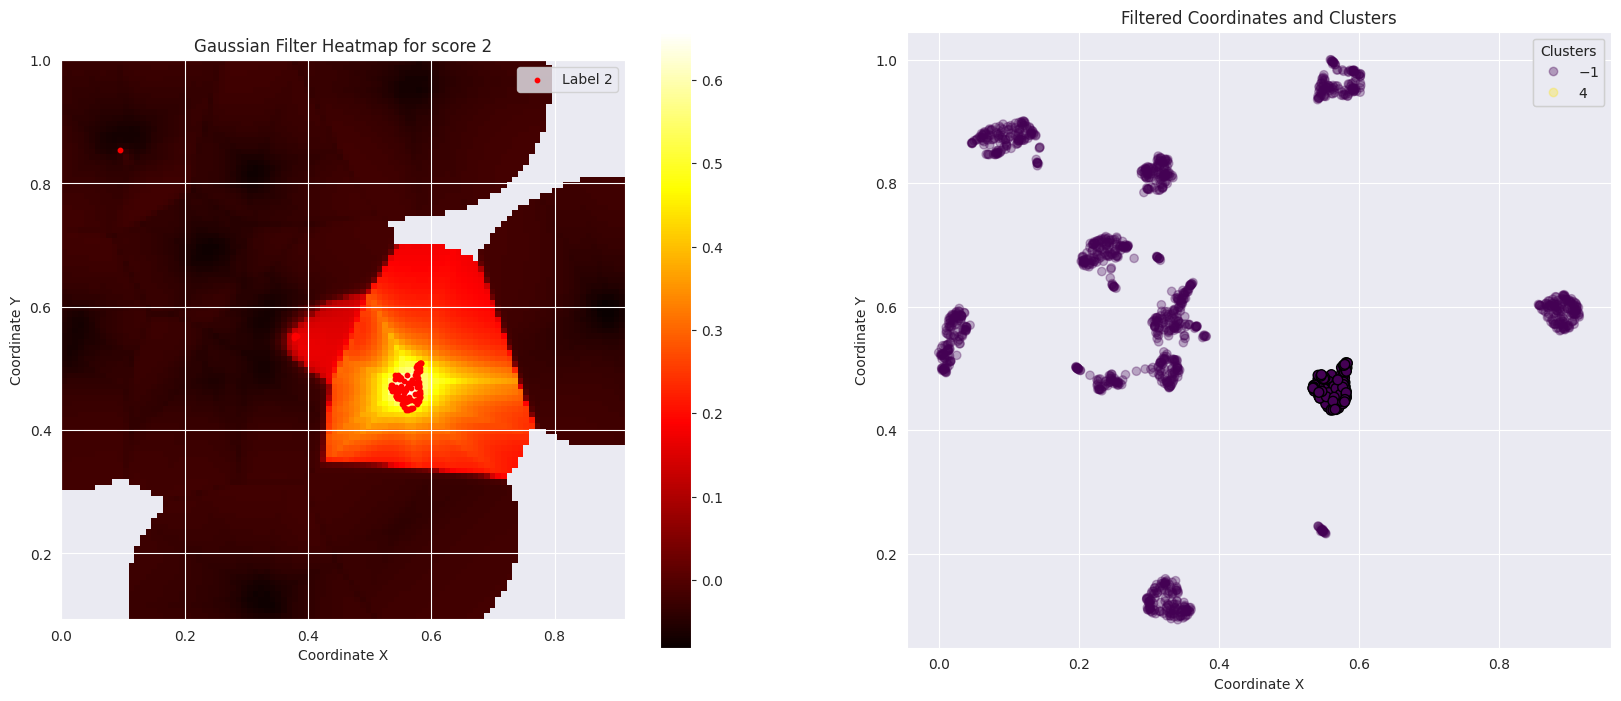

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


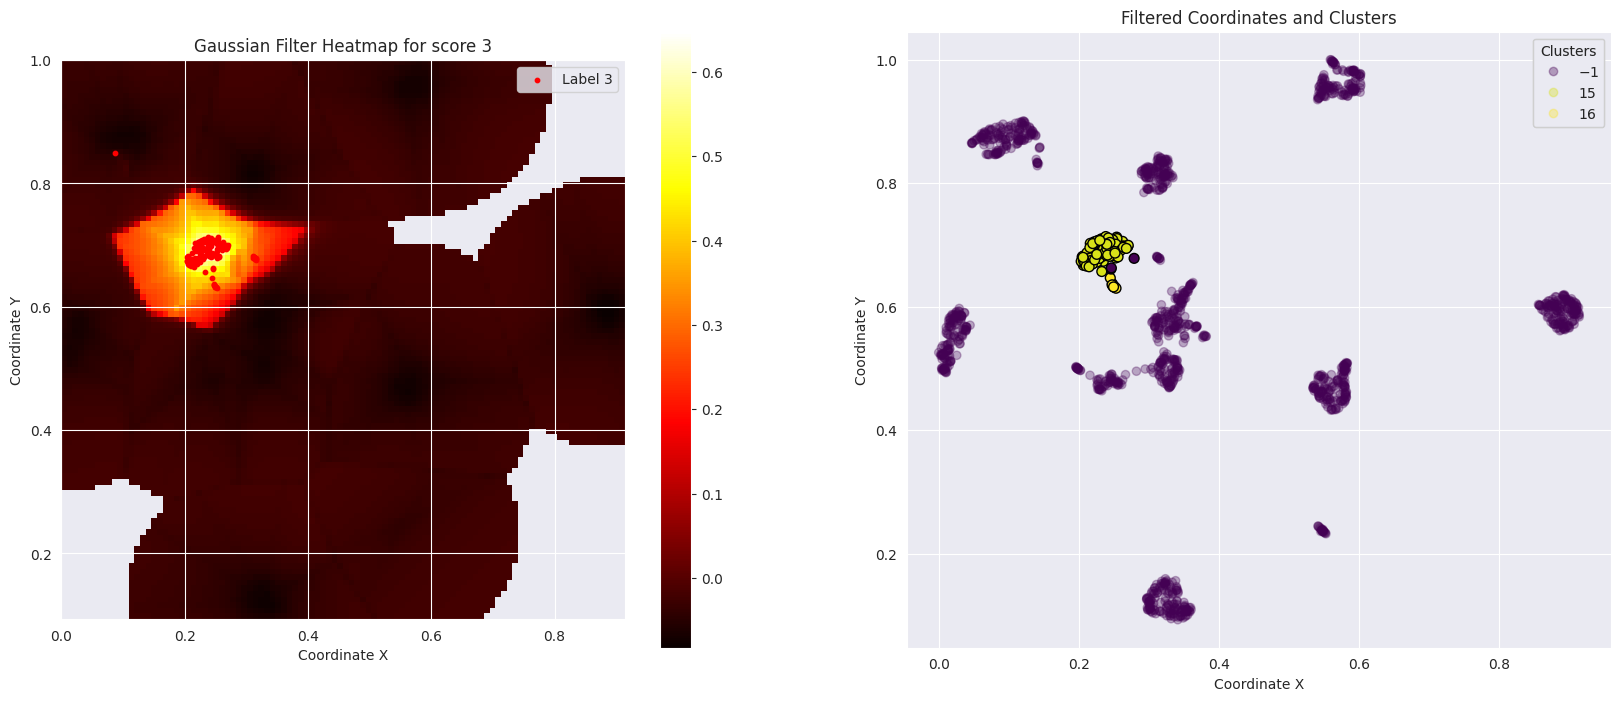

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


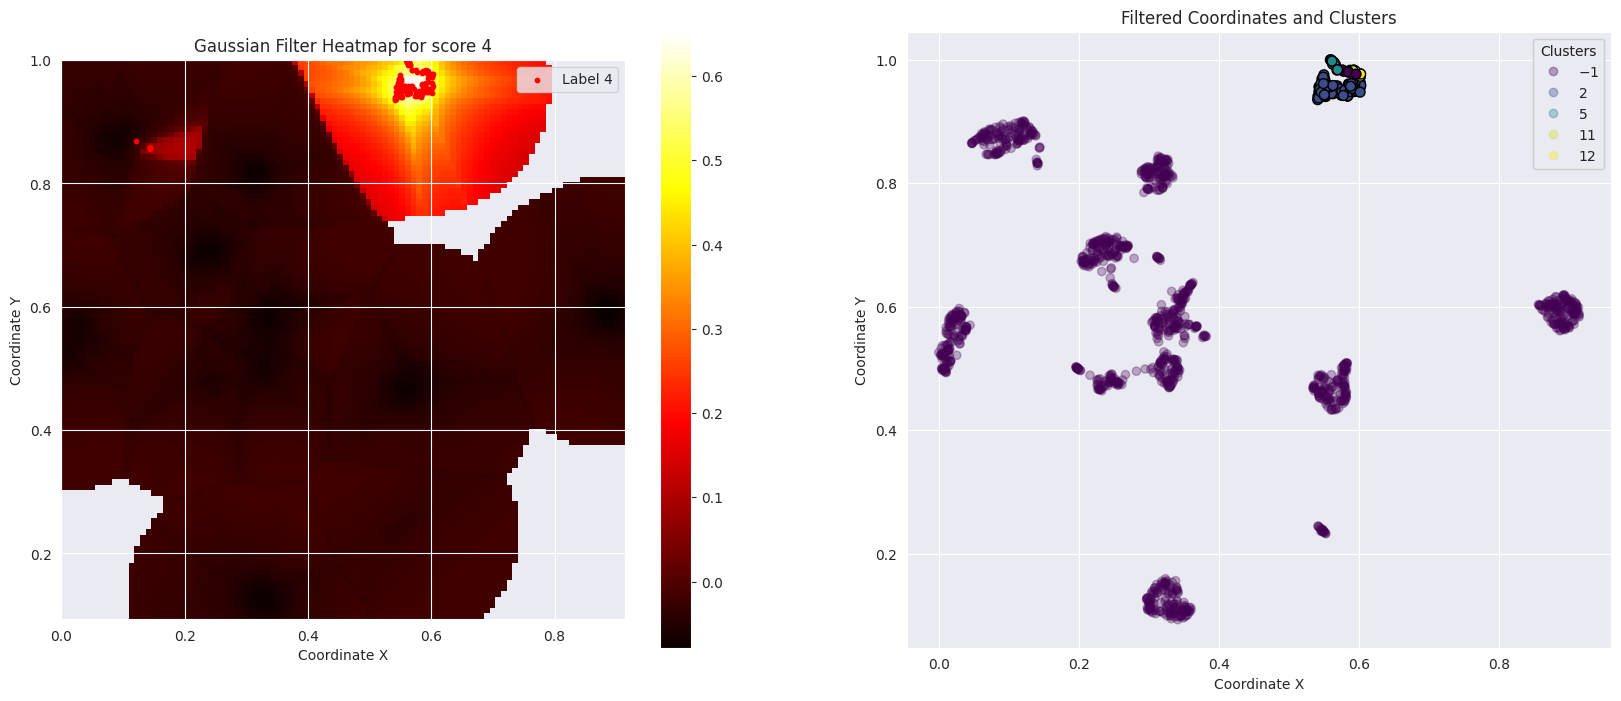

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


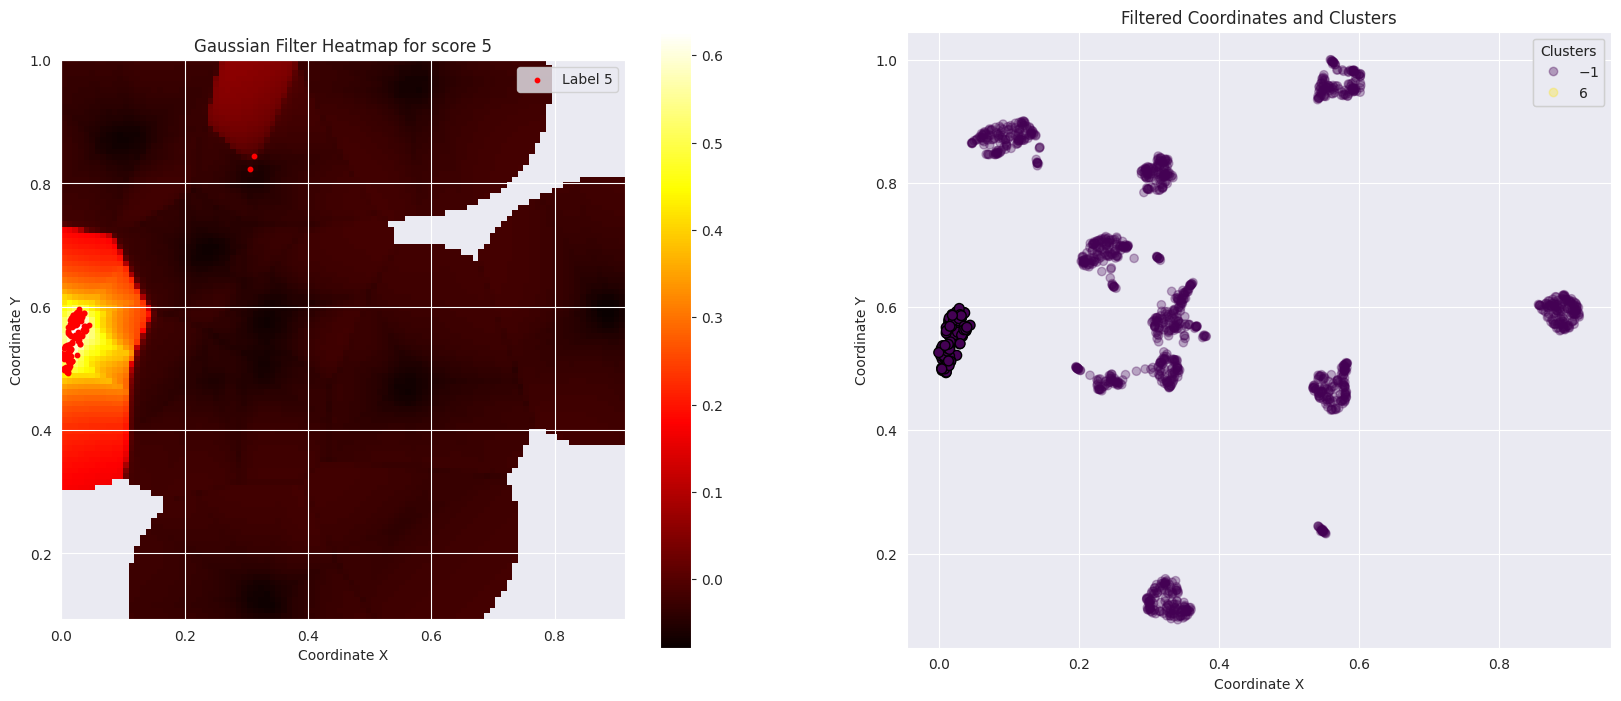

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


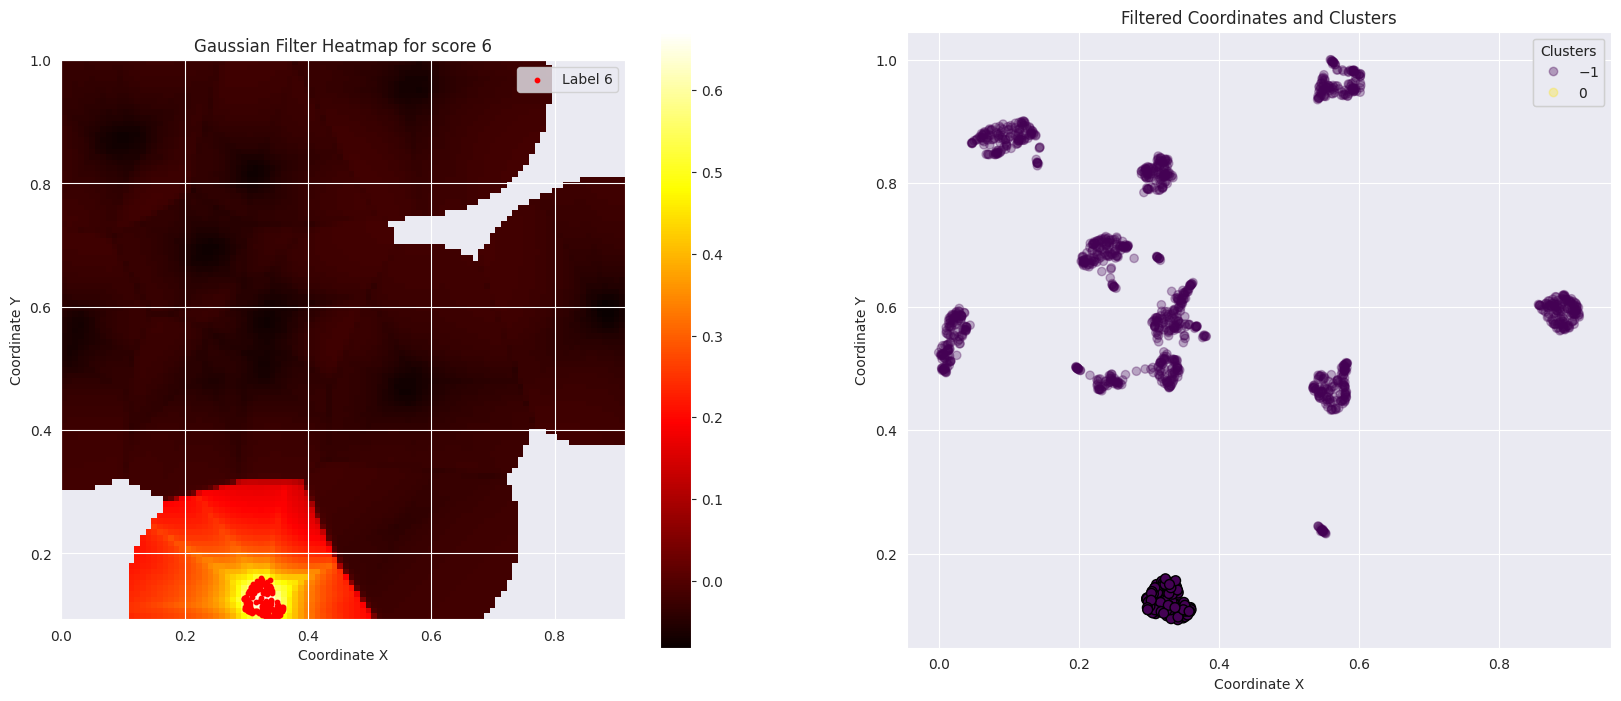

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


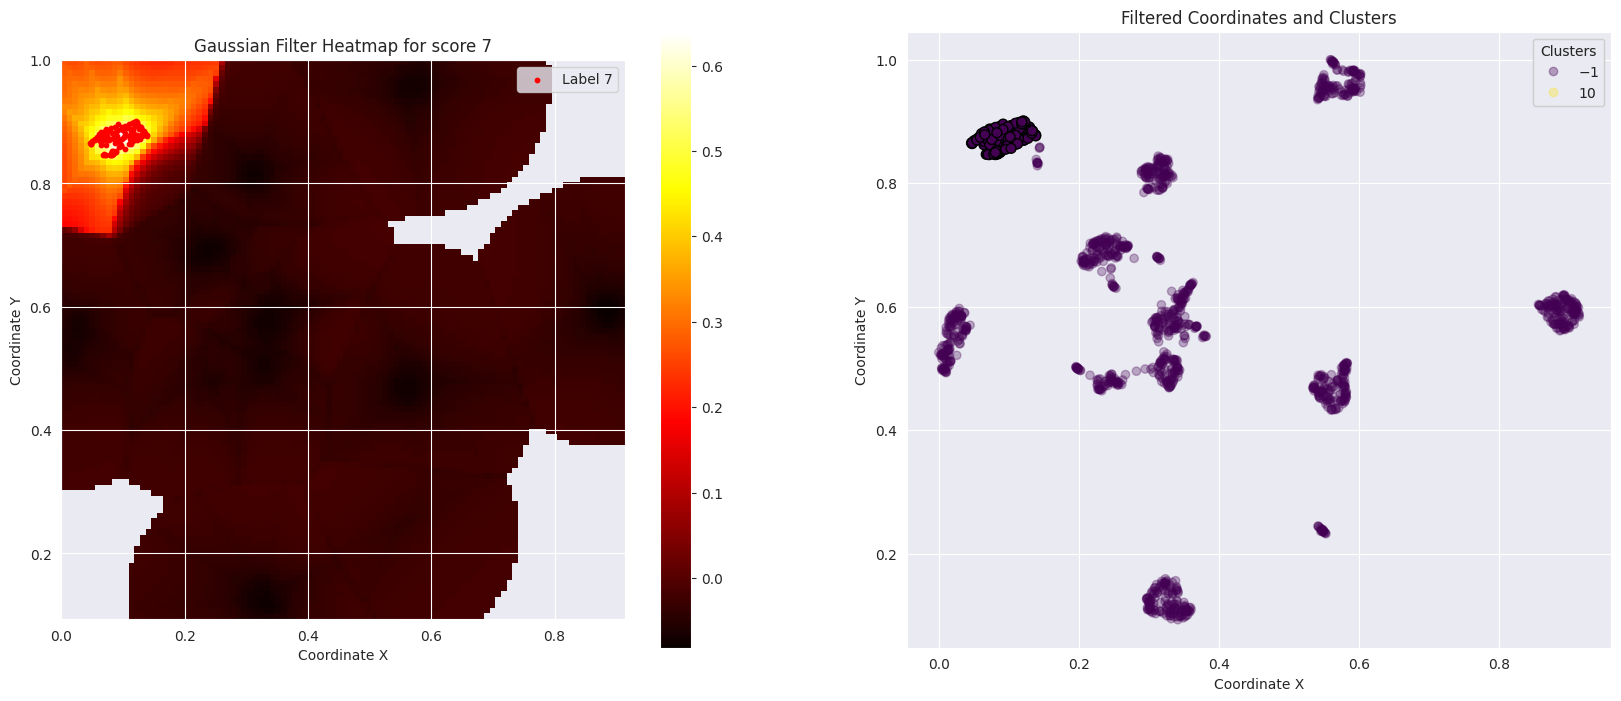

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


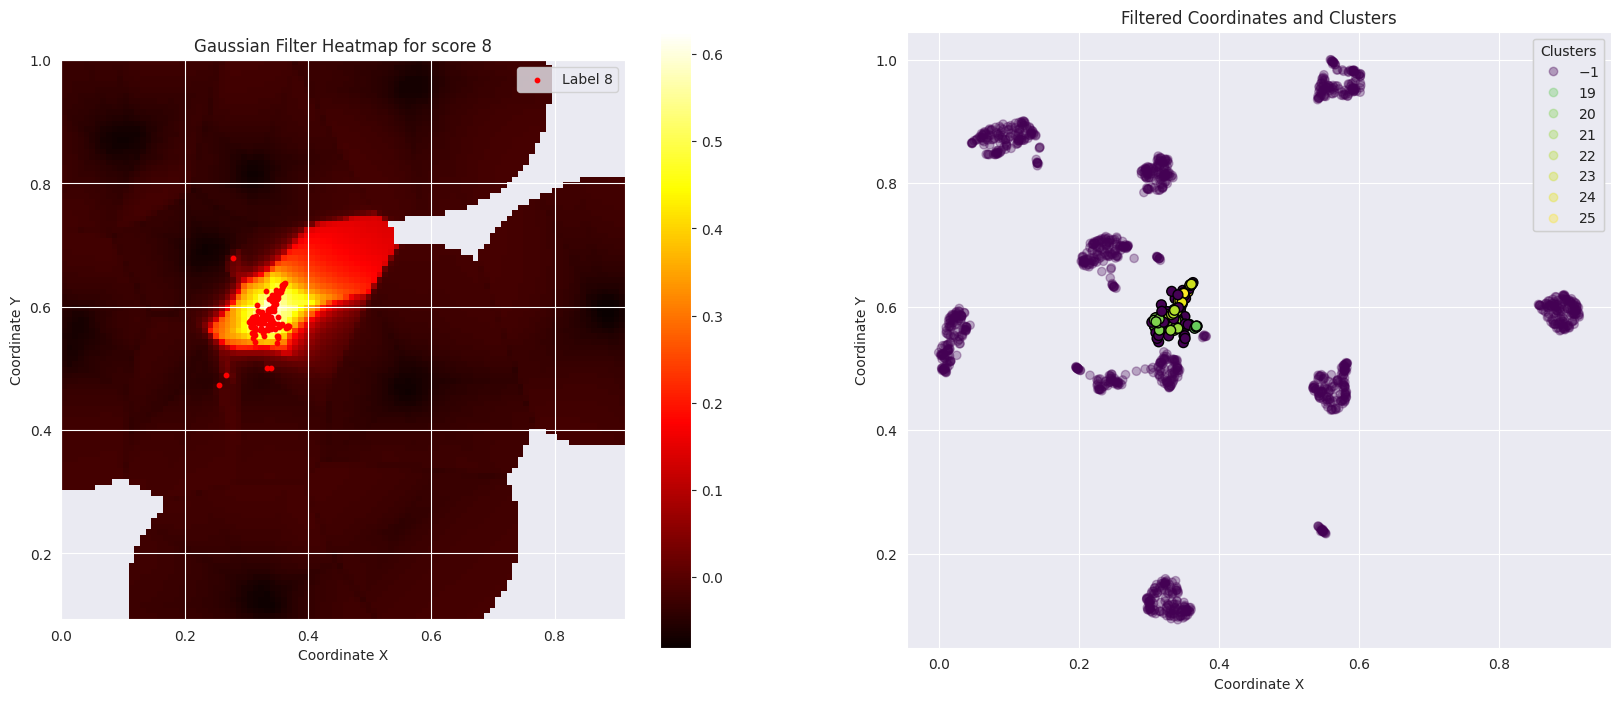

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


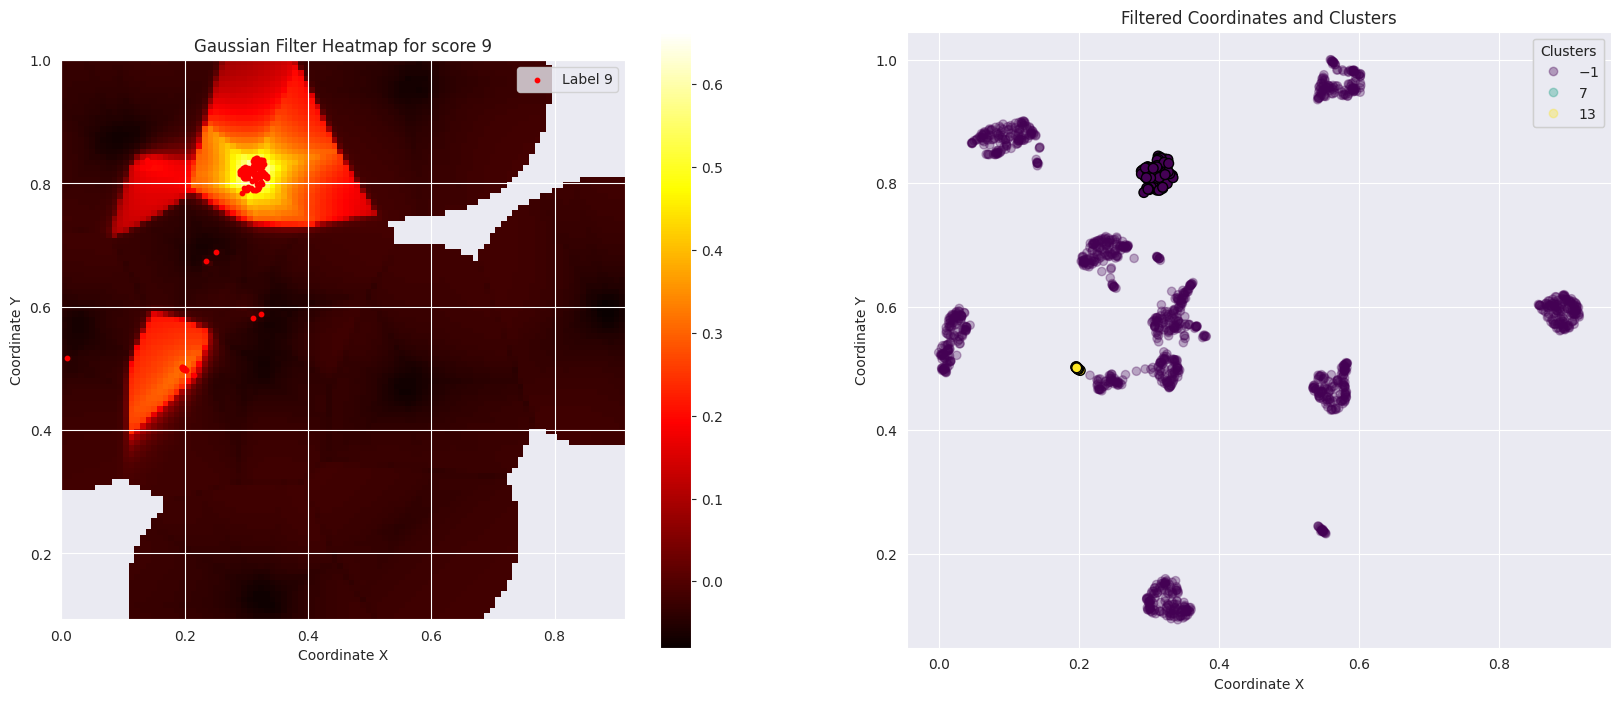

In [23]:
# Trying to replace the descretization
import numpy as np
import hdbscan
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pointbiserialr
from tools.stats_utils import compute_distance_vector, compute_gaussian_filter
from tools.emuse_utils import rescale_embedding

# update import for stats_utils
import importlib

import tools.stats_utils
importlib.reload(tools.stats_utils)


# rescale embedding between 0 and 1
embeddings = rescale_embedding(embeddings)

# embeddings contains the coordinates of the training embeddings coordinates
 
# now we need to create the scores vectors
labels = np.unique(train_labels)
print(f'Length train labels: {len(train_labels)}')
labels = np.sort(labels)
print(labels)

scores_vectors_dict = {}

for score_tag in labels:
    train_labels_bin = np.where(train_labels == score_tag, 1, 0)
    scores_vectors_dict[score_tag] = train_labels_bin
    
# Define the grid size
grid_size = 100

# Function to calculate point-biserial correlation for each point in the grid
def calculate_pointbiserial_grid(embeddings, train_labels_bin, grid_size, sigma=0.5):
    min_coords = embeddings.min(axis=0)
    max_coords = embeddings.max(axis=0)
    
    grid_x = np.linspace(min_coords[0], max_coords[0], grid_size)
    grid_y = np.linspace(min_coords[1], max_coords[1], grid_size)
    
    correlation_matrix = np.zeros((grid_size, grid_size))
    
    if isinstance(sigma, (list, np.ndarray)):  # Multi-scale approach
        for s in sigma:
            temp_correlation_matrix = np.zeros((grid_size, grid_size))
            for i, x in enumerate(grid_x):
                for j, y in enumerate(grid_y):
                    coord = np.array([[x, y]])
                    dist_vector = compute_gaussian_filter(embeddings, coord, sigma=s)
                    correlation, _ = pointbiserialr(dist_vector, train_labels_bin)
                    temp_correlation_matrix[i, j] = correlation
            correlation_matrix += temp_correlation_matrix
        correlation_matrix /= len(sigma)
    else:  # Single sigma approach
        for i, x in enumerate(grid_x):
            for j, y in enumerate(grid_y):
                coord = np.array([[x, y]])
                dist_vector = compute_gaussian_filter(embeddings, coord, sigma=sigma)
                correlation, _ = pointbiserialr(dist_vector, train_labels_bin)
                correlation_matrix[i, j] = correlation
    
    return correlation_matrix, grid_x, grid_y


def calculate_pointbiserial(embeddings, train_labels_bin, sigma=0.5):
    """
    Calculate point-biserial correlation for each point in the embeddings with the binary label vector.

    Parameters:
    embeddings (np.array): Array of shape (n_samples, n_features) containing the coordinates.
    train_labels_bin (np.array): Binary labels array of shape (n_samples,).
    sigma (float or list): Standard deviation(s) for the Gaussian filter.

    Returns:
    correlations (np.array): Array of correlations for each embedding.
    """
    correlations = np.zeros(embeddings.shape[0])
    
    if isinstance(sigma, (list, np.ndarray)):  # Multi-scale approach
        for s in sigma:
            temp_correlations = np.zeros(embeddings.shape[0])
            for idx, embedding in enumerate(embeddings):
                dist_vector = compute_gaussian_filter(embeddings, embedding, sigma=s)
                correlation, _ = pointbiserialr(dist_vector, train_labels_bin)
                temp_correlations[idx] = correlation
            correlations += temp_correlations
        correlations /= len(sigma)
    else:  # Single sigma approach
        for idx, embedding in enumerate(embeddings):
            dist_vector = compute_gaussian_filter(embeddings, embedding, sigma)
            correlation, _ = pointbiserialr(dist_vector, train_labels_bin)
            correlations[idx] = correlation
    
    return correlations


def filter_and_cluster_coordinates(coordinates, correlations, correlation_threshold=0.3, min_cluster_size=5):
    """
    Filter coordinates based on point-biserial correlation values and cluster the filtered coordinates.

    Parameters:
    coordinates (np.array): Array of shape (n_samples, 2) containing the coordinates.
    correlations (np.array): Array of shape (n_samples,) containing the correlation values for each coordinate.
    correlation_threshold (float): Correlation threshold for filtering points.
    min_cluster_size (int): Minimum cluster size for HDBSCAN.

    Returns:
    filtered_coordinates (np.array): Filtered coordinates.
    cluster_labels (np.array): Cluster labels for the filtered coordinates.
    """
    # Filter coordinates based on correlation threshold
    filtered_indices = np.where(correlations > correlation_threshold)[0]
    filtered_coordinates = coordinates[filtered_indices]
    
    # Perform HDBSCAN clustering on filtered coordinates
    if filtered_coordinates.shape[0] > 0:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
        cluster_labels = clusterer.fit_predict(filtered_coordinates)
    else:
        cluster_labels = np.array([])

    return filtered_coordinates, cluster_labels


# Create heatmap for each score
# for score_tag in labels:
#     train_labels_bin = scores_vectors_dict[score_tag]
#     gaussian_matrix, grid_x, grid_y = calculate_pointbiserial_grid(embeddings, train_labels_bin, grid_size)
#     
#     fig, axs = plt.subplots(1, 2, figsize=(20, 8))
# 
#     # Heatmap subplot
#     cax = axs[0].imshow(gaussian_matrix.T, cmap='hot', interpolation='nearest', origin='lower',
#                         extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()])
#     axs[0].set_title(f'Gaussian Filter Heatmap for score {score_tag}')
#     axs[0].set_xlabel('Coordinate X')
#     axs[0].set_ylabel('Coordinate Y')
#     fig.colorbar(cax, ax=axs[0])
# 
#     # Highlight embeddings corresponding to the current score_tag in red
#     matching_indices = np.where(train_labels == score_tag)[0]
#     matching_embeddings = embeddings[matching_indices]
#     axs[0].scatter(matching_embeddings[:, 0], matching_embeddings[:, 1], color='red', s=10, label=f'Label {score_tag}')
#     axs[0].legend()
# 
#     # Calculate correlations for each point in embeddings
#     correlations = calculate_pointbiserial(embeddings, train_labels_bin, sigma=0.5)
#     
#     # Filter and cluster coordinates
#     filtered_coords, clusters = filter_and_cluster_coordinates(embeddings, correlations, correlation_threshold=0.3, min_cluster_size=5)
# 
#     # Plot filtered coordinates and clusters
#     scatter = axs[1].scatter(filtered_coords[:, 0], filtered_coords[:, 1], c=clusters, cmap='viridis')
#     axs[1].set_title('Filtered Coordinates and Clusters')
#     axs[1].set_xlabel('Coordinate X')
#     axs[1].set_ylabel('Coordinate Y')
#     legend1 = axs[1].legend(*scatter.legend_elements(), title="Clusters")
#     axs[1].add_artist(legend1)
# 
#     plt.show()

# Fit HDBSCAN on the full dataset
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, prediction_data=True)
clusterer.fit(embeddings)

sigma_percentage = np.array([0.005, 0.01, 0.02, 0.03])
# TODO we could parameter search here because the smoothing changes everything. We need a metric for the search. Empirically I would say we need a balance between a high correlation peak and multiple clusters
# TODO we could use the HDBSCAN clustering to see if the correlation spread matches the clusters
"""
Entropy-Based Method

Entropy can be used to measure the uniformity of the correlation heatmap. A high entropy value indicates a more uniform distribution (e.g., one big peak), while a low entropy value indicates a more varied distribution (e.g., multiple peaks).

    Procedure:
        Calculate the entropy of the heatmap for different smoothing values.
        Select a smoothing value that results in a moderate entropy, indicating a balance between uniformity and variability in the heatmap.
"""
smoothing_sigma = sigma_percentage / np.max(embeddings) 

# Plot the clustering of the whole space with a better colormap
fig, ax = plt.subplots(figsize=(10, 8))
unique_labels = np.unique(clusterer.labels_)
colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]

# Plot the data points
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Black color for noise

    class_member_mask = (clusterer.labels_ == k)
    xy = embeddings[class_member_mask]
    ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
            markeredgecolor='k', markersize=4, alpha=0.75)

# Customize the legend
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=tuple([0, 0, 0, 1]), markeredgecolor='k', markersize=10, label='Noise')] + [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10, label=f'Cluster {k}')
    for k, col in zip(unique_labels, colors) if k != -1
]

# Place the legend outside the plot
ax.legend(handles=legend_elements, title='Clusters', loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title('Clustering of the Whole Space')
ax.set_xlabel('Coordinate X')
ax.set_ylabel('Coordinate Y')

plt.show()

for score_tag in labels:
    train_labels_bin = scores_vectors_dict[score_tag]
    # THIS IS VERY IMPORTANT TO DIVIDE THE SMOOTHING BY THE SCALING FACTOR!!!!
    gaussian_matrix, grid_x, grid_y = calculate_pointbiserial_grid(embeddings, train_labels_bin, grid_size, smoothing_sigma)
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))

    # Heatmap subplot
    cax = axs[0].imshow(gaussian_matrix.T, cmap='hot', interpolation='nearest', origin='lower',
                        extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()])
    axs[0].set_title(f'Gaussian Filter Heatmap for score {score_tag}')
    axs[0].set_xlabel('Coordinate X')
    axs[0].set_ylabel('Coordinate Y')
    fig.colorbar(cax, ax=axs[0])

    # Highlight embeddings corresponding to the current score_tag in red
    matching_indices = np.where(train_labels == score_tag)[0]
    matching_embeddings = embeddings[matching_indices]
    axs[0].scatter(matching_embeddings[:, 0], matching_embeddings[:, 1], color='red', s=10, label=f'Label {score_tag}')
    axs[0].legend()

    # Calculate correlations for each point in embeddings
    correlations = calculate_pointbiserial(embeddings, train_labels_bin, sigma=smoothing_sigma)
    
    # Filter embeddings based on correlation threshold
    correlation_threshold = 0.3
    filtered_indices = np.where(correlations > correlation_threshold)[0]
    filtered_embeddings = embeddings[filtered_indices]
    
    # Predict cluster labels for filtered embeddings
    if filtered_embeddings.shape[0] > 0:
        cluster_labels, strengths = hdbscan.approximate_predict(clusterer, filtered_embeddings)
    else:
        cluster_labels = np.array([])

    # Plot the entire space with filtered points in color
    unfiltered_labels = np.full(embeddings.shape[0], -1)
    unfiltered_labels[filtered_indices] = cluster_labels
    
    scatter = axs[1].scatter(embeddings[:, 0], embeddings[:, 1], c=unfiltered_labels, cmap='viridis', alpha=0.3)
    axs[1].scatter(filtered_embeddings[:, 0], filtered_embeddings[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50)
    axs[1].set_title('Filtered Coordinates and Clusters')
    axs[1].set_xlabel('Coordinate X')
    axs[1].set_ylabel('Coordinate Y')
    legend1 = axs[1].legend(*scatter.legend_elements(), title="Clusters")
    axs[1].add_artist(legend1)

    plt.show()
    

In [4]:
from PIL import Image
import numpy as np

def save_grayscale_image(data, filename):
    """
    Save a 2D numpy array as a grayscale image using PIL.
    """
    # Replace NaN values with the minimum value of the array
    data = np.nan_to_num(data, nan=np.nanmin(data))

    # Normalize the data to be between 0 and 255
    data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)

    # Create the image from the normalized data
    image = Image.fromarray(data_normalized, mode='L')

    # Save the image
    image.save(filename)

Length train labels: 1437
[0 1 2 3 4 5 6 7 8 9]
Heatmap for : 0
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 0
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 0
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 0 created
Len scores: 1437
Unique values in heatmap: [0 1]


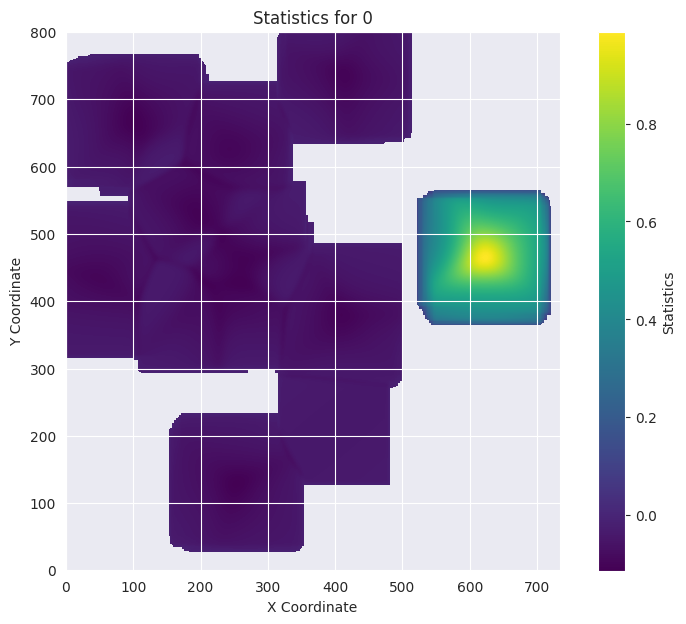

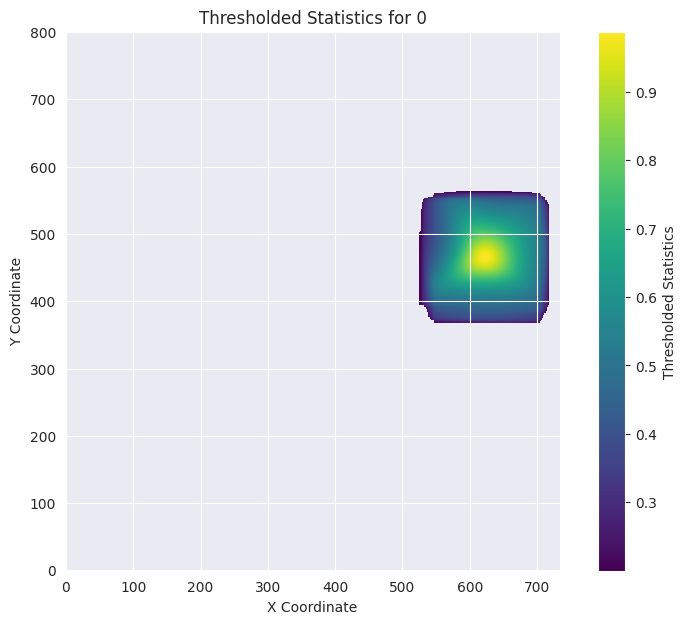

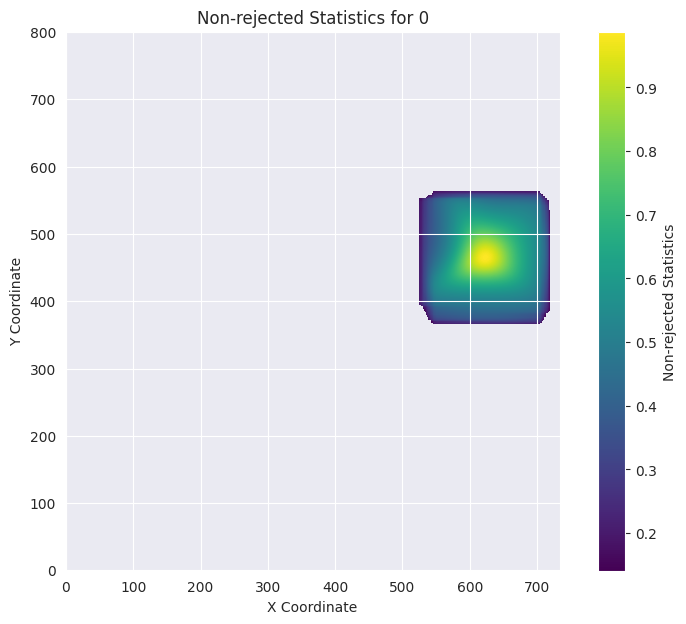

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 2583.77it/s]


Shape of the maps: (64,)
0 - Avg Training R^2: 1.0
0 - Avg Normalized Training MSE: 0.00%, Avg Normalized Training MAE: 0.00%, Avg MAE_max% Training: 0.00%
0 - Test R^2: 1.0
0 - Normalized Test MSE: 0.00%, Normalized Test MAE: 0.00%, Test MAE_max%: 0.00%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_0/0_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_0/0_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_0/0_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_0/0_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_0/0_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


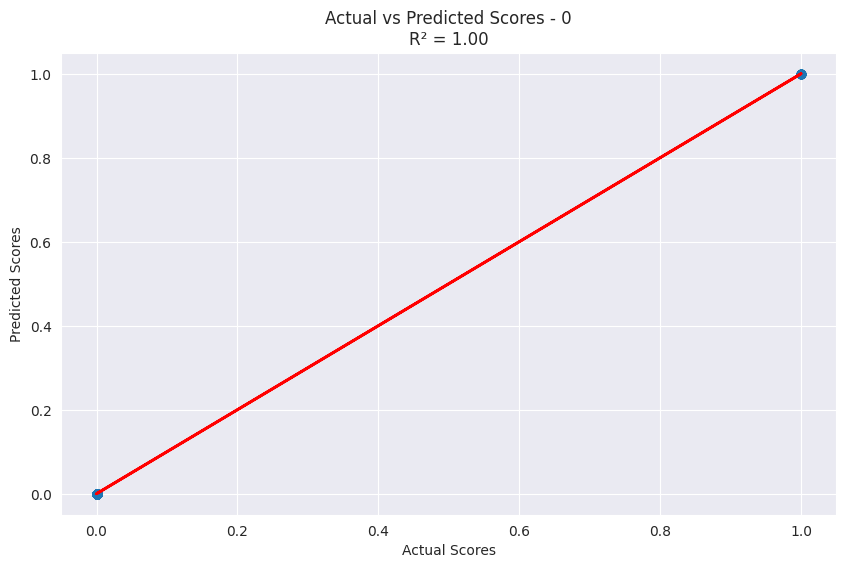

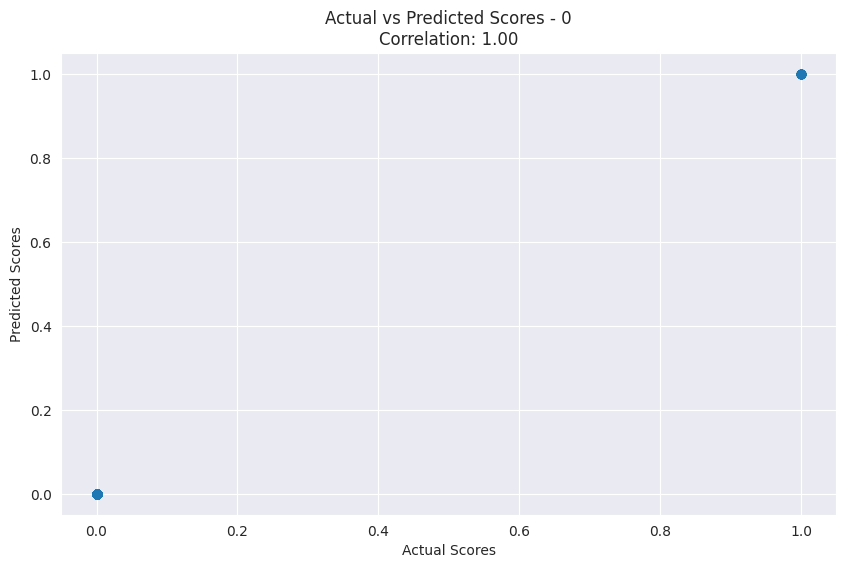

Heatmap for : 1
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 1
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 1
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 1 created
Len scores: 1437
Unique values in heatmap: [0 1]


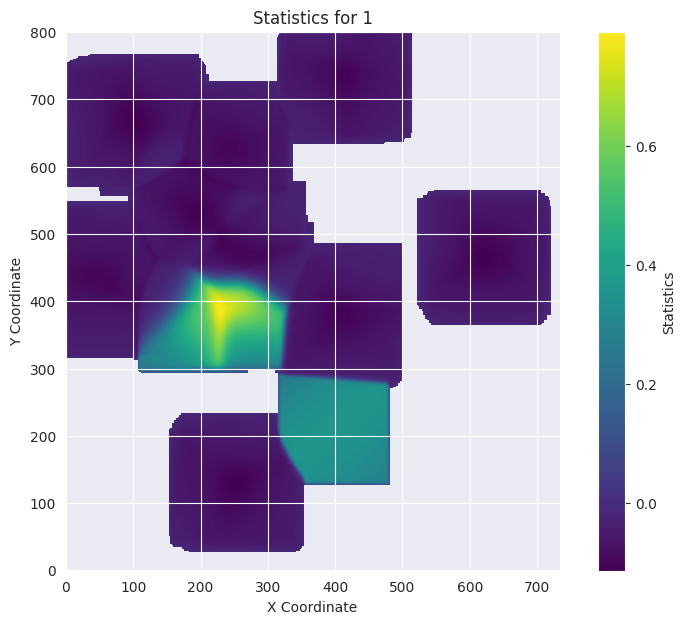

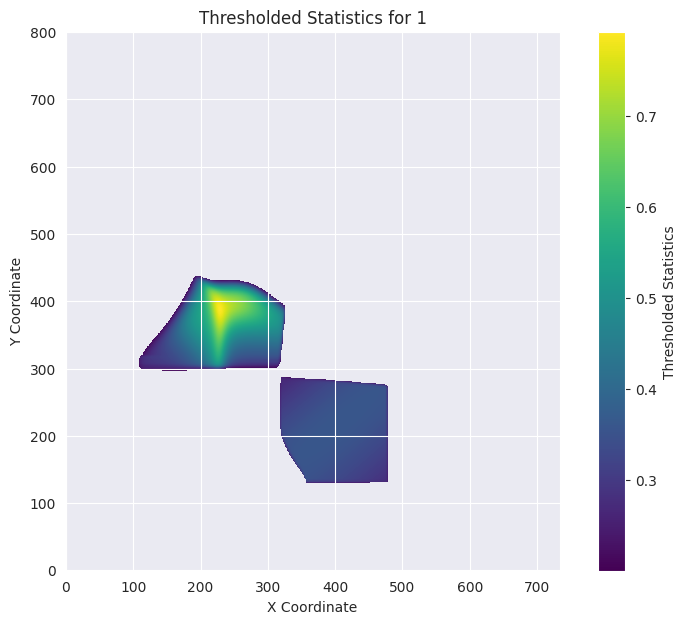

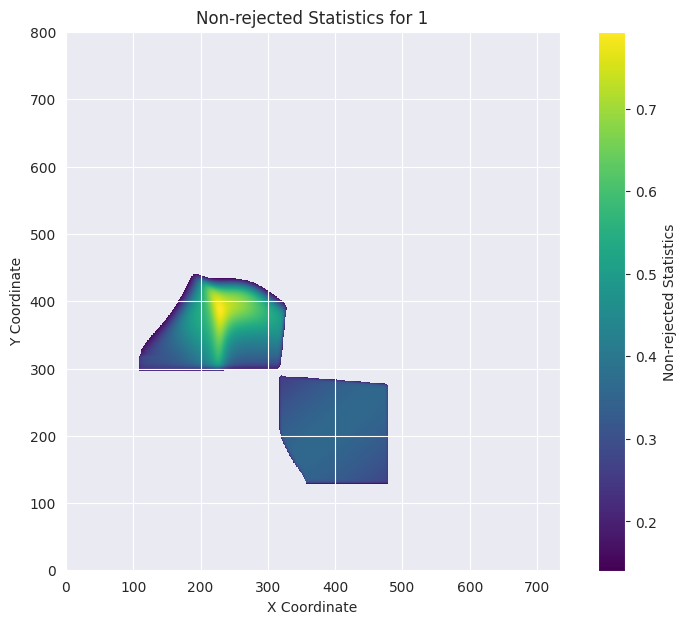

Found 2 clusters


100%|██████████| 64/64 [00:00<00:00, 2953.77it/s]

Shape of the maps: (64,)



100%|██████████| 64/64 [00:00<00:00, 3690.75it/s]


Shape of the maps: (64,)
1 - Avg Training R^2: 0.9915769790366475
1 - Avg Normalized Training MSE: 0.08%, Avg Normalized Training MAE: 0.33%, Avg MAE_max% Training: 0.33%
1 - Test R^2: 0.889518726333907
1 - Normalized Test MSE: 0.79%, Normalized Test MAE: 1.30%, Test MAE_max%: 1.30%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


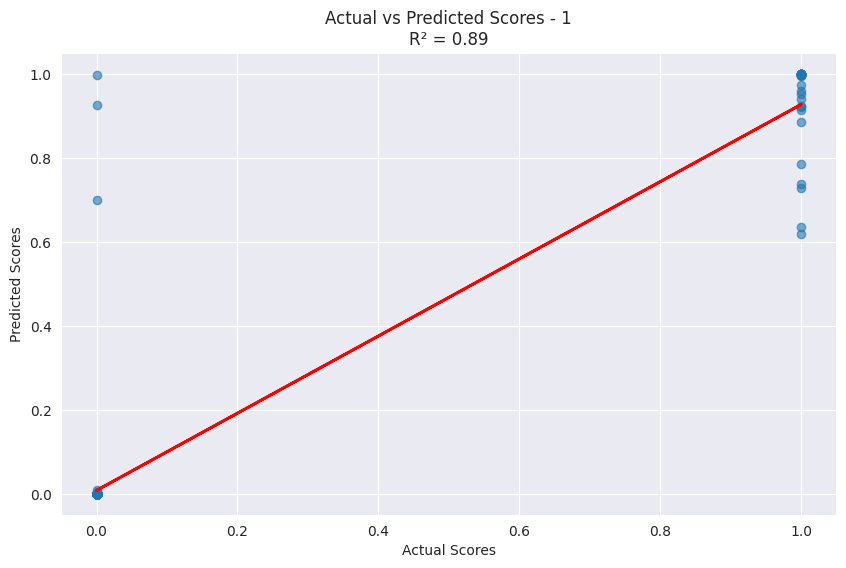

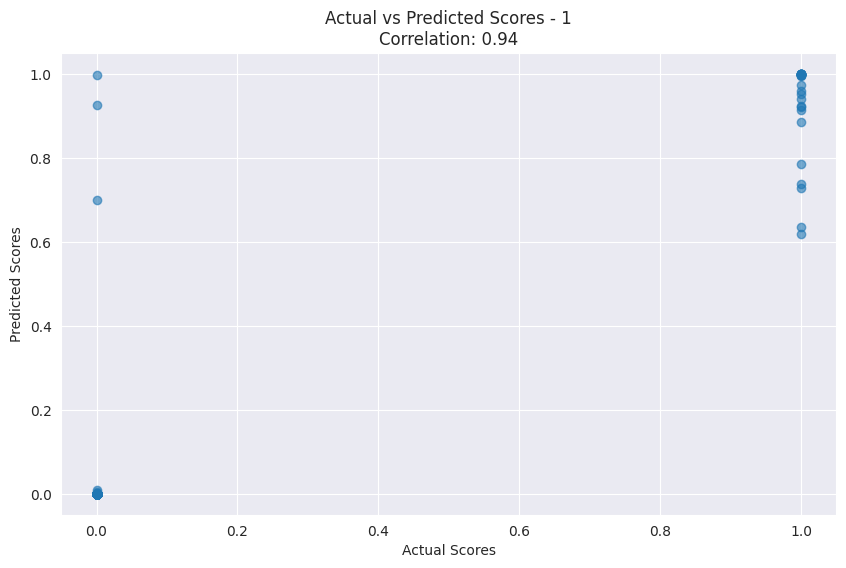

1 - Avg Training R^2: 0.9915769790366475
1 - Avg Normalized Training MSE: 0.08%, Avg Normalized Training MAE: 0.33%, Avg MAE_max% Training: 0.33%
1 - Test R^2: 0.889518726333907
1 - Normalized Test MSE: 0.79%, Normalized Test MAE: 1.30%, Test MAE_max%: 1.30%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_1/1_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


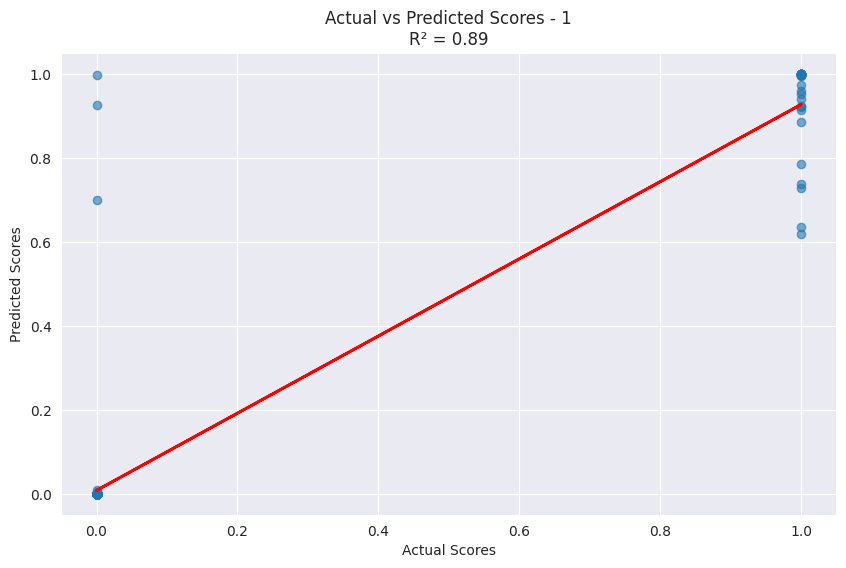

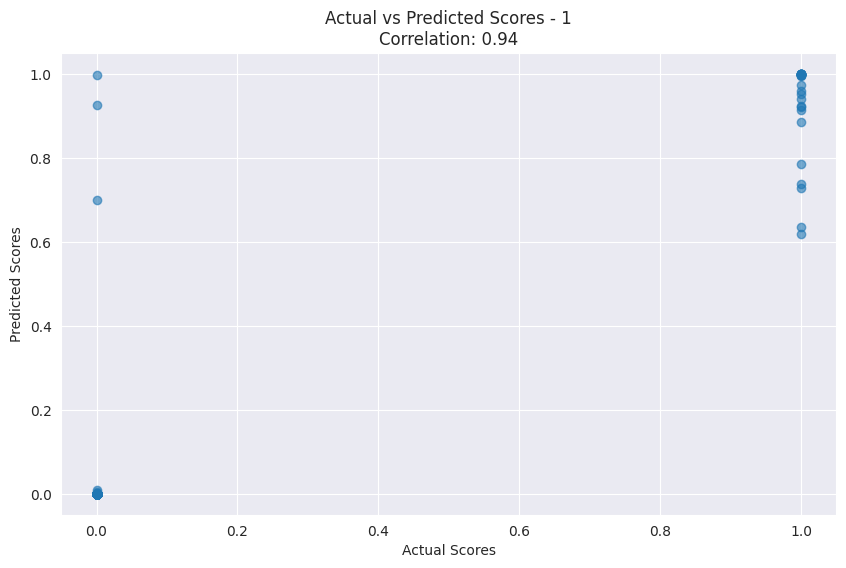

Heatmap for : 2
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 2
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 2
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 2 created
Len scores: 1437
Unique values in heatmap: [0 1]


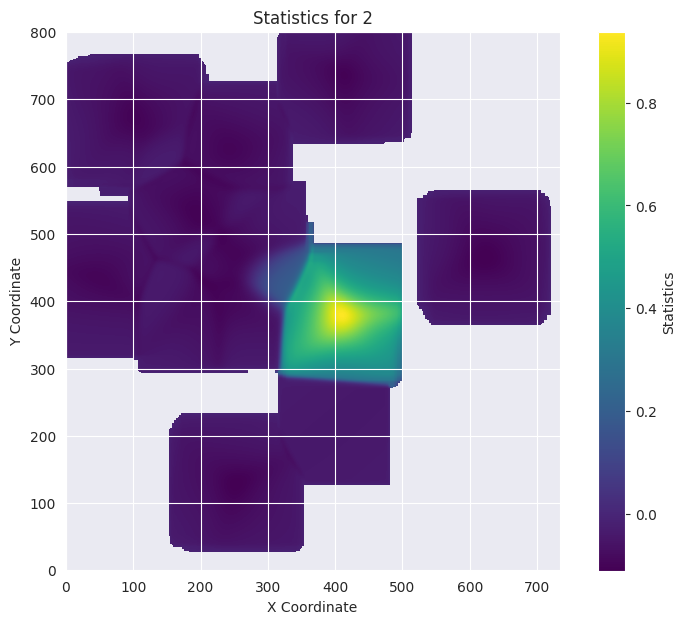

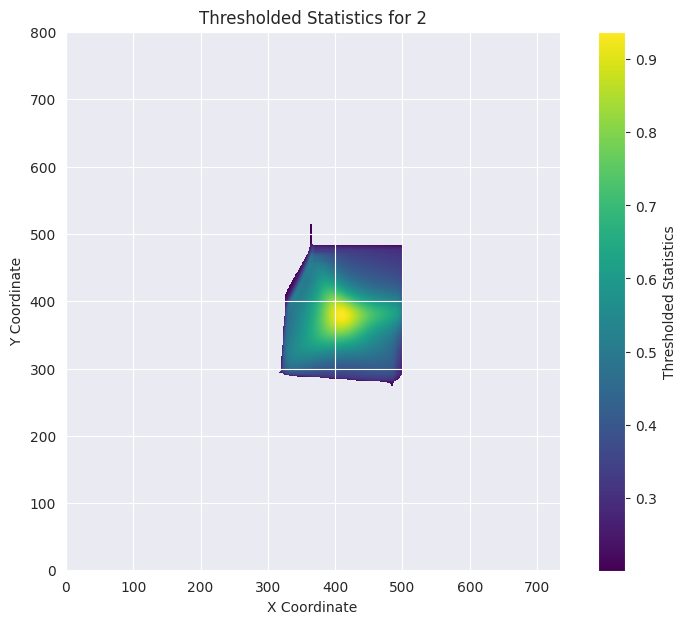

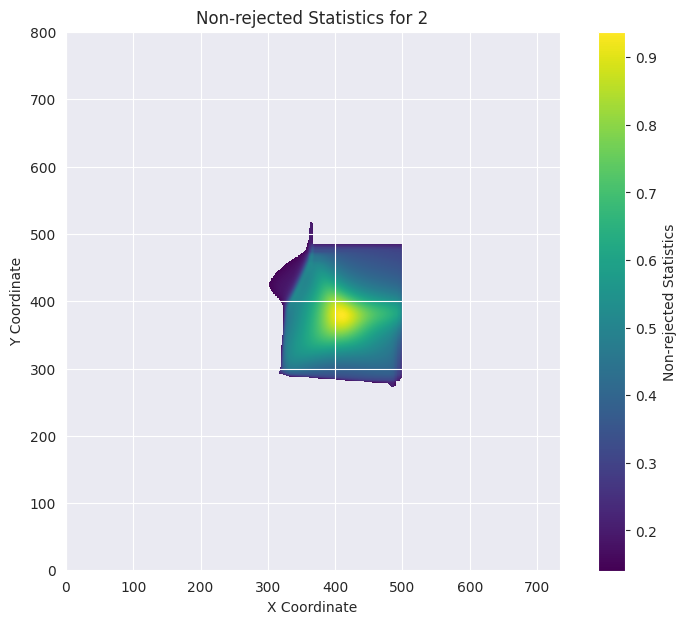

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 4048.68it/s]


Shape of the maps: (64,)
2 - Avg Training R^2: 0.9988890986991945
2 - Avg Normalized Training MSE: 0.01%, Avg Normalized Training MAE: 0.05%, Avg MAE_max% Training: 0.05%
2 - Test R^2: 0.9983993327773144
2 - Normalized Test MSE: 0.01%, Normalized Test MAE: 0.10%, Test MAE_max%: 0.10%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_2/2_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_2/2_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_2/2_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_2/2_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_2/2_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


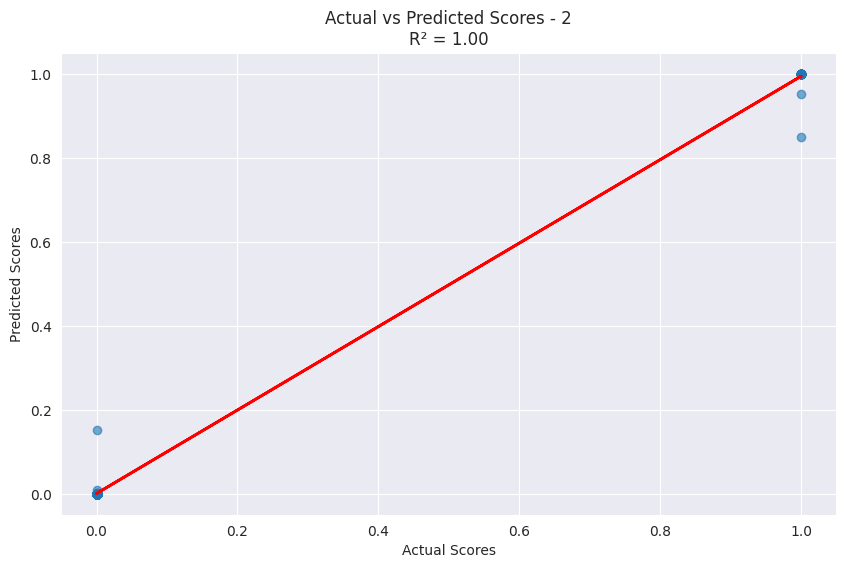

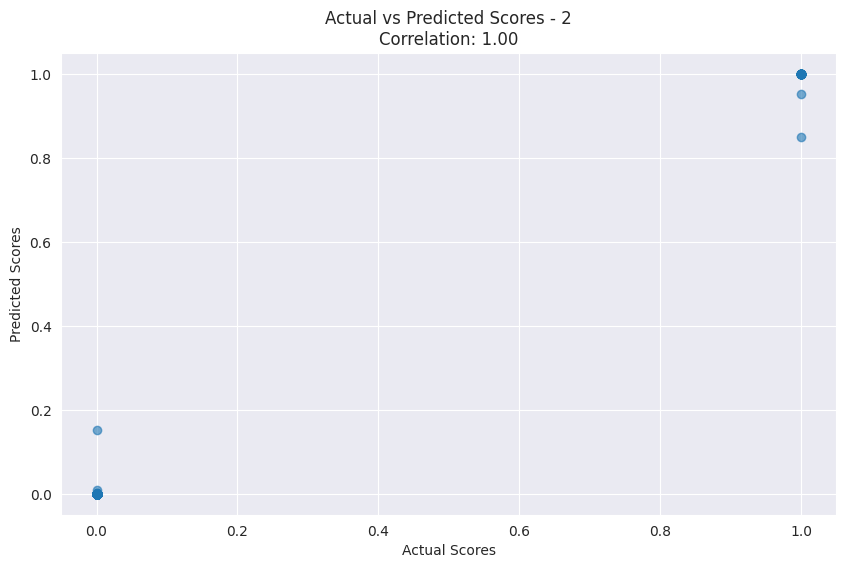

Heatmap for : 3
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 3
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 3
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 3 created
Len scores: 1437
Unique values in heatmap: [0 1]


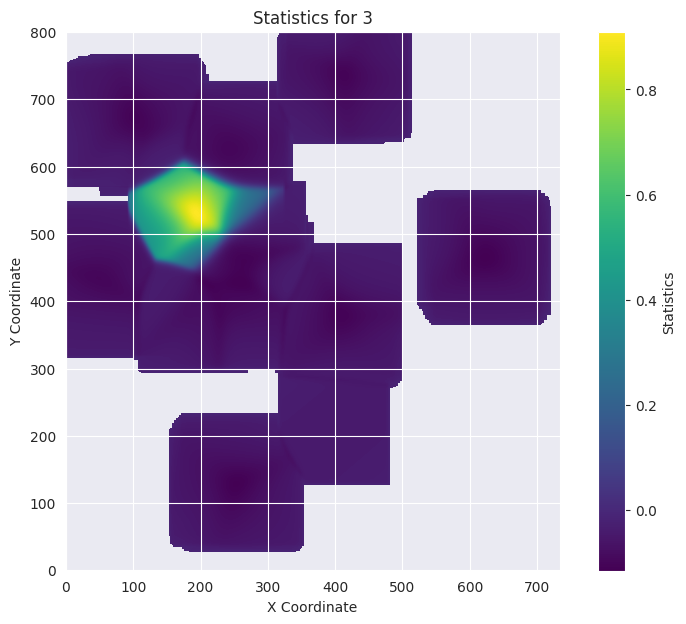

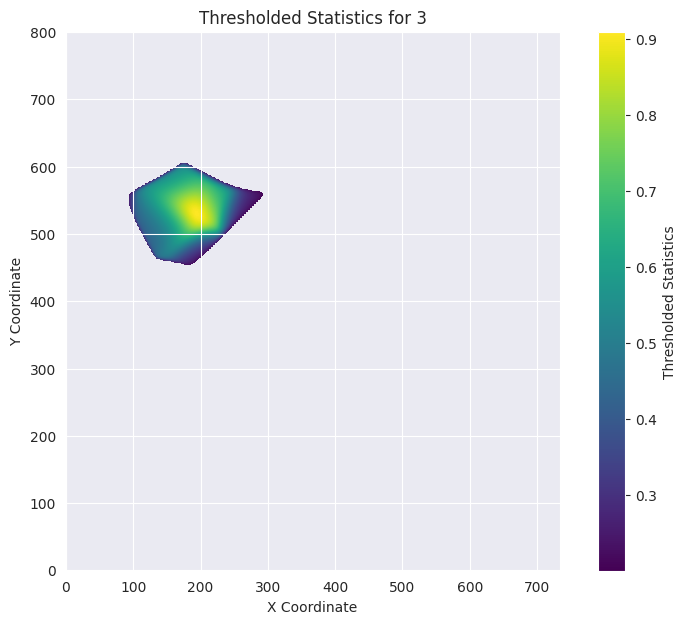

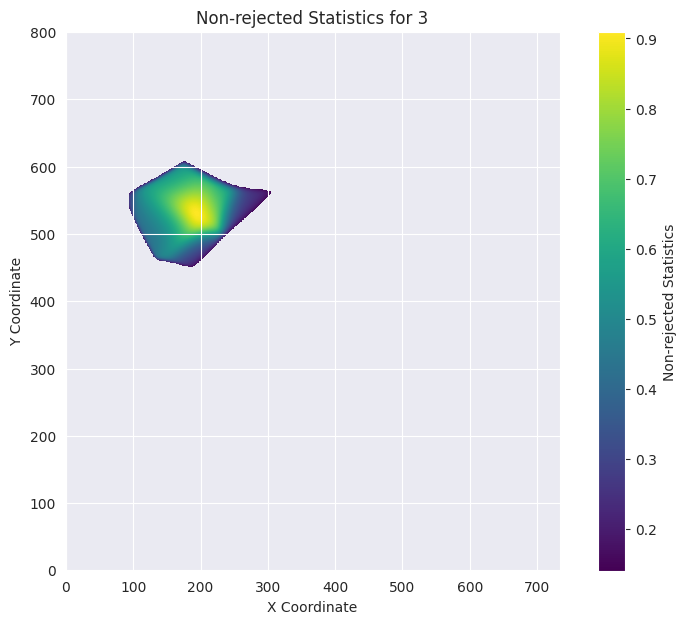

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 2908.20it/s]


Shape of the maps: (64,)
3 - Avg Training R^2: 0.993539129864276
3 - Avg Normalized Training MSE: 0.06%, Avg Normalized Training MAE: 0.31%, Avg MAE_max% Training: 0.31%
3 - Test R^2: 0.9809866474197041
3 - Normalized Test MSE: 0.16%, Normalized Test MAE: 0.68%, Test MAE_max%: 0.68%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_3/3_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_3/3_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_3/3_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_3/3_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_3/3_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


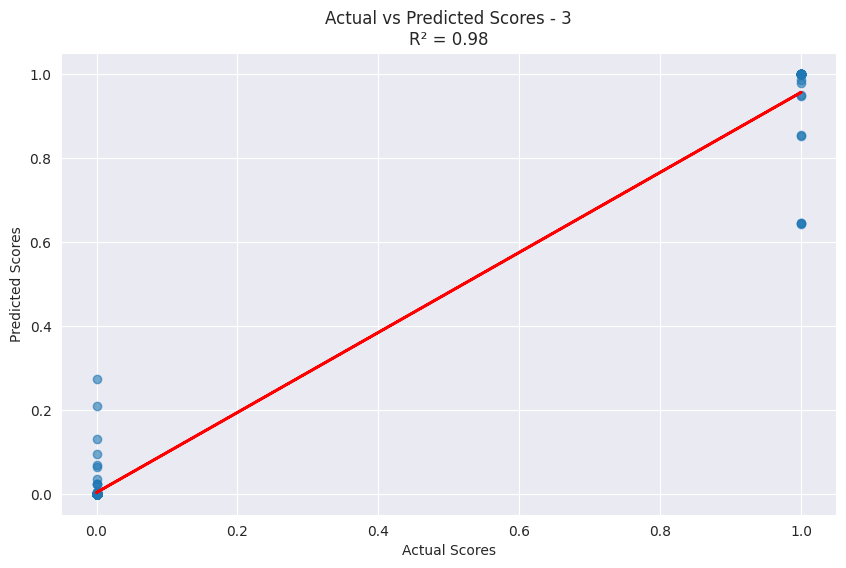

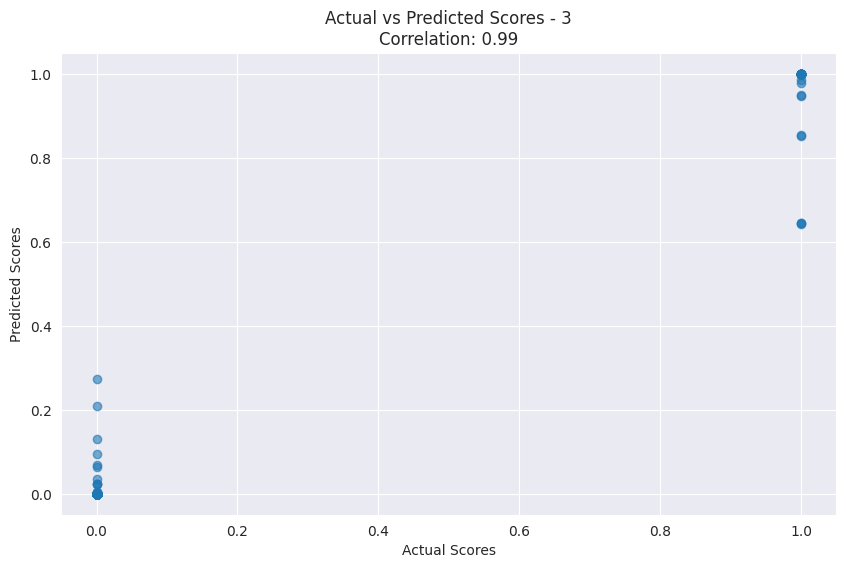

Heatmap for : 4
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 4
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 4
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 4 created
Len scores: 1437
Unique values in heatmap: [0 1]


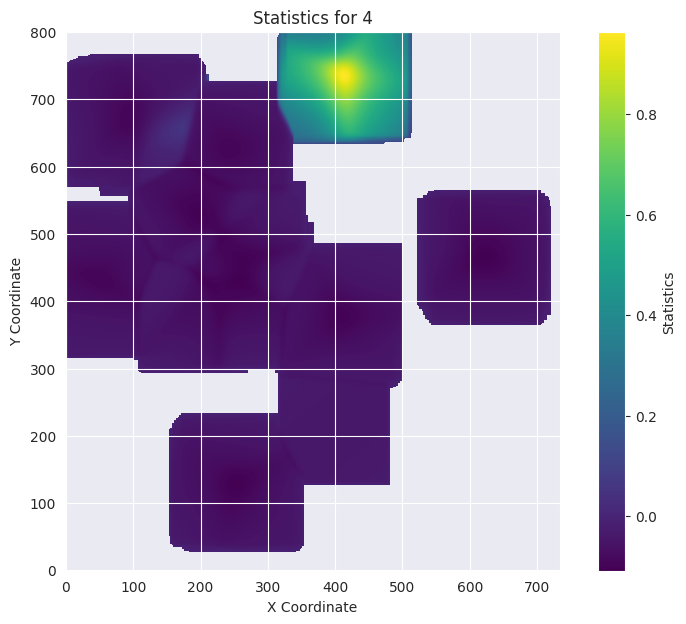

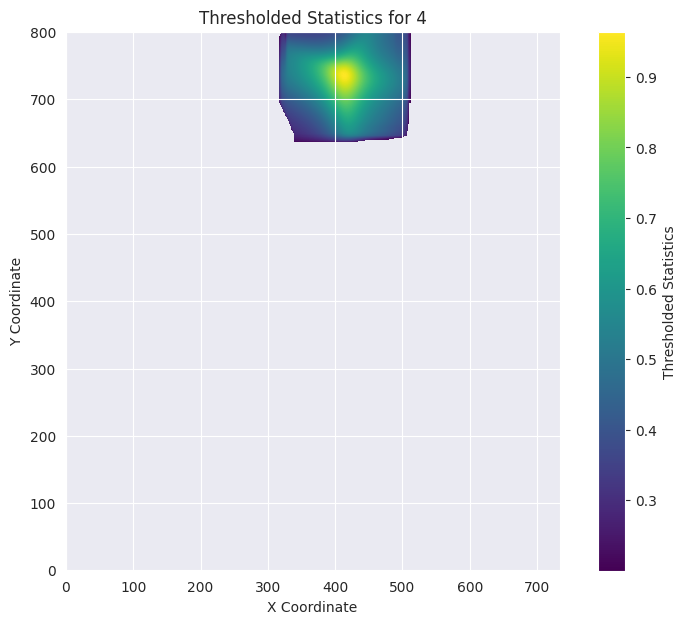

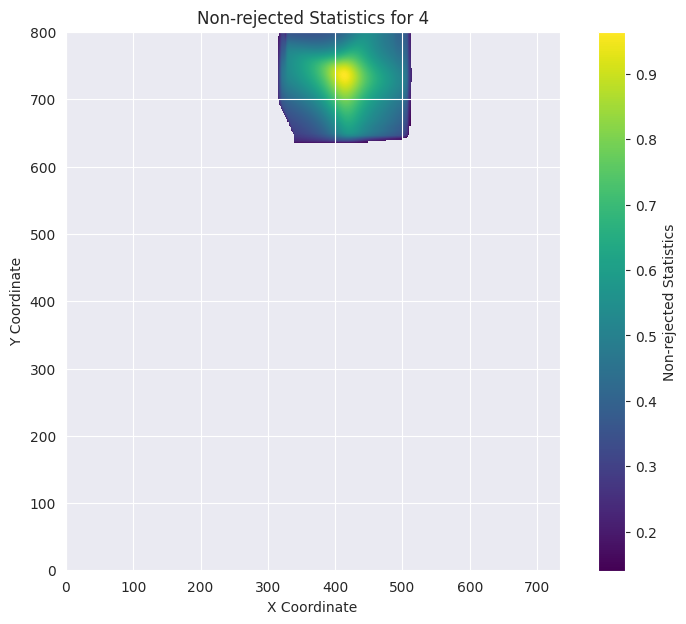

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 3814.25it/s]


Shape of the maps: (64,)
4 - Avg Training R^2: 0.997517309120856
4 - Avg Normalized Training MSE: 0.02%, Avg Normalized Training MAE: 0.10%, Avg MAE_max% Training: 0.10%
4 - Test R^2: 0.9861212074217668
4 - Normalized Test MSE: 0.15%, Normalized Test MAE: 0.34%, Test MAE_max%: 0.34%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_4/4_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_4/4_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_4/4_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_4/4_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_4/4_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


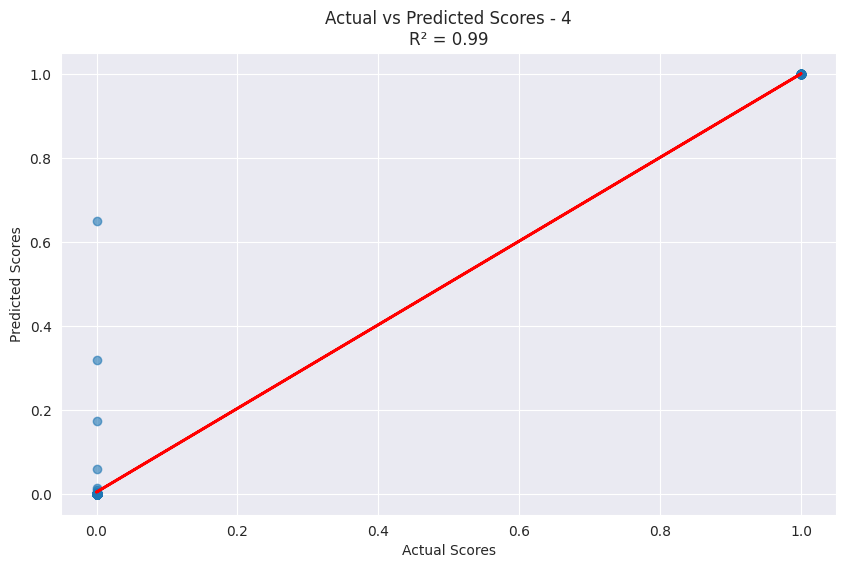

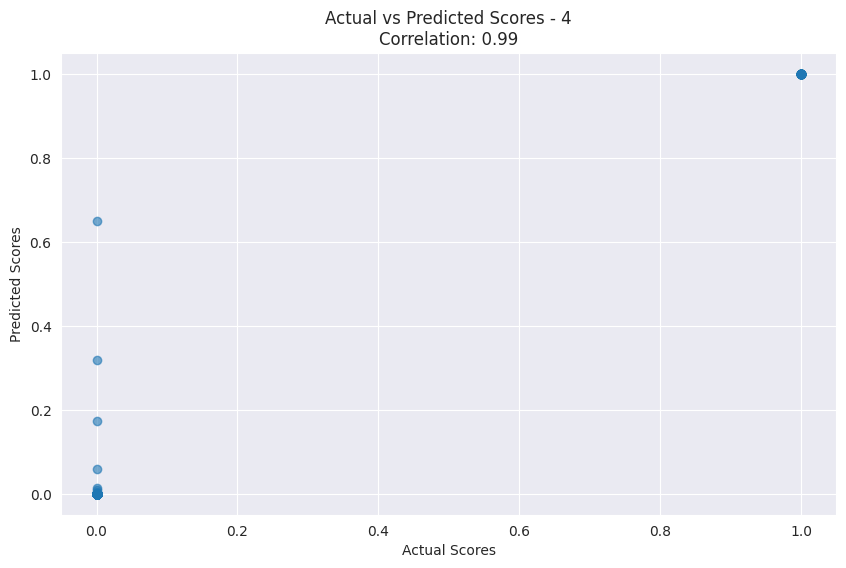

Heatmap for : 5
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 5
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 5
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 5 created
Len scores: 1437
Unique values in heatmap: [0 1]


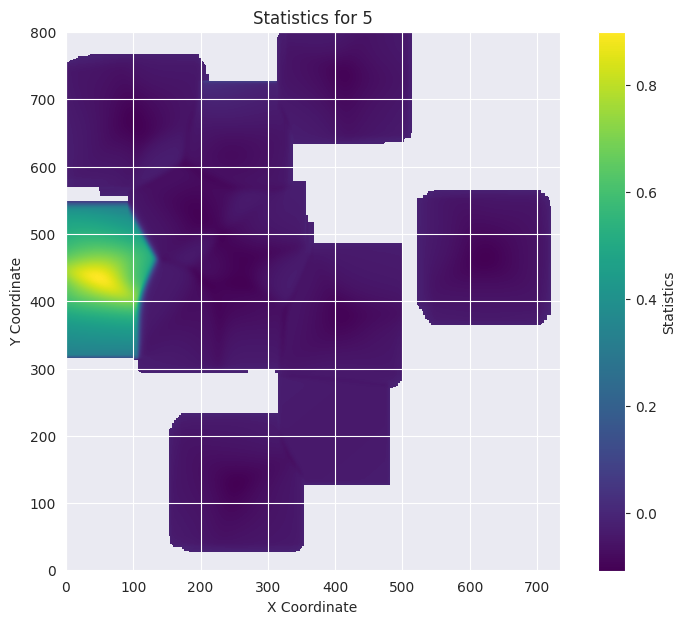

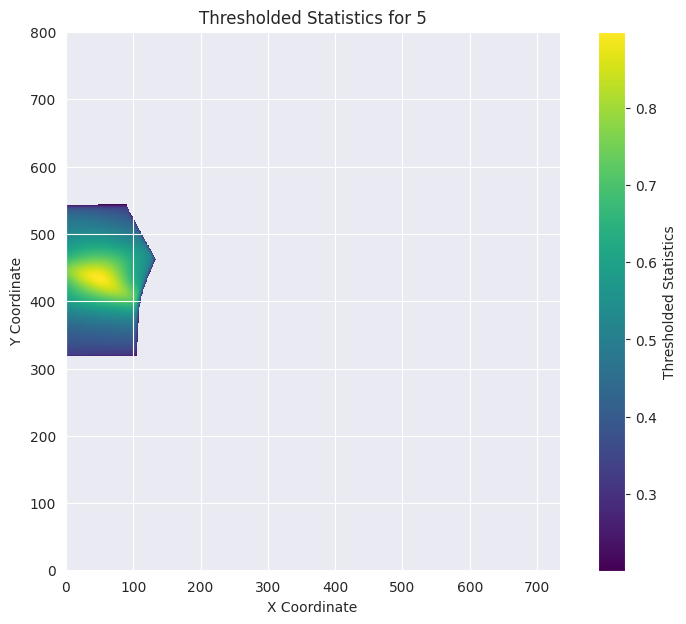

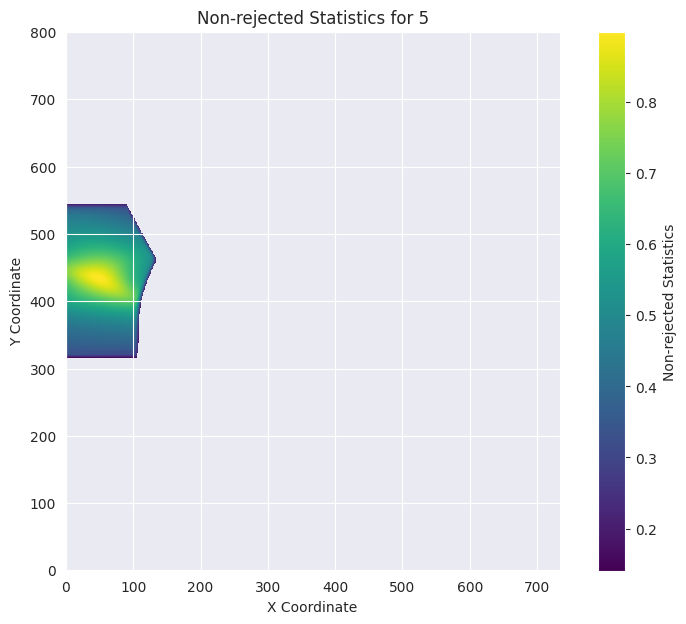

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 3318.48it/s]


Shape of the maps: (64,)
5 - Avg Training R^2: 0.994365271924018
5 - Avg Normalized Training MSE: 0.05%, Avg Normalized Training MAE: 0.17%, Avg MAE_max% Training: 0.17%
5 - Test R^2: 0.914275804500034
5 - Normalized Test MSE: 0.97%, Normalized Test MAE: 1.28%, Test MAE_max%: 1.28%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_5/5_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_5/5_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_5/5_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_5/5_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_5/5_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


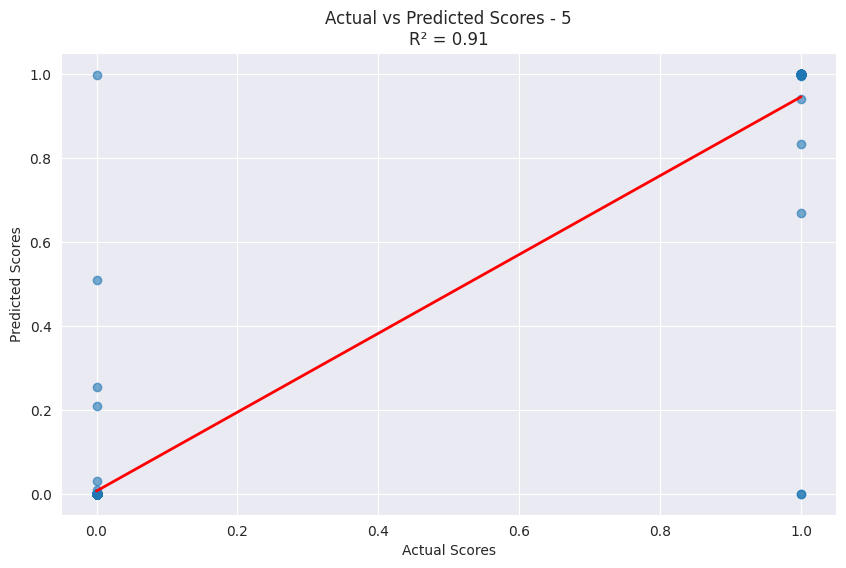

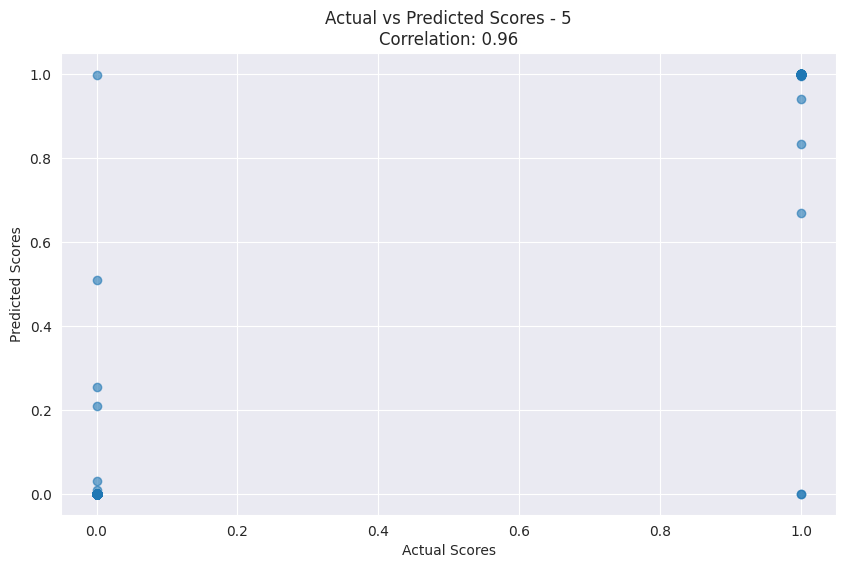

Heatmap for : 6
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 6
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 6
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 6 created
Len scores: 1437
Unique values in heatmap: [0 1]


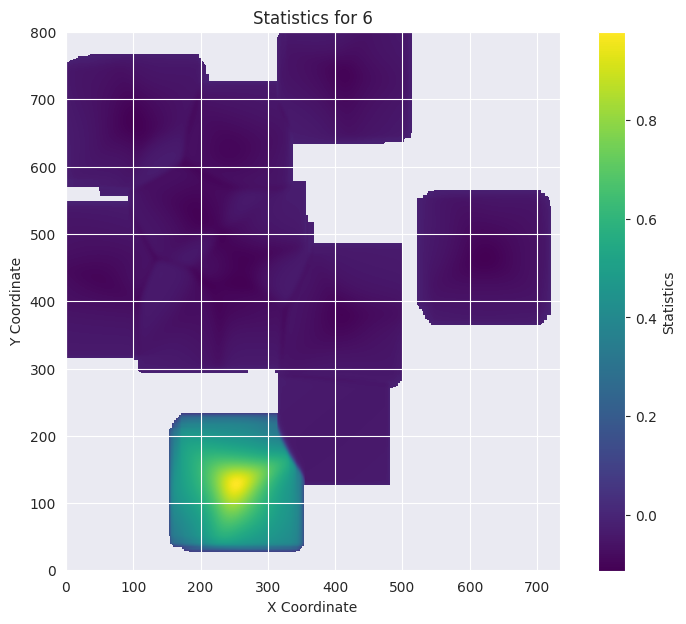

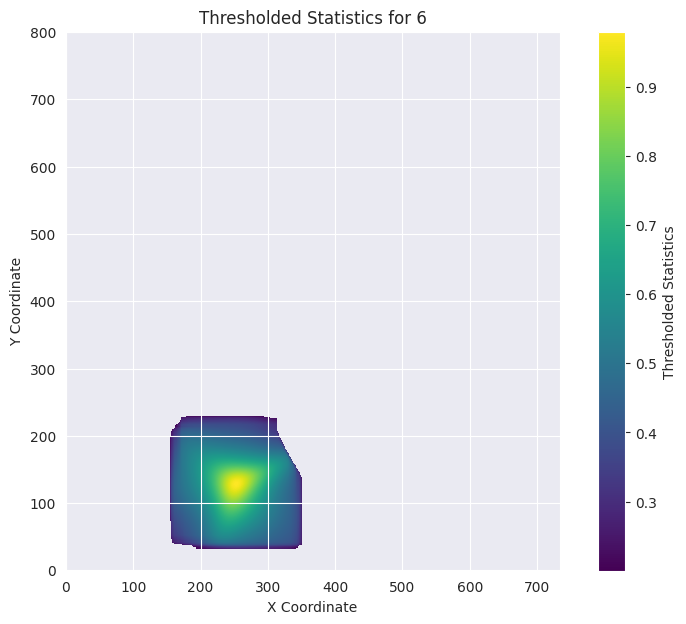

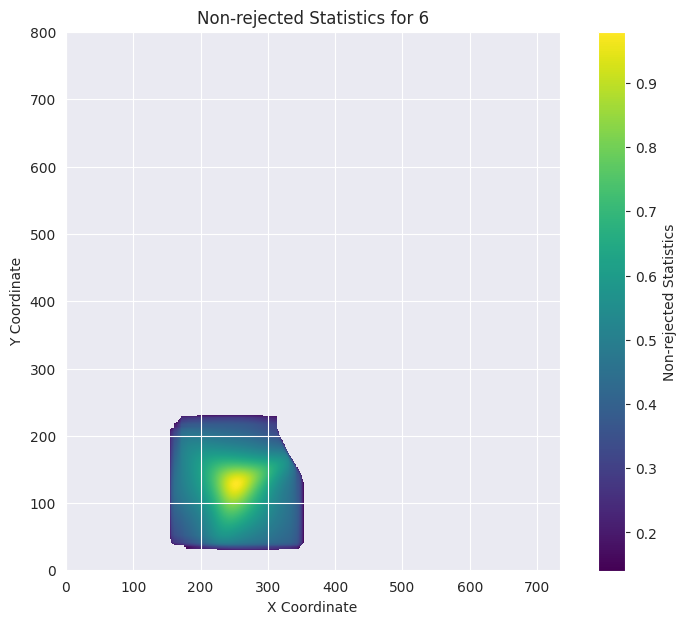

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 3220.12it/s]


Shape of the maps: (64,)
6 - Avg Training R^2: 1.0
6 - Avg Normalized Training MSE: 0.00%, Avg Normalized Training MAE: 0.00%, Avg MAE_max% Training: 0.00%
6 - Test R^2: 0.9683516483516483
6 - Normalized Test MSE: 0.28%, Normalized Test MAE: 0.28%, Test MAE_max%: 0.28%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_6/6_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_6/6_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_6/6_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_6/6_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_6/6_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


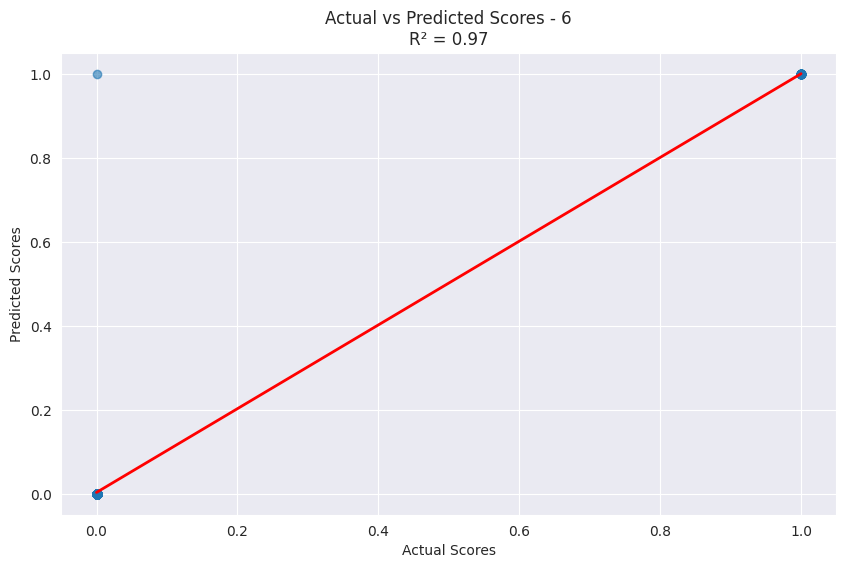

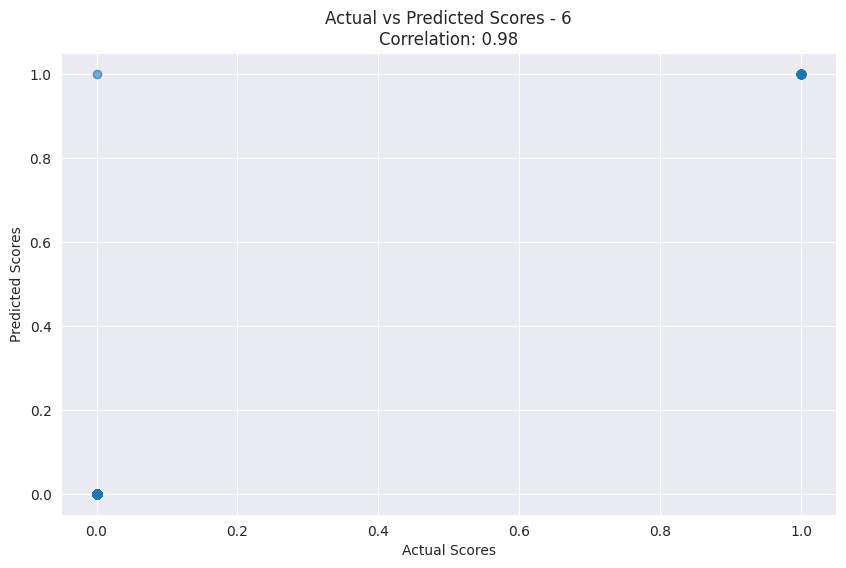

Heatmap for : 7
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 7
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 7
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 7 created
Len scores: 1437
Unique values in heatmap: [0 1]


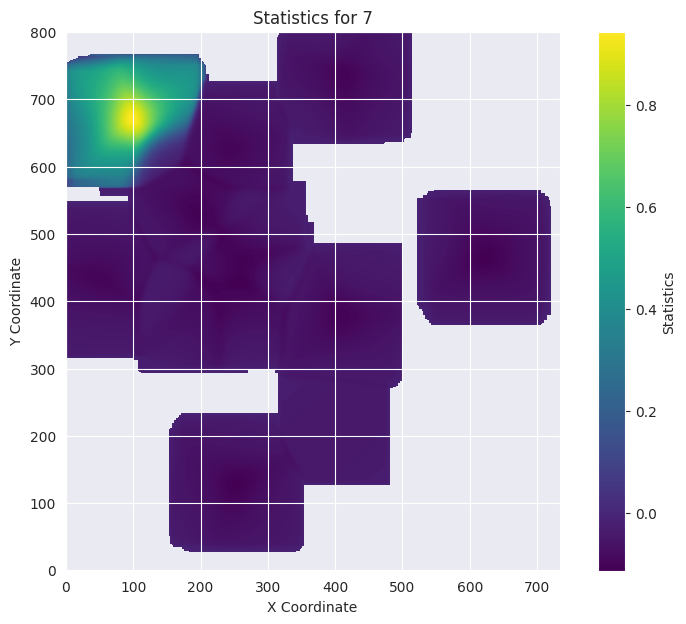

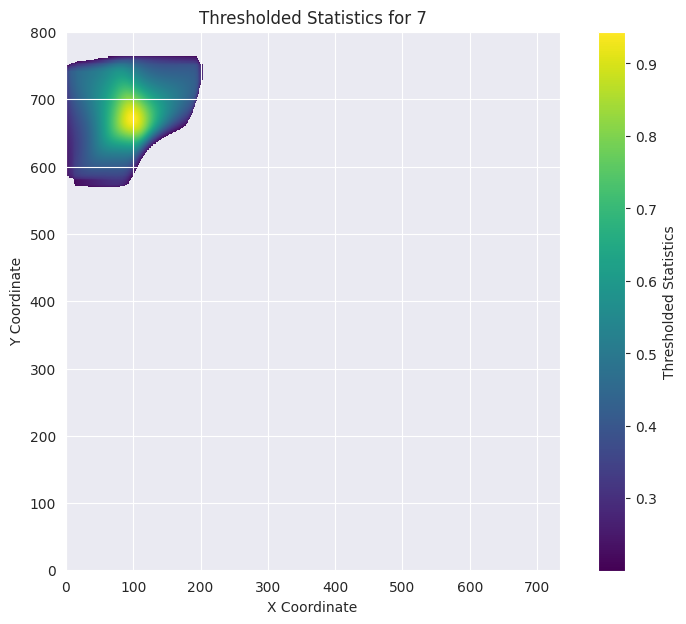

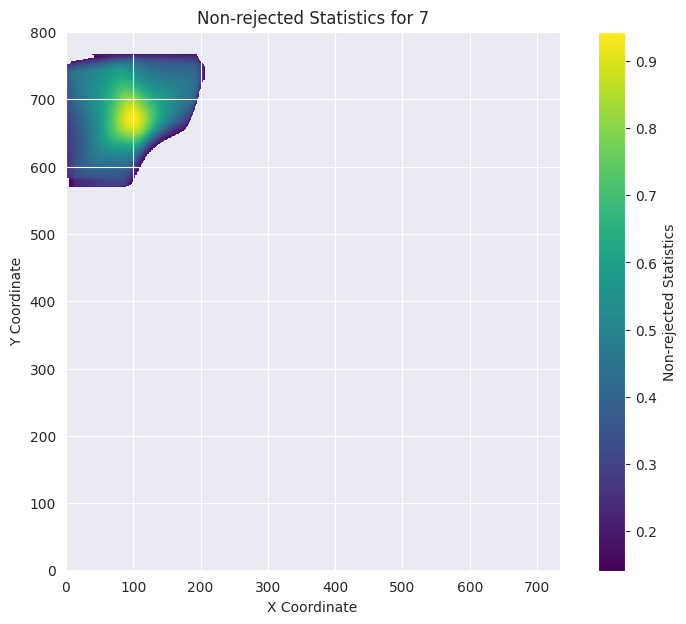

Found 1 clusters


100%|██████████| 64/64 [00:00<00:00, 3637.58it/s]


Shape of the maps: (64,)
7 - Avg Training R^2: 0.9954356239896743
7 - Avg Normalized Training MSE: 0.04%, Avg Normalized Training MAE: 0.19%, Avg MAE_max% Training: 0.19%
7 - Test R^2: 0.9714595741609527
7 - Normalized Test MSE: 0.24%, Normalized Test MAE: 0.64%, Test MAE_max%: 0.64%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_7/7_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_7/7_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_7/7_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_7/7_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_7/7_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


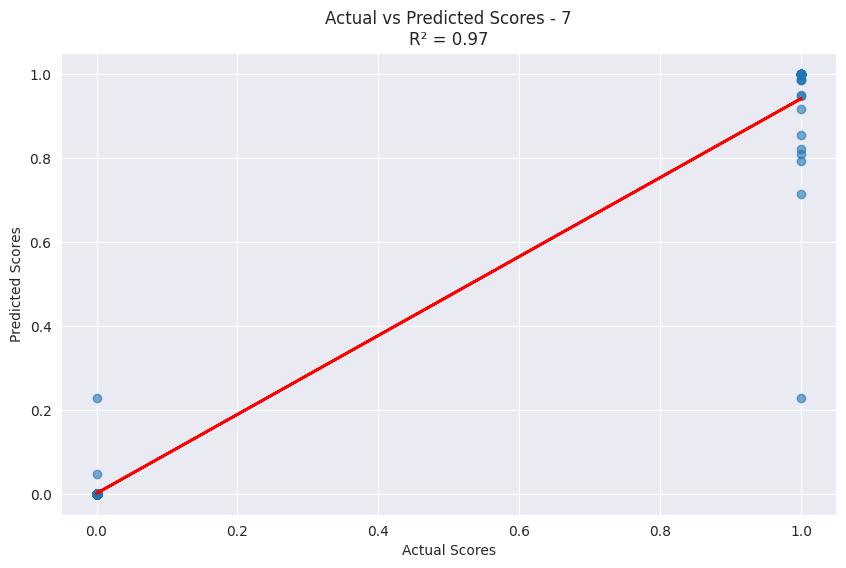

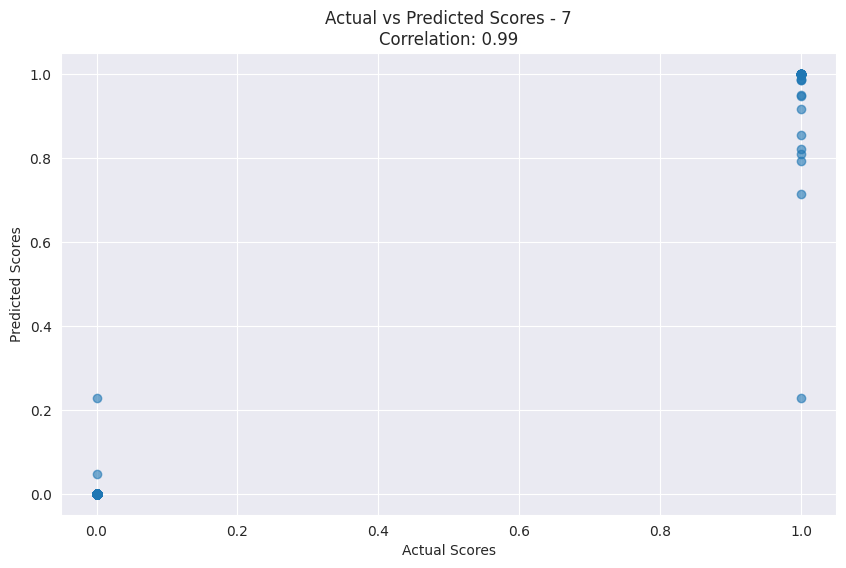

Heatmap for : 8
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 8
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 8
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 8 created
Len scores: 1437
Unique values in heatmap: [0 1]


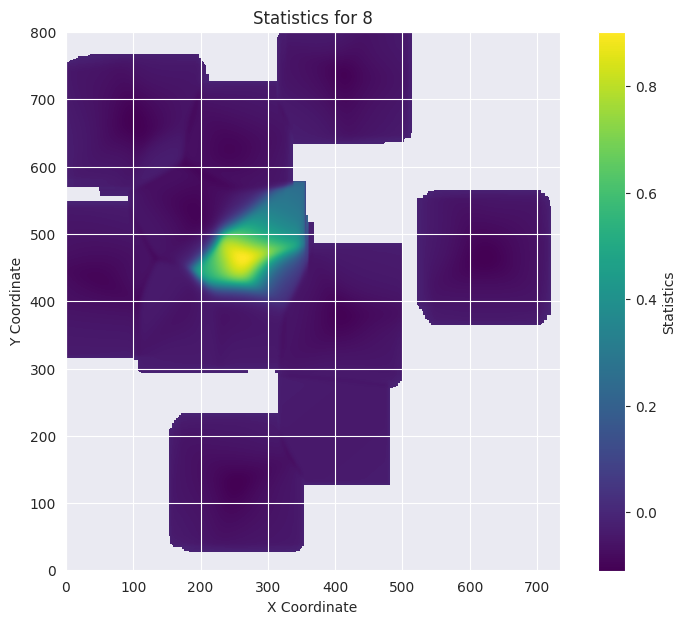

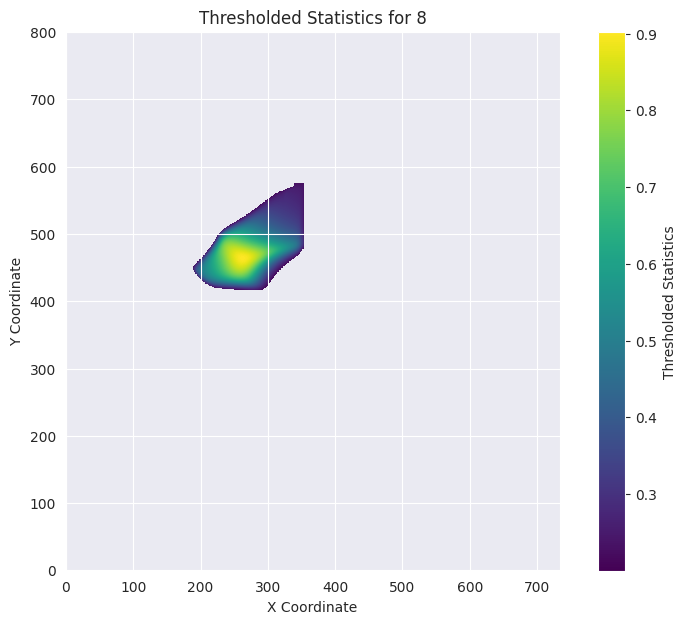

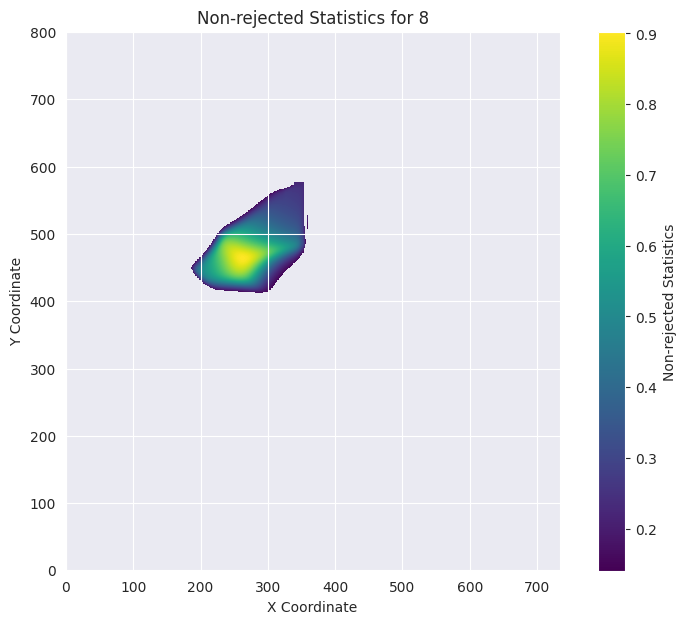

Found 2 clusters


100%|██████████| 64/64 [00:00<00:00, 2801.25it/s]


Shape of the maps: (64,)


100%|██████████| 64/64 [00:00<00:00, 6386.30it/s]


Shape of the maps: (64,)
8 - Avg Training R^2: 0.9884393190063712
8 - Avg Normalized Training MSE: 0.10%, Avg Normalized Training MAE: 0.46%, Avg MAE_max% Training: 0.46%
8 - Test R^2: 0.867214109090909
8 - Normalized Test MSE: 1.01%, Normalized Test MAE: 1.66%, Test MAE_max%: 1.66%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


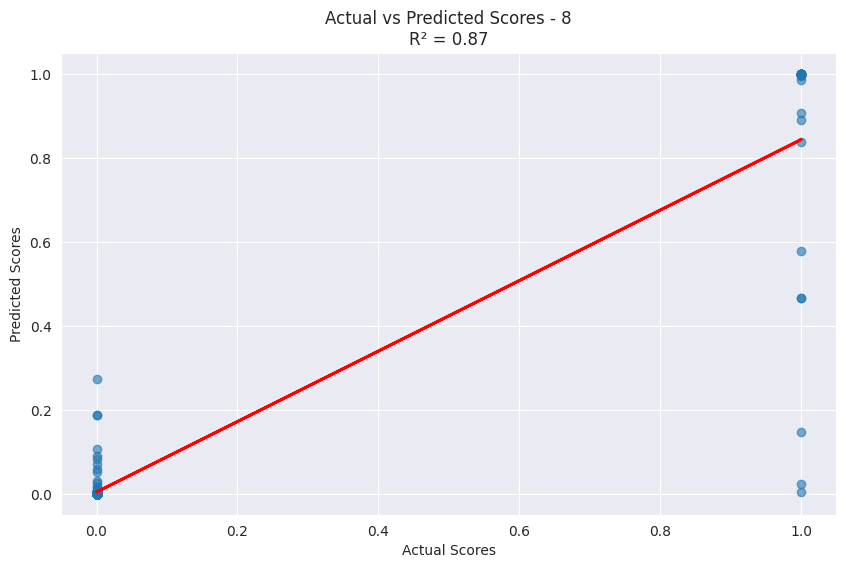

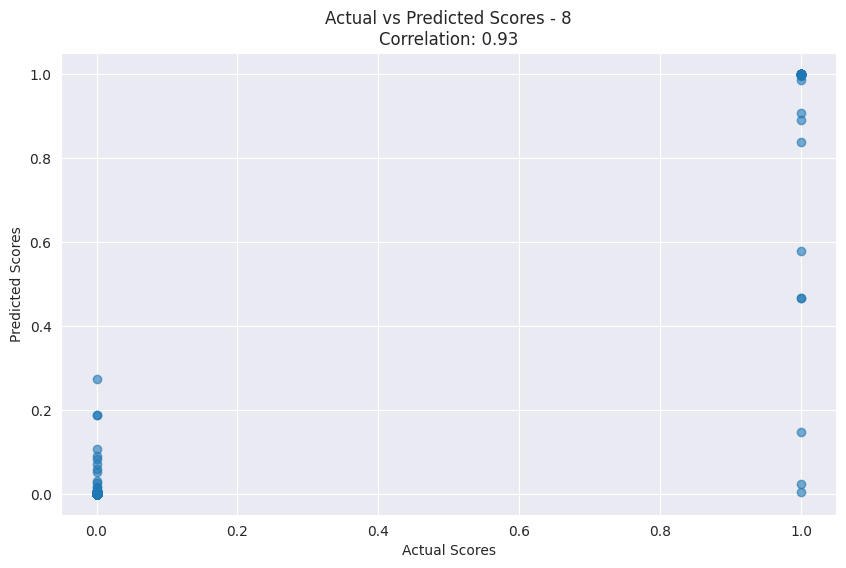

/tmp/ipykernel_199379/4004339262.py:9: RuntimeWarning: All-NaN slice encountered
  data = np.nan_to_num(data, nan=np.nanmin(data))
/tmp/ipykernel_199379/4004339262.py:12: RuntimeWarning: All-NaN slice encountered
  data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)
/tmp/ipykernel_199379/4004339262.py:12: RuntimeWarning: invalid value encountered in cast
  data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)


8 - Avg Training R^2: 0.9884393190063712
8 - Avg Normalized Training MSE: 0.10%, Avg Normalized Training MAE: 0.46%, Avg MAE_max% Training: 0.46%
8 - Test R^2: 0.867214109090909
8 - Normalized Test MSE: 1.01%, Normalized Test MAE: 1.66%, Test MAE_max%: 1.66%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_8/8_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


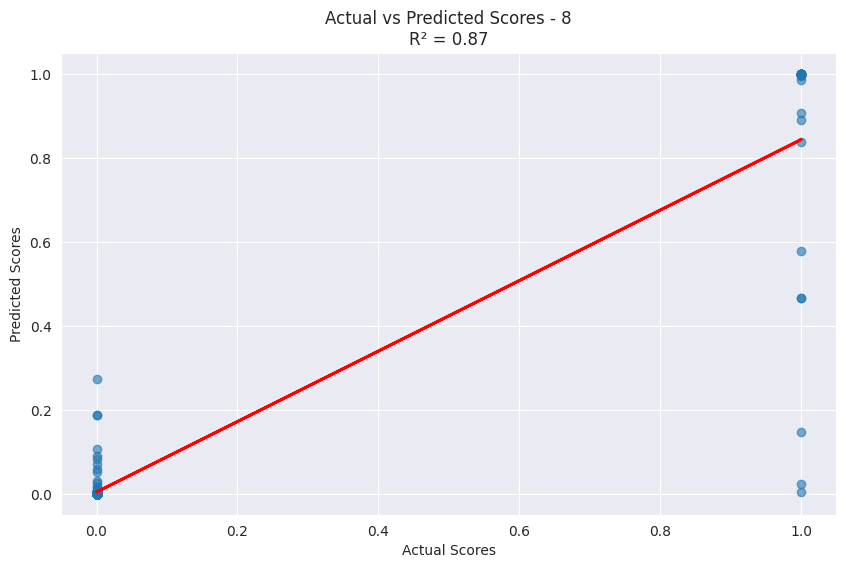

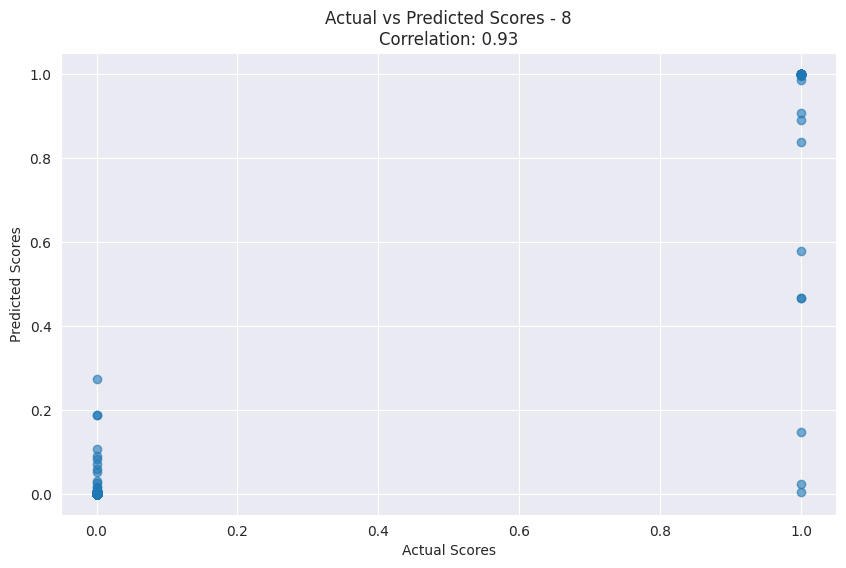

Heatmap for : 9
train_df['scores']: 1437
Shape of matched embeddings: (1437, 2)
Shape of matched embeddings after removing NaNs and Infs: (1437, 2)
Setting discrete embedding with shape None
Created heatmap 9
Setting discrete embedding with shape (734, 801)
Created heatmap rescaled and discrete space 9
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (1437, 734, 801)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (1437, 734, 801)
Heatmap 9 created
Len scores: 1437
Unique values in heatmap: [0 1]


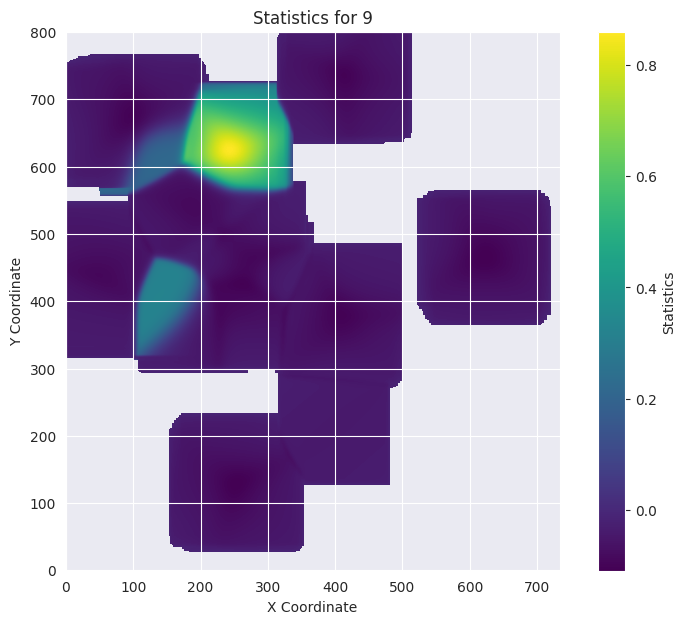

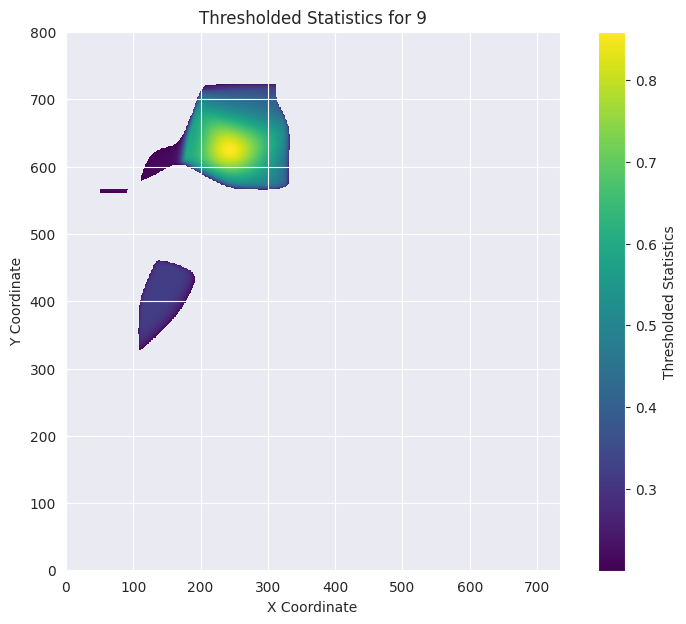

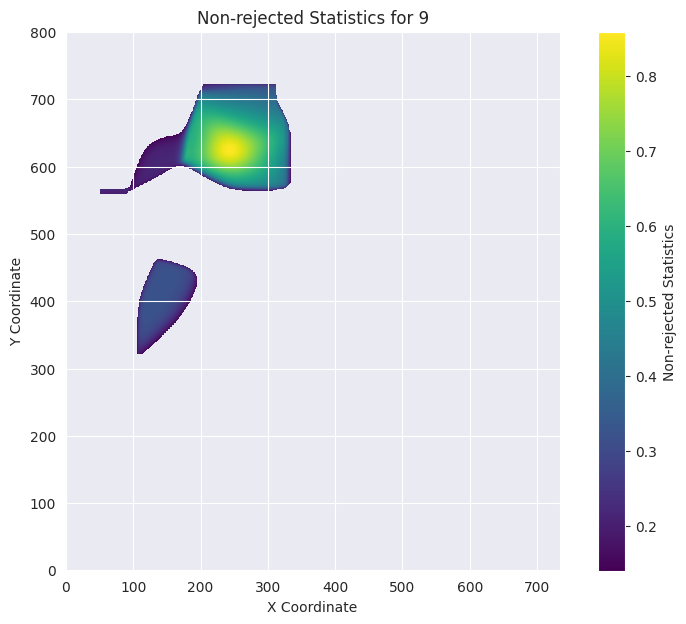

Found 3 clusters


100%|██████████| 64/64 [00:00<00:00, 5436.01it/s]


Shape of the maps: (64,)


100%|██████████| 64/64 [00:00<00:00, 2964.11it/s]


Shape of the maps: (64,)


100%|██████████| 64/64 [00:00<00:00, 3047.32it/s]


Shape of the maps: (64,)


/tmp/ipykernel_199379/4004339262.py:9: RuntimeWarning: All-NaN slice encountered
  data = np.nan_to_num(data, nan=np.nanmin(data))
/tmp/ipykernel_199379/4004339262.py:12: RuntimeWarning: All-NaN slice encountered
  data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)
/tmp/ipykernel_199379/4004339262.py:12: RuntimeWarning: invalid value encountered in cast
  data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)


9 - Avg Training R^2: 0.9896030150318278
9 - Avg Normalized Training MSE: 0.09%, Avg Normalized Training MAE: 0.40%, Avg MAE_max% Training: 0.40%
9 - Test R^2: 0.8643757375000001
9 - Normalized Test MSE: 1.34%, Normalized Test MAE: 1.98%, Test MAE_max%: 1.98%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


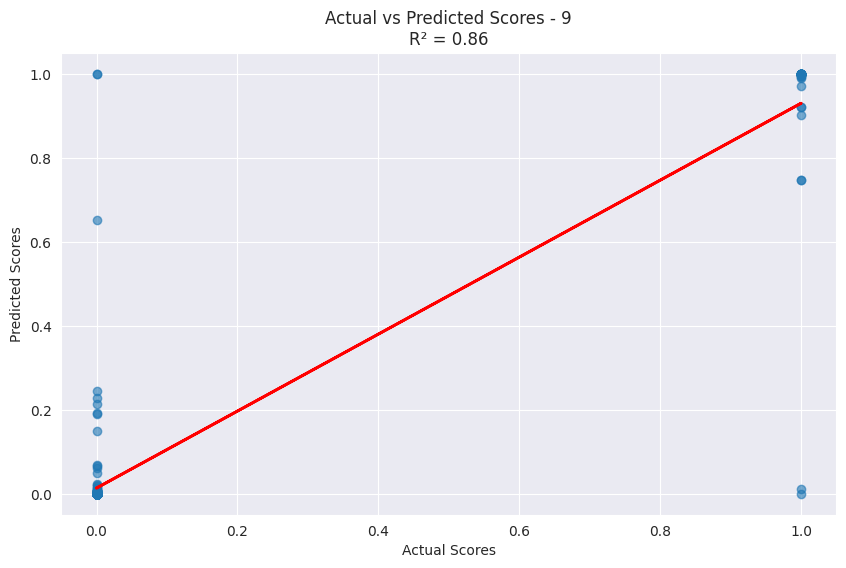

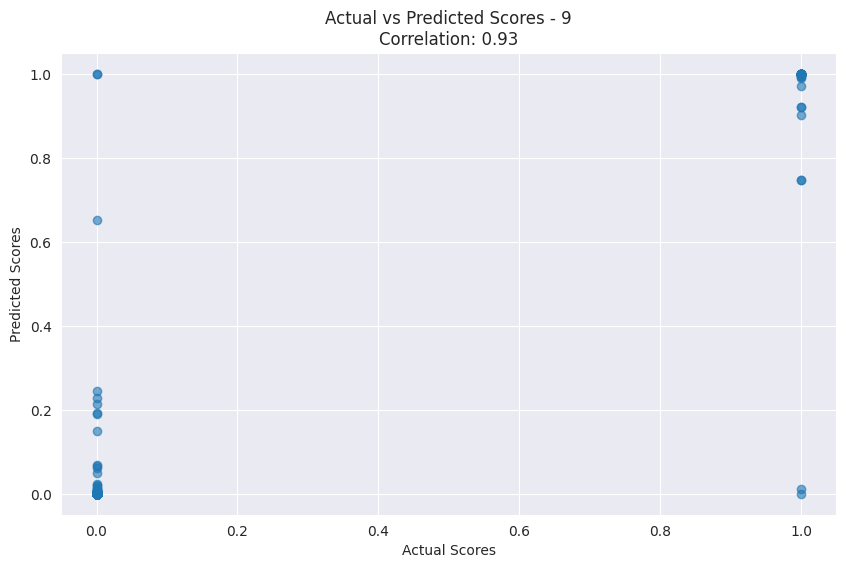

9 - Avg Training R^2: 0.9896030150318278
9 - Avg Normalized Training MSE: 0.09%, Avg Normalized Training MAE: 0.40%, Avg MAE_max% Training: 0.40%
9 - Test R^2: 0.8643757375000001
9 - Normalized Test MSE: 1.34%, Normalized Test MAE: 1.98%, Test MAE_max%: 1.98%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


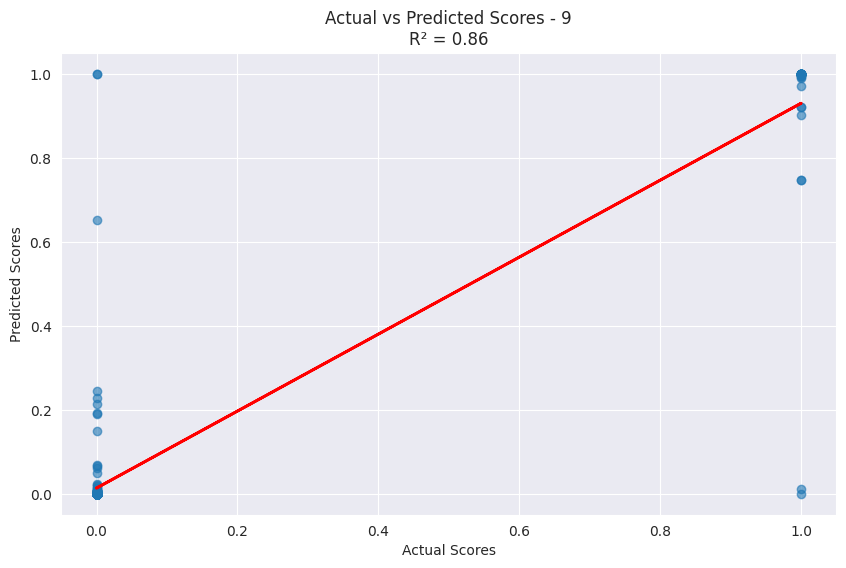

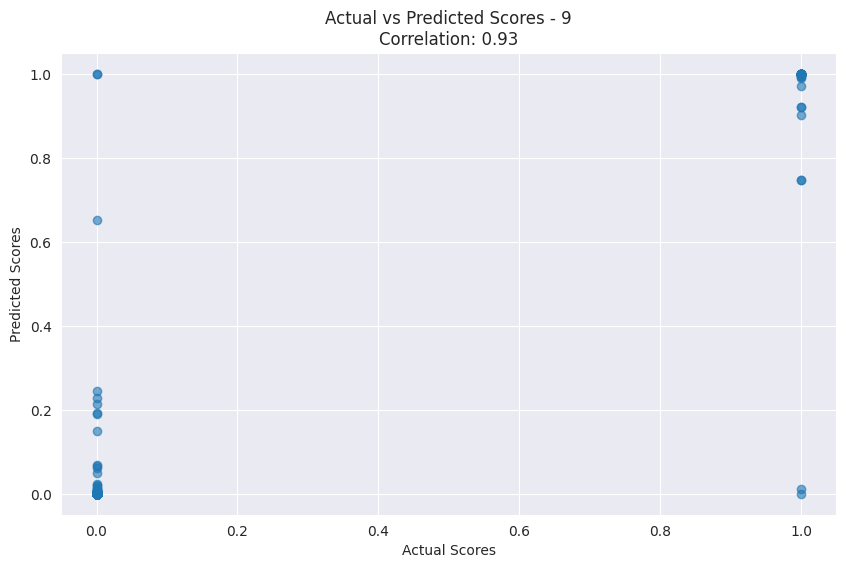

9 - Avg Training R^2: 0.9896030150318278
9 - Avg Normalized Training MSE: 0.09%, Avg Normalized Training MAE: 0.40%, Avg MAE_max% Training: 0.40%
9 - Test R^2: 0.8643757375000001
9 - Normalized Test MSE: 1.34%, Normalized Test MAE: 1.98%, Test MAE_max%: 1.98%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest_9/9_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


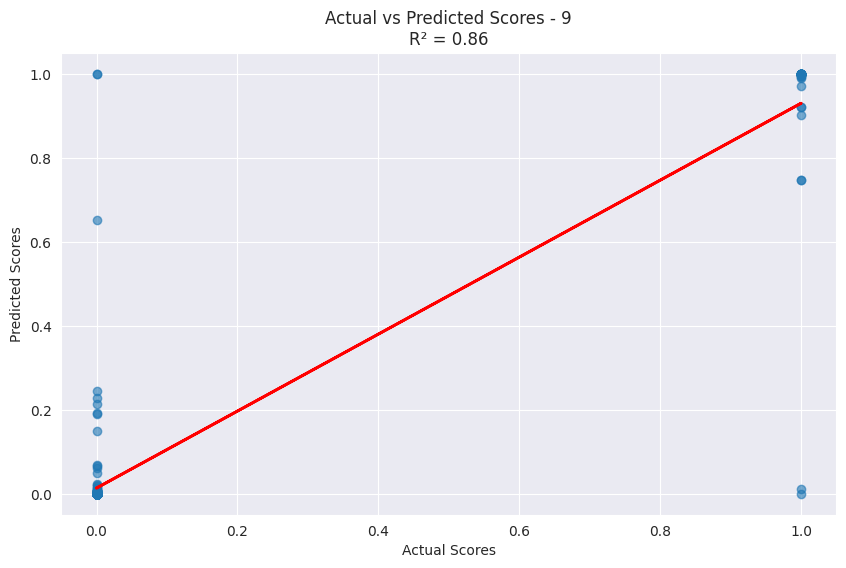

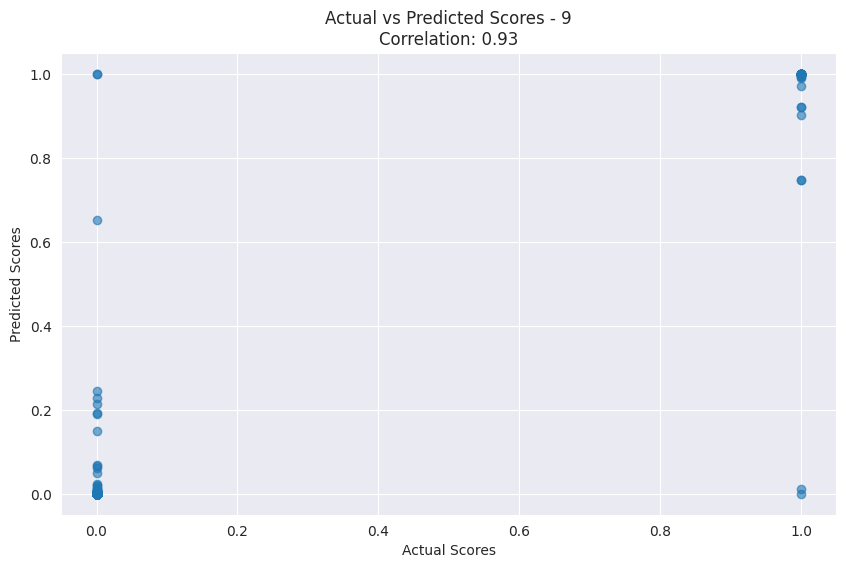

9 - Avg Training R^2: 0.9928313462357776
9 - Avg Normalized Training MSE: 0.07%, Avg Normalized Training MAE: 0.48%, Avg MAE_max% Training: 0.48%
9 - Test R^2: 0.9208792314938103
9 - Normalized Test MSE: 0.75%, Normalized Test MAE: 1.87%, Test MAE_max%: 1.87%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest/9_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest/9_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest/9_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest/9_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final/digit_labels/random_forest/9_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


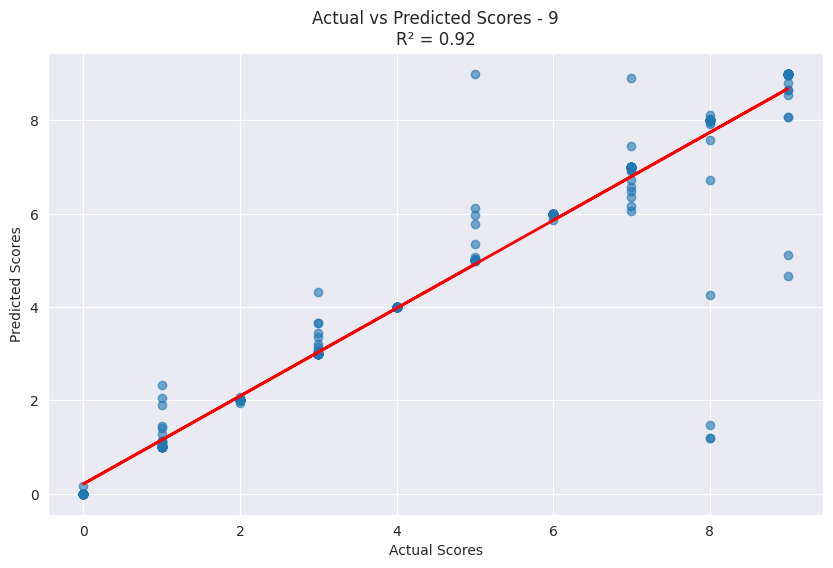

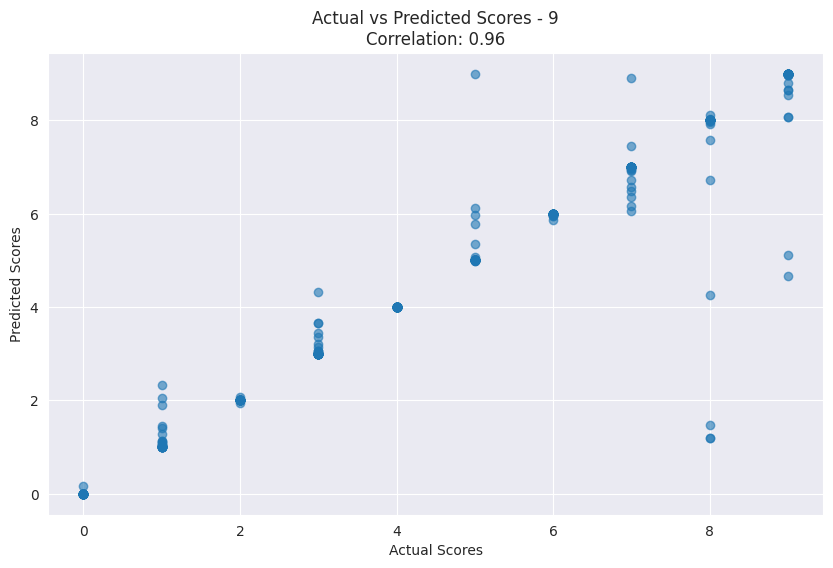

In [6]:
import numpy as np
import pandas as pd
from tools.stats_utils import create_cluster_representative_maps
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, \
    compute_categorical_stats_on_smoothed_nplusone_dim_discrete_space
from pathlib import Path


labels = np.unique(train_labels)
print(f'Length train labels: {len(train_labels)}')
labels = np.sort(labels)
print(labels)

save_score_vectors_list = []
save_stats_list = []
save_pvalues_list = []
save_corrected_pvalues_list = []
save_effect_size = []
save_mnist_digit_labels_3d_dls = []
labels = [9]
for score_tag in labels:
    mnist_dls = DiscreteLatentSpace.load(Path(mnist_output_folder, 'mnist_dls.dls'))
    print(f'Heatmap for : {score_tag}')
    train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
    train_labels_bin = np.where(train_labels == score_tag, 1, 0)
    train_df['scores'] = train_labels_bin
    print(f"train_df['scores']: {len(train_df['scores'])}")
    # Create heatmap for the combined dataset
    # if score_tag in mnist_dls.heatmaps:
    #     mnist_dls.delete_heatmap(score_tag)
    if score_tag not in mnist_dls.heatmaps:
        mnist_dls.create_heatmap_spaces(train_df, score_tag, smoothing_fwhm=None, smoothing_sigma=20)

    print(f'Heatmap {score_tag} created')
    print(f'Len scores: {len(mnist_dls.heatmaps[score_tag].scores)}')
    print(f'Unique values in heatmap: {np.unique(mnist_dls.heatmaps[score_tag].scores)}')

    mnist_digit_labels_3d_dls = mnist_dls.heatmaps[score_tag].smoothed_nplusone_dim_discrete_space
    save_mnist_digit_labels_3d_dls.append(mnist_digit_labels_3d_dls)
    save_score_vectors_list.append(mnist_dls.heatmaps[score_tag].scores)
    # mnist_dls.plot_heatmap(score_tag, output_folder=score_output_folder)
    # statistics_val, pvalues, corrected_pvalues, reject, effect_sizes = compute_categorical_stats_on_smoothed_nplusone_dim_discrete_space(
    # mnist_dls.heatmaps[score_tag], mnist_dls.heatmaps[score_tag].scores, test_name='mann-whitney', correction_method='holm')
    # print(f'Processing score tag: {score_tag}')
    # save_stats_list.append(statistics_val)
    # save_pvalues_list.append(pvalues)
    # save_corrected_pvalues_list.append(corrected_pvalues)
    # save_effect_size.append(effect_sizes)

    # statistics = effect_sizes_maps[score_tag]
    # corrected_pvalues = corrected_pvalues_maps[score_tag]
    # statistics = effect_sizes
    statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(
        mnist_dls.heatmaps[score_tag], mnist_dls.heatmaps[score_tag].scores, function='pointbiserialr', correction_method='holm')
    
    # Plot the statistics
    plt.figure(figsize=(10, 7))
    plt.imshow(statistics.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Statistics')
    plt.title(f'Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'raw_statistics_{score_tag}.png'))
    plt.show()

    # Threshold the |statistics| > 0.2 and show the space
    thresholded_statistics = np.where(np.abs(statistics) < 0.2, np.nan, statistics)
    plt.figure(figsize=(10, 7))
    plt.imshow(thresholded_statistics.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Thresholded Statistics')
    plt.title(f'Thresholded Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'thresholded_statistics_{score_tag}.png'))
    plt.show()

    # Create a mask for the rejected hypotheses
    reject_mask = np.where(corrected_pvalues > 0.05, np.nan, statistics)

    # Plot the statistics that are not rejected
    plt.figure(figsize=(10, 7))
    plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Non-rejected Statistics')
    plt.title(f'Non-rejected Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'non_rejected_statistics_{score_tag}.png'))
    plt.show()

    # Create cluster representative maps
    stat_maps, pval_maps, effect_size_maps, centroids = create_cluster_representative_maps(
        thresholded_statistics, mnist_dls.discrete_embeddings, mnist_input_matrix, (mnist_features_normalized.shape[1]), test_name='mann-whitney')

    for stat_map, pval_map, effect_size_map, centroid in zip(stat_maps, pval_maps, effect_size_maps, centroids):
        # for stat_map, pval_map, effect_size_map, centroid in zip(stat_maps, pval_maps, effect_size_maps, centroids):
        # Reshape each map to 8x8
        stat_map_reshaped = np.array(stat_map).reshape(8, 8)
        pval_map_reshaped = np.array(pval_map).reshape(8, 8)
        effect_size_map_reshaped = np.array(effect_size_map).reshape(8, 8)

        # Create the output folder if it doesn't exist
        Path(score_output_folder).mkdir(parents=True, exist_ok=True)

        # Save each map as a grayscale png
        save_grayscale_image(stat_map_reshaped, Path(score_output_folder, f'statistics_{score_tag}_{centroid[0]}_{centroid[1]}.png'))
        save_grayscale_image(pval_map_reshaped, Path(score_output_folder, f'p_values_{score_tag}_{centroid[0]}_{centroid[1]}.png'))
        save_grayscale_image(effect_size_map_reshaped, Path(score_output_folder, f'effect_size_{score_tag}_{centroid[0]}_{centroid[1]}.png'))

    rf_output_folder_score = Path(score_output_folder, f'random_forest_{score_tag}')
    rf_output_folder_score.mkdir(parents=True, exist_ok=True)

    model_train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
    model_train_df['scores'] = mnist_dls.heatmaps[score_tag].scores
    model_test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
    model_test_df['scores'] = np.where(test_labels == score_tag, 1, 0)
    train_model(model_train_df, model_test_df, score_tag, rf_output_folder_score)

    del mnist_dls

    # now each map contains an array with a value for each feature
    # So, for each map in stat_map, pval_map, effect_size_map, create a dataframe with the feature names as the index and the values as the columns and save it as a csv with the _x_y centroid coordinates in the name
    # for stat_map, pval_map, effect_size_map, centroid in zip(stat_maps, pval_maps, effect_size_maps, centroids):
    #     # create one dataframe with the three values as columns
    #     tests_df = pd.DataFrame(data={'Statistics': stat_map, 'P-Values': pval_map, 'Effect Size': effect_size_map})
    #     # save the dataframe as a csv
    #     tests_df.to_csv(Path(score_output_folder, f'tests_{score_tag}_{centroid[0]}_{centroid[1]}.csv'))

train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
train_df['scores'] = train_labels
# create an output folder for each prediction model (random forest, kriging, xgboost)
rf_output_folder = Path(score_output_folder, 'random_forest')
Path(rf_output_folder).mkdir(parents=True, exist_ok=True)
train_model(train_df, test_df, score_tag, rf_output_folder)
# krigin_output_folder = Path(score_output_folder, 'kriging')
# Path(krigin_output_folder).mkdir(parents=True, exist_ok=True)
# xgboost_output_folder = Path(score_output_folder, 'xgboost')
# Path(xgboost_output_folder).mkdir(parents=True, exist_ok=True)
# Now train and validate the predictive model
# train_model_kriging(train_df, test_df, score_tag, krigin_output_folder)
# train_model_xgboost_with_fold_grid_search(train_df, test_df, score_tag, xgboost_output_folder)


In [23]:
dls_3d_space = mnist_dls.heatmaps.keys()
print(list(mnist_dls.heatmaps.keys()))

[]


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:300: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Training R^2'] = avg_training_r2
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font fa

digit_labels - Avg Training R^2: 0.9928313462357776
digit_labels - Avg Normalized Training MSE: 0.07%, Avg Normalized Training MAE: 0.48%, Avg MAE_max% Training: 0.48%
digit_labels - Test R^2: 0.9208792314938103
digit_labels - Normalized Test MSE: 0.75%, Normalized Test MAE: 1.87%, Test MAE_max%: 1.87%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_matrix/random_forest/digit_labels_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_matrix/random_forest/digit_labels_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_matrix/random_forest/digit_labels_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_matrix/random_forest/digit_labels_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_ma

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

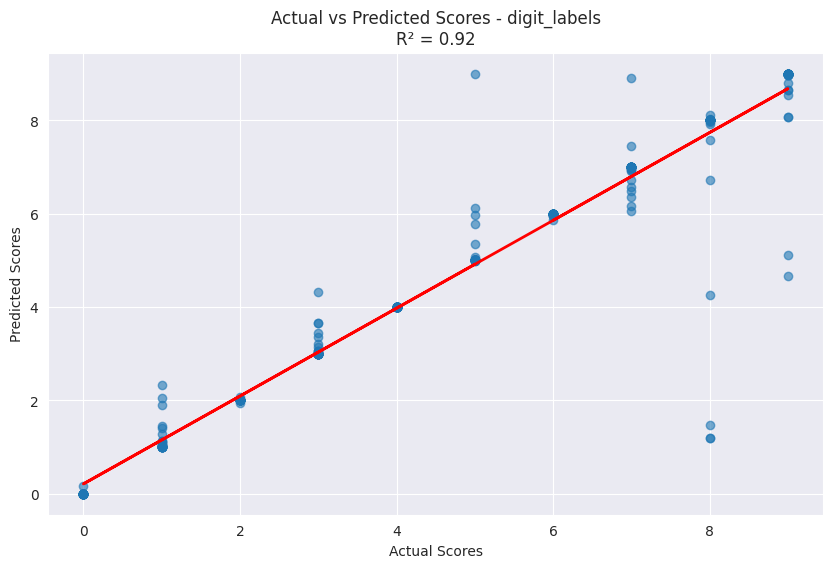

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

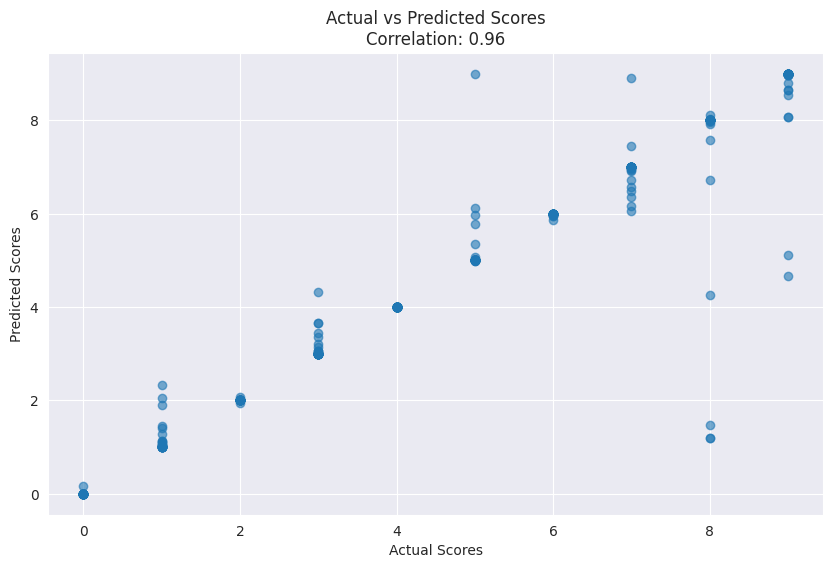

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

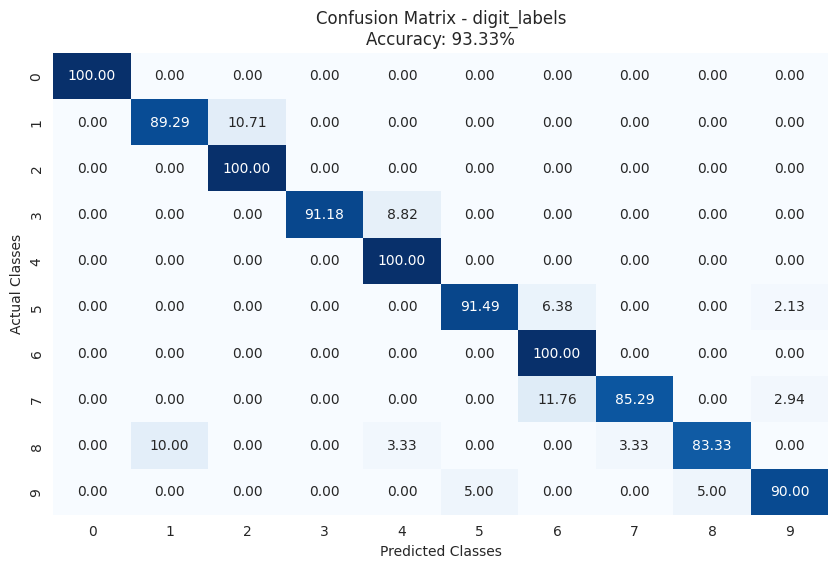

In [9]:
import pandas as pd
from pathlib import Path
from tools.stats_utils import train_model

output_model_folder = Path('/gamma/Dropbox (GIN)/EMUSE/mnist_numbers/random_forest_output_42_final_confusion_matrix')

train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
train_df['scores'] = train_labels
# create an output folder for each prediction model (random forest, kriging, xgboost)
rf_output_folder = Path(output_model_folder, 'random_forest')
Path(rf_output_folder).mkdir(parents=True, exist_ok=True)
train_model(train_df, test_df, score_tag, rf_output_folder, True)

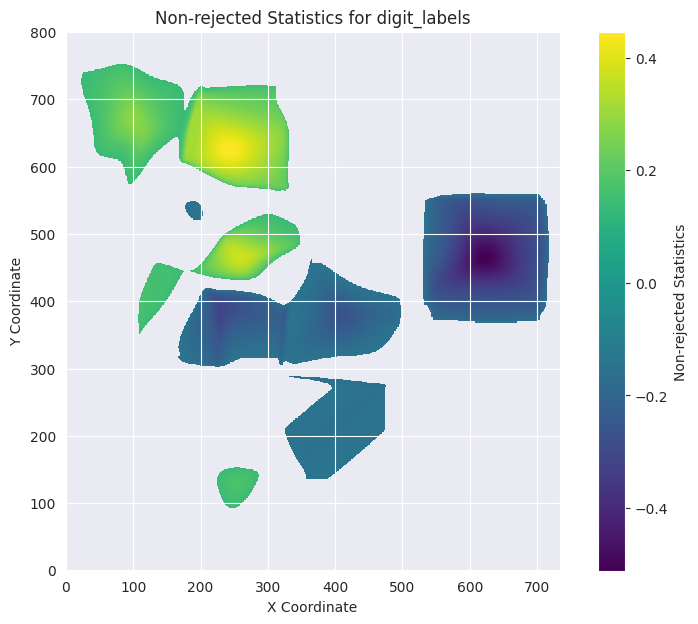

Found 8 clusters


100%|██████████| 64/64 [00:00<00:00, 3164.92it/s]

Shape of the maps: (64,)



100%|██████████| 64/64 [00:00<00:00, 3948.28it/s]

Shape of the maps: (64,)


...

Shape of the maps: (64,)



100%|██████████| 64/64 [00:00<00:00, 2679.10it/s]

Shape of the maps: (64,)



100%|██████████| 64/64 [00:00<00:00, 3055.26it/s]

Shape of the maps: (64,)


In [13]:
reject_mask = np.where(corrected_pvalues > 0.05, np.nan, statistics)

# plot reject_mask

plt.figure(figsize=(10, 7))
plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
plt.colorbar(label='Non-rejected Statistics')
plt.title(f'Non-rejected Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

corr_stat_maps, corr_pval_maps, corr_effect_size_maps, corr_centroids = create_cluster_representative_maps(
    reject_mask, mnist_dls.discrete_embeddings, mnist_input_matrix, (mnist_features_normalized.shape[1]), test_name='mann-whitney')

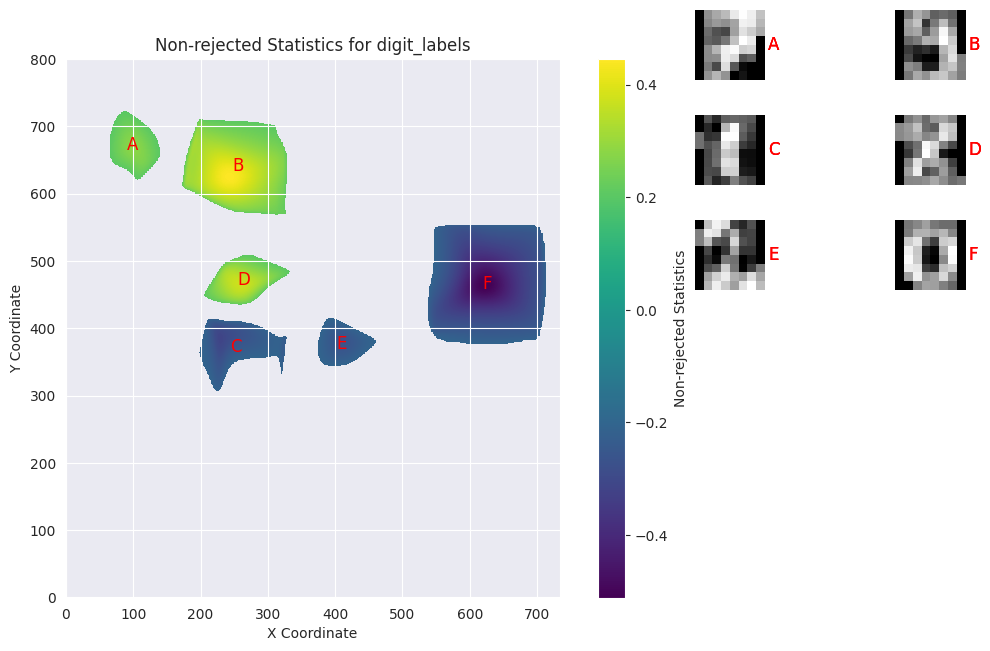

In [25]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import string

data_to_plot = thresholded_statistics
# data_to_plot = reject_mask

def save_grayscale_image(data, filename):
    """
    Save a 2D numpy array as a grayscale image using PIL.
    Return the Image object.
    """
    # Replace NaN values with the minimum value of the array
    data = np.nan_to_num(data, nan=np.nanmin(data))

    # Normalize the data to be between 0 and 255
    data_normalized = ((data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255).astype(np.uint8)

    # Create the image from the normalized data
    image = Image.fromarray(data_normalized, mode='L')

    # Save the image
    image.save(filename)

    return image

# Plot reject_mask
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(data_to_plot.T, cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax, label='Non-rejected Statistics')
plt.title(f'Non-rejected Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# Letters to label the images
letters = string.ascii_uppercase

# Save grayscale images and plot them around the main plot
for idx, (stat_map, pval_map, effect_size_map, centroid) in enumerate(zip(stat_maps, pval_maps, effect_size_maps, centroids)):
# for idx, (stat_map, pval_map, effect_size_map, centroid) in enumerate(zip(corr_stat_maps, corr_pval_maps, corr_effect_size_maps, corr_centroids)):
    # Reshape each map to 8x8
    stat_map_reshaped = np.array(stat_map).reshape(8, 8)
    pval_map_reshaped = np.array(pval_map).reshape(8, 8)

    # threshold the effect size map at 0.2
    # effect_size_map_reshaped = np.where(np.abs(np.array(effect_size_map)) < 0.0, np.nan, effect_size_map).reshape(8, 8)
    effect_size_map_reshaped = np.array(effect_size_map).reshape(8, 8)

    # Create the output folder if it doesn't exist
    Path(score_output_folder).mkdir(parents=True, exist_ok=True)

    # Save each map as a grayscale png and get the Image object
    stat_img = save_grayscale_image(stat_map_reshaped, Path(score_output_folder, f'statistics_{score_tag}_{centroid[0]}_{centroid[1]}.png'))
    pval_img = save_grayscale_image(pval_map_reshaped, Path(score_output_folder, f'p_values_{score_tag}_{centroid[0]}_{centroid[1]}.png'))
    effect_size_img = save_grayscale_image(effect_size_map_reshaped, Path(score_output_folder, f'effect_size_{score_tag}_{centroid[0]}_{centroid[1]}.png'))

    # Select an appropriate position for each image around the main plot
    if idx % 2 == 0:
        img_x, img_y = 0.85, 0.85 - 0.15 * (idx // 2)
    else:
        img_x, img_y = 1.05, 0.85 - 0.15 * (idx // 2)

    # Display the images in the chosen positions and label them
    letter = letters[idx % len(letters)]
    for img in [stat_img, pval_img, effect_size_img]:
        img_array = np.array(img)

        # Add the image to the plot
        newax = fig.add_axes([img_x, img_y, 0.1, 0.1], anchor='NE', zorder=1)
        newax.imshow(img_array, cmap='gray')
        newax.axis('off')

        # Add the letter label next to the image
        newax.text(1.05, 0.5, letter, transform=newax.transAxes, fontsize=12, color='red', va='center', ha='left')

    # Add the letter to the centroid in the main plot
    ax.text(centroid[0], centroid[1], letter, fontsize=12, color='red', ha='center', va='center')

plt.show()


In [11]:
import nibabel as nib
import numpy as np
from scipy.spatial import KDTree

img = nib.load('/home/chrisfoulon/neuro_data/tests_bcblib/mask.nii.gz')

data = img.get_fdata()
print(data.shape)
print(f'Number of voxels in the mask: {np.sum(data)}')

tree = KDTree(np.asarray(np.where(img.get_fdata())).T)

# check the size of the tree
print(tree.data.shape)

(91, 109, 91)
Number of voxels in the mask: 258370.0
(258370, 3)
